# PRISM Drug Repurposing Screen Analysis

This notebook analyzes raw plate-level PRISM Repurposing screen data from Corsello et al. 2020.

The goal is to start from raw per-well MFI measurements and build a reproducible analysis workflow for:

1. primary screen quality control,
2. primary screen normalization and hit calling,
3. hit triage for dose-response follow-up,
4. secondary screen quality control and normalization,
5. dose-response curve fitting,
6. selective killing analysis,
7. biomarker association and prediction,
8. mechanism exploration,
9. repurposing candidate prioritization.

This notebook preserves raw data unchanged. All processed outputs will be written to separate folders.

In [61]:
import sys

print(sys.executable)

c:\Users\shash\Desktop\Code for assignment\.venv\Scripts\python.exe


In [62]:
import sys

print(sys.executable)

c:\Users\shash\Desktop\Code for assignment\.venv\Scripts\python.exe


In [63]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl


'c:\Users\shash\Desktop\Code' is not recognized as an internal or external command,
operable program or batch file.


In [64]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl

'c:\Users\shash\Desktop\Code' is not recognized as an internal or external command,
operable program or batch file.


In [65]:
import sys

python_path = f'"{sys.executable}"'
print(python_path)

"c:\Users\shash\Desktop\Code for assignment\.venv\Scripts\python.exe"


In [66]:
import sys

!"{sys.executable}" -m pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pyarrow openpyxl

In [67]:
from pathlib import Path
import os
import textwrap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Project root folder
PROJECT_DIR = Path(r"C:\Users\shash\Desktop\Code for assignment")

# Main folders
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

REPORTS_DIR = PROJECT_DIR / "reports"

# Create folders if they do not already exist
for folder in [
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)

Project directory: C:\Users\shash\Desktop\Code for assignment
Raw data directory: C:\Users\shash\Desktop\Code for assignment\data\raw


In [69]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)

sns.set_context("notebook")

print("Display settings loaded.")

Display settings loaded.


In [70]:
def inventory_files(folder):
    """
    Return a table of files in a folder without reading full file contents.
    """
    folder = Path(folder)

    rows = []
    for path in sorted(folder.rglob("*")):
        if path.is_file():
            rows.append({
                "relative_path": path.relative_to(folder),
                "file_name": path.name,
                "suffix": path.suffix.lower(),
                "size_mb": path.stat().st_size / (1024 ** 2),
            })

    return pd.DataFrame(rows)


raw_inventory = inventory_files(RAW_DIR)

print(f"Found {len(raw_inventory)} files in raw data folder.")
raw_inventory

Found 23 files in raw data folder.


,relative_path,file_name,suffix,size_mb
0,CCLE_expression.csv,CCLE_expression.csv,.csv,286.563055
1,CCLE_gene_cn.csv,CCLE_gene_cn.csv,.csv,637.766252
2,CCLE_mutations.csv,CCLE_mutations.csv,.csv,276.733011
3,features\Confounders.csv,Confounders.csv,.csv,0.060482
4,features\Copy Number Alterations.csv,Copy Number Alterations.csv,.csv,165.357536
5,features\CRISPR.csv,CRISPR.csv,.csv,117.430954
6,features\D2.csv,D2.csv,.csv,152.287231
7,features\Hotspot Mutations.csv,Hotspot Mutations.csv,.csv,118.464334
8,features\Metabolomics.csv,Metabolomics.csv,.csv,3.036568
9,features\Methylation.csv,Methylation.csv,.csv,246.978885


In [71]:
def preview_csv(path, nrows=5):
    """
    Safely preview a CSV file without loading the full dataset.
    Useful for checking column names and structure before analysis.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    preview = pd.read_csv(path, nrows=nrows)

    print(f"File: {path.name}")
    print(f"Preview rows: {preview.shape[0]}")
    print(f"Preview columns: {preview.shape[1]}")
    print("\nColumn names:")
    for col in preview.columns[:30]:
        print(f"  - {col}")

    if preview.shape[1] > 30:
        print(f"  ... {preview.shape[1] - 30} more columns")

    return preview


In [72]:
def preview_text_file(path, max_lines=40):
    """
    Preview the beginning of a text or README file.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with open(path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    print(f"File: {path.name}")
    print(f"Total lines shown: {min(len(lines), max_lines)}")
    print("-" * 80)

    for line in lines[:max_lines]:
        print(line.rstrip())

In [73]:
raw_inventory

,relative_path,file_name,suffix,size_mb
0,CCLE_expression.csv,CCLE_expression.csv,.csv,286.563055
1,CCLE_gene_cn.csv,CCLE_gene_cn.csv,.csv,637.766252
2,CCLE_mutations.csv,CCLE_mutations.csv,.csv,276.733011
3,features\Confounders.csv,Confounders.csv,.csv,0.060482
4,features\Copy Number Alterations.csv,Copy Number Alterations.csv,.csv,165.357536
5,features\CRISPR.csv,CRISPR.csv,.csv,117.430954
6,features\D2.csv,D2.csv,.csv,152.287231
7,features\Hotspot Mutations.csv,Hotspot Mutations.csv,.csv,118.464334
8,features\Metabolomics.csv,Metabolomics.csv,.csv,3.036568
9,features\Methylation.csv,Methylation.csv,.csv,246.978885


## 0.1 Inspect README and File Schemas

Before loading the large raw MFI matrices, we first inspect the README and small metadata files. This prevents us from guessing column names or making assumptions about how wells, compounds, doses, plates, pools, and cell lines are encoded.

In [74]:
preview_text_file(RAW_DIR / "README.md", max_lines=80)

File: README.md
Total lines shown: 80
--------------------------------------------------------------------------------
# PRISM Repurposing Screen Data Bundle

## Provenance

Raw screening data from Corsello et al. 2020 (Nature Cancer):
"Discovering the anti-cancer potential of non-oncology drugs by systematic
viability profiling"

DOI: 10.1038/s43018-019-0018-6
Data source: https://depmap.org/repurposing

## Assay

PRISM (Profiling Relative Inhibition Simultaneously in Mixtures) is a
multiplexed cell viability assay. Cancer cell lines are labeled with unique
DNA barcodes, pooled in groups of ~25 (matched by doubling time), and treated
with compounds. After 5 days of incubation, cells are lysed and barcode
abundance is measured via Luminex bead-based detection. The median
fluorescence intensity (MFI) of each barcode serves as a surrogate for the
relative viability of that cell line.

## Screens

**Primary screen:** 4,518 compounds tested at a single dose (2.5 uM) across
578 cell lines i

In [75]:
primary_treatment_preview = preview_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv",
    nrows=5
)

primary_cell_line_preview = preview_csv(
    RAW_DIR / "primary-screen-cell-line-info.csv",
    nrows=5
)

primary_pooling_preview = preview_csv(
    RAW_DIR / "primary-screen-pooling-info.csv",
    nrows=5
)

File: primary-screen-replicate-treatment-info.csv
Preview rows: 5
Preview columns: 18

Column names:
  - column_name
  - broad_id
  - name
  - dose
  - perturbation_type
  - screen_id
  - detection_plate
  - compound_plate
  - well
  - detection_plate_scan_time
  - vendor_id
  - purity
  - moa
  - target
  - disease.area
  - indication
  - smiles
  - phase
File: primary-screen-cell-line-info.csv
Preview rows: 5
Preview columns: 10

Column names:
  - row_name
  - depmap_id
  - ccle_name
  - primary_tissue
  - secondary_tissue
  - tertiary_tissue
  - passed_str_profiling
  - str_profiling_notes
  - originally_assigned_depmap_id
  - originally_assigned_ccle_name
File: primary-screen-pooling-info.csv
Preview rows: 5
Preview columns: 7

Column names:
  - row_name
  - screen_id
  - analyte_id
  - detection_pool
  - minipool_id
  - pool_id
  - passed_str_profiling


In [76]:
secondary_treatment_preview = preview_csv(
    RAW_DIR / "secondary-screen-replicate-treatment-info.csv",
    nrows=5
)

secondary_cell_line_preview = preview_csv(
    RAW_DIR / "secondary-screen-cell-line-info.csv",
    nrows=5
)

secondary_pooling_preview = preview_csv(
    RAW_DIR / "secondary-screen-pooling-info.csv",
    nrows=5
)

File: secondary-screen-replicate-treatment-info.csv
Preview rows: 5
Preview columns: 12

Column names:
  - column_name
  - broad_id
  - dose
  - screen_id
  - compound_plate
  - name
  - moa
  - target
  - disease.area
  - indication
  - smiles
  - phase
File: secondary-screen-cell-line-info.csv
Preview rows: 5
Preview columns: 7

Column names:
  - row_name
  - depmap_id
  - ccle_name
  - primary_tissue
  - secondary_tissue
  - tertiary_tissue
  - passed_str_profiling
File: secondary-screen-pooling-info.csv
Preview rows: 5
Preview columns: 9

Column names:
  - row_name
  - depmap_id
  - passed_str_profiling
  - ccle_name
  - screen_id
  - analyte_id
  - detection_pool
  - minipool_id
  - pool_id


In [77]:
primary_mfi_preview = preview_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=5
)

secondary_mfi_preview = preview_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=5
)

File: primary-screen-primary-mfi.csv
Preview rows: 5
Preview columns: 17059

Column names:
  - Unnamed: 0
  - PREP001_X1:A01::HTS
  - PREP001_X1:A02::HTS
  - PREP001_X1:A03::HTS
  - PREP001_X1:A04::HTS
  - PREP001_X1:A05::HTS
  - PREP001_X1:A06::HTS
  - PREP001_X1:A07::HTS
  - PREP001_X1:A08::HTS
  - PREP001_X1:A09::HTS
  - PREP001_X1:A10::HTS
  - PREP001_X1:A11::HTS
  - PREP001_X1:A12::HTS
  - PREP001_X1:A13::HTS
  - PREP001_X1:A14::HTS
  - PREP001_X1:A15::HTS
  - PREP001_X1:A16::HTS
  - PREP001_X1:A17::HTS
  - PREP001_X1:A18::HTS
  - PREP001_X1:A19::HTS
  - PREP001_X1:A20::HTS
  - PREP001_X1:A21::HTS
  - PREP001_X1:A22::HTS
  - PREP001_X1:A23::HTS
  - PREP001_X1:A24::HTS
  - PREP001_X1:B01::HTS
  - PREP001_X1:B02::HTS
  - PREP001_X1:B03::HTS
  - PREP001_X1:B04::HTS
  - PREP001_X1:B05::HTS
  ... 17029 more columns
File: secondary-screen-mfi.csv
Preview rows: 5
Preview columns: 48968

Column names:
  - Unnamed: 0
  - PMTS004_PR500.2_X1:A01::MTS005
  - PMTS004_PR500.2_X1:A02::MTS005
  -

In [78]:
primary_mfi_preview = preview_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=5
)

secondary_mfi_preview = preview_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=5
)

File: primary-screen-primary-mfi.csv
Preview rows: 5
Preview columns: 17059

Column names:
  - Unnamed: 0
  - PREP001_X1:A01::HTS
  - PREP001_X1:A02::HTS
  - PREP001_X1:A03::HTS
  - PREP001_X1:A04::HTS
  - PREP001_X1:A05::HTS
  - PREP001_X1:A06::HTS
  - PREP001_X1:A07::HTS
  - PREP001_X1:A08::HTS
  - PREP001_X1:A09::HTS
  - PREP001_X1:A10::HTS
  - PREP001_X1:A11::HTS
  - PREP001_X1:A12::HTS
  - PREP001_X1:A13::HTS
  - PREP001_X1:A14::HTS
  - PREP001_X1:A15::HTS
  - PREP001_X1:A16::HTS
  - PREP001_X1:A17::HTS
  - PREP001_X1:A18::HTS
  - PREP001_X1:A19::HTS
  - PREP001_X1:A20::HTS
  - PREP001_X1:A21::HTS
  - PREP001_X1:A22::HTS
  - PREP001_X1:A23::HTS
  - PREP001_X1:A24::HTS
  - PREP001_X1:B01::HTS
  - PREP001_X1:B02::HTS
  - PREP001_X1:B03::HTS
  - PREP001_X1:B04::HTS
  - PREP001_X1:B05::HTS
  ... 17029 more columns
File: secondary-screen-mfi.csv
Preview rows: 5
Preview columns: 48968

Column names:
  - Unnamed: 0
  - PMTS004_PR500.2_X1:A01::MTS005
  - PMTS004_PR500.2_X1:A02::MTS005
  -

In [79]:
# Confirm that the key files exist and preview their dimensions safely
key_files = [
    "primary-screen-primary-mfi.csv",
    "secondary-screen-mfi.csv",
    "primary-screen-replicate-treatment-info.csv",
    "secondary-screen-replicate-treatment-info.csv",
]

for file_name in key_files:
    path = RAW_DIR / file_name
    print(file_name)
    print("  Exists:", path.exists())
    print("  Size MB:", round(path.stat().st_size / (1024 ** 2), 2))
    print()

primary-screen-primary-mfi.csv
  Exists: True
  Size MB: 64.36

secondary-screen-mfi.csv
  Exists: True
  Size MB: 161.14

primary-screen-replicate-treatment-info.csv
  Exists: True
  Size MB: 4.93

secondary-screen-replicate-treatment-info.csv
  Exists: True
  Size MB: 3.61



In [80]:
# Read only headers and 2 rows from the two raw MFI matrices
primary_mfi_preview = pd.read_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv",
    nrows=2
)

secondary_mfi_preview = pd.read_csv(
    RAW_DIR / "secondary-screen-mfi.csv",
    nrows=2
)

print("Primary MFI preview shape:", primary_mfi_preview.shape)
print("Primary first 5 columns:")
print(primary_mfi_preview.columns[:5].tolist())

print()

print("Secondary MFI preview shape:", secondary_mfi_preview.shape)
print("Secondary first 5 columns:")
print(secondary_mfi_preview.columns[:5].tolist())

Primary MFI preview shape: (2, 17059)
Primary first 5 columns:
['Unnamed: 0', 'PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS']

Secondary MFI preview shape: (2, 48968)
Secondary first 5 columns:
['Unnamed: 0', 'PMTS004_PR500.2_X1:A01::MTS005', 'PMTS004_PR500.2_X1:A02::MTS005', 'PMTS004_PR500.2_X1:A23::MTS005', 'PMTS004_PR500.2_X1:A24::MTS005']


In [81]:
primary_treatment = pd.read_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv"
)

secondary_treatment = pd.read_csv(
    RAW_DIR / "secondary-screen-replicate-treatment-info.csv"
)

print("Primary treatment shape:", primary_treatment.shape)
print("Secondary treatment shape:", secondary_treatment.shape)

display(primary_treatment.head())
display(secondary_treatment.head())

Primary treatment shape: (17058, 18)
Secondary treatment shape: (13008, 12)


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


,column_name,broad_id,dose,screen_id,compound_plate,name,moa,target,disease.area,indication,smiles,phase
0,BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00061,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
1,BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00244,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
2,BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00977,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
3,BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...,BRD-A25234499-001-19-1,0.03910,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
4,BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...,BRD-A25234499-001-19-1,0.15625,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched


## 1. Primary Screen QC: Initial Data Loading and Schema Validation

We begin with the primary screen because it is the single-dose screen used for initial hit discovery.

Before performing quality control or normalization, we validate the relationship between:

- the raw MFI matrix,
- treatment metadata,
- cell line metadata,
- pooling metadata.

The main goal here is to confirm that the well columns in the raw MFI matrix map cleanly to the treatment metadata.

In [82]:
primary_treatment = pd.read_csv(
    RAW_DIR / "primary-screen-replicate-treatment-info.csv"
)

primary_cell_lines = pd.read_csv(
    RAW_DIR / "primary-screen-cell-line-info.csv"
)

primary_pooling = pd.read_csv(
    RAW_DIR / "primary-screen-pooling-info.csv"
)

print("Primary treatment shape:", primary_treatment.shape)
print("Primary cell line info shape:", primary_cell_lines.shape)
print("Primary pooling info shape:", primary_pooling.shape)

Primary treatment shape: (17058, 18)
Primary cell line info shape: (588, 10)
Primary pooling info shape: (2637, 7)


In [83]:
primary_mfi = pd.read_csv(
    RAW_DIR / "primary-screen-primary-mfi.csv"
)

print("Primary MFI shape:", primary_mfi.shape)
primary_mfi.head()

Primary MFI shape: (588, 17059)


,Unnamed: 0,PREP001_X1:A01::HTS,PREP001_X1:A02::HTS,PREP001_X1:A03::HTS,PREP001_X1:A04::HTS,PREP001_X1:A05::HTS,PREP001_X1:A06::HTS,PREP001_X1:A07::HTS,PREP001_X1:A08::HTS,PREP001_X1:A09::HTS,PREP001_X1:A10::HTS,PREP001_X1:A11::HTS,PREP001_X1:A12::HTS,PREP001_X1:A13::HTS,PREP001_X1:A14::HTS,PREP001_X1:A15::HTS,PREP001_X1:A16::HTS,PREP001_X1:A17::HTS,PREP001_X1:A18::HTS,PREP001_X1:A19::HTS,PREP001_X1:A20::HTS,PREP001_X1:A21::HTS,PREP001_X1:A22::HTS,PREP001_X1:A23::HTS,PREP001_X1:A24::HTS,PREP001_X1:B01::HTS,PREP001_X1:B02::HTS,PREP001_X1:B03::HTS,PREP001_X1:B04::HTS,PREP001_X1:B05::HTS,PREP001_X1:B06::HTS,PREP001_X1:B07::HTS,PREP001_X1:B08::HTS,PREP001_X1:B09::HTS,PREP001_X1:B10::HTS,PREP001_X1:B11::HTS,PREP001_X1:B12::HTS,PREP001_X1:B13::HTS,PREP001_X1:B14::HTS,PREP001_X1:B15::HTS,PREP001_X1:B16::HTS,PREP001_X1:B17::HTS,PREP001_X1:B18::HTS,PREP001_X1:B19::HTS,PREP001_X1:B20::HTS,PREP001_X1:B21::HTS,PREP001_X1:B22::HTS,PREP001_X1:B23::HTS,PREP001_X1:B24::HTS,PREP001_X1:C01::HTS,...,PMTS003_X3:D23::MTS004,PMTS003_X3:D24::MTS004,PMTS003_X3:E01::MTS004,PMTS003_X3:E02::MTS004,PMTS003_X3:E23::MTS004,PMTS003_X3:E24::MTS004,PMTS003_X3:F01::MTS004,PMTS003_X3:F02::MTS004,PMTS003_X3:F23::MTS004,PMTS003_X3:F24::MTS004,PMTS003_X3:G01::MTS004,PMTS003_X3:G02::MTS004,PMTS003_X3:G23::MTS004,PMTS003_X3:G24::MTS004,PMTS003_X3:H01::MTS004,PMTS003_X3:H02::MTS004,PMTS003_X3:H23::MTS004,PMTS003_X3:H24::MTS004,PMTS003_X3:I01::MTS004,PMTS003_X3:I02::MTS004,PMTS003_X3:I23::MTS004,PMTS003_X3:I24::MTS004,PMTS003_X3:J01::MTS004,PMTS003_X3:J02::MTS004,PMTS003_X3:J23::MTS004,PMTS003_X3:J24::MTS004,PMTS003_X3:K01::MTS004,PMTS003_X3:K02::MTS004,PMTS003_X3:K23::MTS004,PMTS003_X3:K24::MTS004,PMTS003_X3:L01::MTS004,PMTS003_X3:L02::MTS004,PMTS003_X3:L23::MTS004,PMTS003_X3:L24::MTS004,PMTS003_X3:M01::MTS004,PMTS003_X3:M02::MTS004,PMTS003_X3:M23::MTS004,PMTS003_X3:M24::MTS004,PMTS003_X3:N01::MTS004,PMTS003_X3:N02::MTS004,PMTS003_X3:N23::MTS004,PMTS003_X3:N24::MTS004,PMTS003_X3:O01::MTS004,PMTS003_X3:O02::MTS004,PMTS003_X3:O23::MTS004,PMTS003_X3:O24::MTS004,PMTS003_X3:P01::MTS004,PMTS003_X3:P02::MTS004,PMTS003_X3:P23::MTS004,PMTS003_X3:P24::MTS004
0,ACH-000001,109.0,213.0,236.0,473.0,330.5,221.5,189.0,193.0,240.0,170.0,144.0,146.0,213.0,231.5,219.0,99.0,248.0,100.0,225.0,160.5,197.0,178.5,82.5,201.0,105.0,251.0,245.0,257.0,310.0,172.0,258.0,157.5,218.0,270.0,272.5,357.5,194.0,189.0,251.5,234.0,189.0,778.0,161.5,283.5,234.0,366.0,93.0,240.0,203.5,...,301.5,723.0,662.5,1368.0,1675.0,1479.0,1186.0,1205.0,1450.0,1905.0,259.0,1146.5,374.0,828.0,287.0,847.5,380.0,766.0,244.0,1225.0,253.0,1295.5,302.0,1066.5,310.0,1146.5,250.0,1044.0,291.0,793.0,254.5,1432.0,324.0,1190.0,219.5,1603.0,258.5,1232.5,215.0,1291.0,232.0,648.0,250.5,850.0,504.5,1701.0,227.0,891.0,327.0,941.0
1,ACH-000007,1146.5,7813.0,8026.0,3724.5,12754.0,4377.0,5263.5,2245.0,9574.5,4939.5,6564.0,9023.0,8359.0,6808.5,5095.5,2850.5,1751.0,4465.5,8489.0,2843.0,10100.0,4575.0,2946.5,5852.0,223.5,11128.0,7122.0,432.5,3432.0,11825.5,3195.5,6416.0,7443.0,4564.0,3136.0,2009.5,3548.0,5541.0,3519.5,4145.0,1833.0,7658.0,1946.5,2813.0,2155.0,9328.5,1758.0,4006.0,166.5,...,263.0,1546.0,3818.0,6145.0,2860.0,2485.0,2115.5,3517.0,2363.5,5914.0,421.0,8854.5,247.0,1745.5,401.0,3774.0,250.0,3231.0,411.5,2466.0,614.0,2257.0,234.0,5617.0,493.5,4153.0,339.0,4518.5,1074.0,3431.0,270.0,4887.5,319.0,6459.0,282.0,3154.5,366.0,5107.0,392.0,3818.0,410.0,4930.0,265.0,2840.0,704.0,2713.0,259.5,7866.0,294.5,2573.5
2,ACH-000008,1311.0,10793.0,18787.0,18510.0,20980.0,17541.0,15048.0,18291.0,12060.5,14637.0,15335.0,14257.5,11498.0,11561.5,17263.0,15826.0,13934.5,23288.0,20691.0,18072.0,22006.5,17218.0,9776.0,12769.0,289.0,15484.0,19987.0,988.0,24026.0,16566.0,18141.0,17102.0,11595.0,16816.0,19987.0,19387.5,14313.0,10045.5,19387.0,18487.0,17518.0,12536.0,20357.0,15935.0,14118.0,10721.0,4730.5,18302.0,527.0,...,973.5,4443.0,5196.0,3545.0,8108.0,7196.0,5618.0,3946.0,4299.0,4853.5,205.0,9667.0,482.0,3333.0,590.0,6146.0,455.0,5685.0,283.0,6904.5,34

In [84]:
# Identify the row identifier column without renaming it
primary_row_id_col = primary_mfi.columns[0]

print("Primary MFI row ID column:", primary_row_id_col)

mfi_well_columns = primary_mfi.columns.drop(primary_row_id_col)
metadata_columns = primary_treatment["column_name"]

print("Number of MFI well columns:", len(mfi_well_columns))
print("Number of treatment metadata rows:", len(metadata_columns))

mfi_not_in_metadata = set(mfi_well_columns) - set(metadata_columns)
metadata_not_in_mfi = set(metadata_columns) - set(mfi_well_columns)

print("MFI columns missing from metadata:", len(mfi_not_in_metadata))
print("Metadata columns missing from MFI:", len(metadata_not_in_mfi))

Primary MFI row ID column: Unnamed: 0
Number of MFI well columns: 17058
Number of treatment metadata rows: 17058
MFI columns missing from metadata: 0
Metadata columns missing from MFI: 0


In [85]:
same_order = list(mfi_well_columns) == list(metadata_columns)

print("Do MFI well columns and treatment metadata rows have the same order?")
print(same_order)

Do MFI well columns and treatment metadata rows have the same order?
False


In [86]:
print("Primary perturbation types:")
display(primary_treatment["perturbation_type"].value_counts(dropna=False))

print("Primary number of unique compounds:")
print(primary_treatment["broad_id"].nunique(dropna=True))

print("Primary number of detection plates:")
print(primary_treatment["detection_plate"].nunique(dropna=True))

print("Primary number of compound plates:")
print(primary_treatment["compound_plate"].nunique(dropna=True))

print("Primary doses:")
display(primary_treatment["dose"].value_counts(dropna=False).sort_index())

Primary perturbation types:


perturbation_type
experimental_treatment    14082
vehicle_control            1518
positive_control           1458
Name: count, dtype: int64

Primary number of unique compounds:
4689
Primary number of detection plates:
48
Primary number of compound plates:
16
Primary doses:


dose
0.030000        6
0.250000       39
0.800000        3
0.910000        3
0.940000        3
             ... 
5.000000        9
5.600000        3
20.000000    1374
20.002434      84
NaN          1518
Name: count, Length: 419, dtype: int64

### 1.1 Align Primary Well Metadata to the MFI Matrix

The primary MFI matrix stores wells as columns. The treatment metadata tells us what each well column represents.

Because the MFI column order does not exactly match the treatment metadata row order, we align the metadata using `column_name`. This prevents incorrect assignment of compounds, controls, doses, or plates to MFI measurements.

In [87]:
# Build treatment metadata in the exact same order as the MFI well columns
primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("Aligned primary well metadata shape:", primary_well_metadata.shape)
print("Does column_name exist?", "column_name" in primary_well_metadata.columns)

display(primary_well_metadata.head())

Aligned primary well metadata shape: (17058, 18)
Does column_name exist? True


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


In [88]:
alignment_ok = list(primary_well_metadata["column_name"]) == list(mfi_well_columns)

print("Metadata aligned to MFI columns:")
print(alignment_ok)

print("First 5 MFI well columns:")
print(list(mfi_well_columns[:5]))

print("\nFirst 5 aligned metadata column names:")
print(primary_well_metadata["column_name"].head().tolist())

Metadata aligned to MFI columns:
True
First 5 MFI well columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']

First 5 aligned metadata column names:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [89]:
print(primary_well_metadata.columns.tolist())

['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']


In [90]:
print("primary_treatment columns:")
print(primary_treatment.columns.tolist())

print("\nprimary_treatment index name:")
print(primary_treatment.index.name)

print("\nFirst 5 mfi_well_columns:")
print(list(mfi_well_columns[:5]))

primary_treatment columns:
['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']

primary_treatment index name:
None

First 5 mfi_well_columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [91]:
# Build treatment metadata in the exact same order as the MFI well columns
primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("Aligned primary well metadata shape:", primary_well_metadata.shape)
print("Does column_name exist?", "column_name" in primary_well_metadata.columns)

display(primary_well_metadata.head())

Aligned primary well metadata shape: (17058, 18)
Does column_name exist? True


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical


In [92]:
alignment_ok = list(primary_well_metadata["column_name"]) == list(mfi_well_columns)

print("Metadata aligned to MFI columns:")
print(alignment_ok)

print("First 5 MFI well columns:")
print(list(mfi_well_columns[:5]))

print("\nFirst 5 aligned metadata column names:")
print(primary_well_metadata["column_name"].head().tolist())

Metadata aligned to MFI columns:
True
First 5 MFI well columns:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']

First 5 aligned metadata column names:
['PREP001_X1:A01::HTS', 'PREP001_X1:A02::HTS', 'PREP001_X1:A03::HTS', 'PREP001_X1:A04::HTS', 'PREP001_X1:A05::HTS']


In [93]:
print("Duplicate column_name values in primary treatment metadata:")
print(primary_treatment["column_name"].duplicated().sum())

print("Duplicate MFI well columns:")
print(pd.Index(mfi_well_columns).duplicated().sum())

Duplicate column_name values in primary treatment metadata:
0
Duplicate MFI well columns:
0


In [94]:
primary_plate_control_summary = (
    primary_well_metadata
    .groupby(["detection_plate", "perturbation_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(primary_plate_control_summary.head(10))

print("Number of detection plates:", primary_plate_control_summary.shape[0])

perturbation_type,detection_plate,experimental_treatment,positive_control,vehicle_control
0,PMTS001_X1,320,14,18
1,PMTS001_X2,320,14,18
2,PMTS001_X3,320,14,18
3,PMTS002_X1,219,28,36
4,PMTS002_X2,219,28,36
5,PMTS002_X3,219,28,36
6,PMTS003_X1,0,28,36
7,PMTS003_X2,0,28,36
8,PMTS003_X3,0,28,36
9,PREP001_X1,320,32,32


Number of detection plates: 48


In [95]:
required_control_types = ["vehicle_control", "positive_control"]

for control_type in required_control_types:
    if control_type in primary_plate_control_summary.columns:
        missing_count = (primary_plate_control_summary[control_type] == 0).sum()
        print(f"Plates with no {control_type}: {missing_count}")
    else:
        print(f"{control_type} column is missing entirely.")

Plates with no vehicle_control: 0
Plates with no positive_control: 0


**Initial control check.** Every primary detection plate contains both vehicle controls and positive controls. This means each plate has the basic control structure needed for downstream plate-level QC and normalization. We should still assess whether the controls behave well, but no plate fails simply because controls are absent.

In [96]:
# Separate the cell line identifiers from the raw MFI values
primary_cell_line_ids = primary_mfi[primary_row_id_col]
primary_mfi_values = primary_mfi[mfi_well_columns]

print("Number of primary cell line rows:", primary_cell_line_ids.shape[0])
print("Number of primary well columns:", primary_mfi_values.shape[1])

print("\nRaw MFI value summary:")
display(primary_mfi_values.stack().describe())

Number of primary cell line rows: 588
Number of primary well columns: 17058

Raw MFI value summary:


count    9.791433e+06
mean     4.020667e+03
std      4.997883e+03
min      0.000000e+00
25%      7.550000e+02
50%      2.239000e+03
75%      5.342500e+03
max      3.759040e+05
dtype: float64

In [97]:
# Check missing values in the raw primary MFI matrix
missing_values_total = primary_mfi_values.isna().sum().sum()
missing_values_fraction = missing_values_total / primary_mfi_values.size

print("Total missing MFI values:", missing_values_total)
print("Fraction missing MFI values:", missing_values_fraction)

Total missing MFI values: 238671
Fraction missing MFI values: 0.023795466128765964


In [98]:
primary_cell_line_ids = primary_mfi[primary_row_id_col]
primary_mfi_values = primary_mfi[mfi_well_columns]

print("Number of primary cell line rows:", primary_cell_line_ids.shape[0])
print("Number of primary well columns:", primary_mfi_values.shape[1])

print("\nRaw MFI value summary:")
display(primary_mfi_values.stack().describe())

Number of primary cell line rows: 588
Number of primary well columns: 17058

Raw MFI value summary:


count    9.791433e+06
mean     4.020667e+03
std      4.997883e+03
min      0.000000e+00
25%      7.550000e+02
50%      2.239000e+03
75%      5.342500e+03
max      3.759040e+05
dtype: float64

In [99]:
missing_values_total = primary_mfi_values.isna().sum().sum()
missing_values_fraction = missing_values_total / primary_mfi_values.size

print("Total missing MFI values:", missing_values_total)
print("Fraction missing MFI values:", missing_values_fraction)

Total missing MFI values: 238671
Fraction missing MFI values: 0.023795466128765964


### 1.2 Raw Primary MFI Distribution

Raw MFI values are fluorescence intensity measurements. They are usually right-skewed, so we inspect both the raw scale and a log-transformed scale before deciding how to normalize.

This plot is descriptive only. We are not removing values yet.

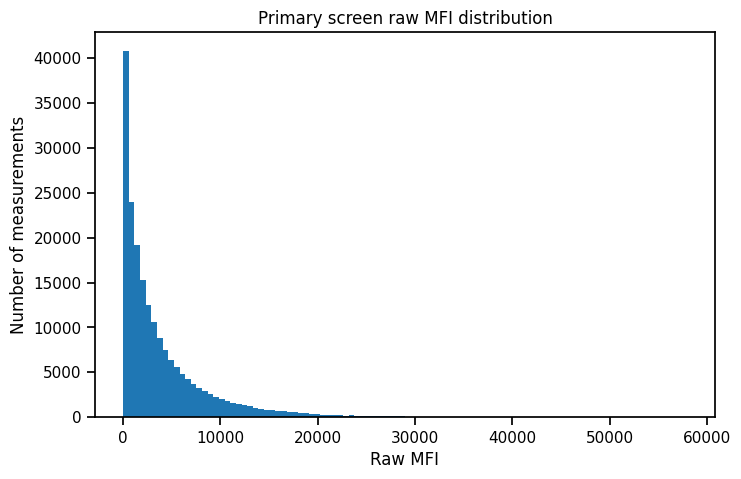

In [100]:
# Use a random sample so the plot is fast and readable
mfi_sample = primary_mfi_values.stack().sample(
    n=200_000,
    random_state=1
)

plt.figure(figsize=(8, 5))
plt.hist(mfi_sample, bins=100)
plt.xlabel("Raw MFI")
plt.ylabel("Number of measurements")
plt.title("Primary screen raw MFI distribution")
plt.show()

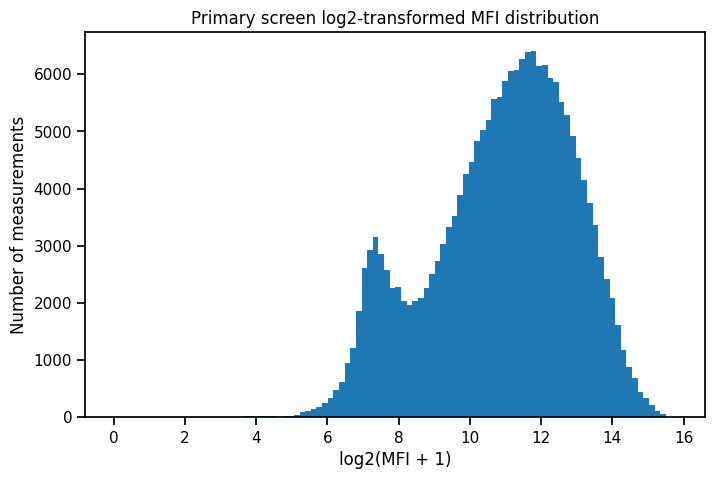

In [101]:
# Add 1 to avoid problems if any MFI values are zero
log2_mfi_sample = np.log2(mfi_sample + 1)

plt.figure(figsize=(8, 5))
plt.hist(log2_mfi_sample, bins=100)
plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of measurements")
plt.title("Primary screen log2-transformed MFI distribution")
plt.show()

In [102]:
non_positive_count = (primary_mfi_values <= 0).sum().sum()
non_positive_fraction = non_positive_count / primary_mfi_values.size

print("Non-positive MFI values:", non_positive_count)
print("Fraction non-positive MFI values:", non_positive_fraction)

Non-positive MFI values: 74
Fraction non-positive MFI values: 7.377789901281183e-06


### 1.3 Primary Control Behavior

Vehicle controls represent baseline viability under DMSO treatment. Positive controls are expected to reduce viability and therefore should generally produce lower MFI values.

A good screen should show separation between vehicle and positive controls. We first inspect this globally, then later at the plate and cell-line level.

In [103]:
vehicle_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "vehicle_control",
    "column_name"
].tolist()

positive_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "positive_control",
    "column_name"
].tolist()

experimental_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "experimental_treatment",
    "column_name"
].tolist()

print("Vehicle control wells:", len(vehicle_cols))
print("Positive control wells:", len(positive_cols))
print("Experimental treatment wells:", len(experimental_cols))

Vehicle control wells: 1518
Positive control wells: 1458
Experimental treatment wells: 14082


In [104]:
# Repair primary_well_metadata so column_name is preserved as a normal column

primary_well_metadata = (
    primary_treatment
    .set_index("column_name", drop=False)
    .loc[mfi_well_columns]
    .copy()
    .reset_index(drop=True)
)

print("primary_well_metadata shape:", primary_well_metadata.shape)
print("Columns:")
print(primary_well_metadata.columns.tolist())

print("\nDoes column_name exist?")
print("column_name" in primary_well_metadata.columns)

print("\nAlignment check:")
print(list(primary_well_metadata["column_name"]) == list(mfi_well_columns))

primary_well_metadata shape: (17058, 18)
Columns:
['column_name', 'broad_id', 'name', 'dose', 'perturbation_type', 'screen_id', 'detection_plate', 'compound_plate', 'well', 'detection_plate_scan_time', 'vendor_id', 'purity', 'moa', 'target', 'disease.area', 'indication', 'smiles', 'phase']

Does column_name exist?
True

Alignment check:
True


In [105]:
vehicle_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "vehicle_control",
    "column_name"
].tolist()

positive_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "positive_control",
    "column_name"
].tolist()

experimental_cols = primary_well_metadata.loc[
    primary_well_metadata["perturbation_type"] == "experimental_treatment",
    "column_name"
].tolist()

print("Vehicle control wells:", len(vehicle_cols))
print("Positive control wells:", len(positive_cols))
print("Experimental treatment wells:", len(experimental_cols))

Vehicle control wells: 1518
Positive control wells: 1458
Experimental treatment wells: 14082


In [106]:
vehicle_mfi_sample = primary_mfi_values[vehicle_cols].stack().sample(
    n=min(100_000, primary_mfi_values[vehicle_cols].stack().shape[0]),
    random_state=1
)

positive_mfi_sample = primary_mfi_values[positive_cols].stack().sample(
    n=min(100_000, primary_mfi_values[positive_cols].stack().shape[0]),
    random_state=1
)

control_mfi_summary = pd.DataFrame({
    "vehicle_control": vehicle_mfi_sample.describe(),
    "positive_control": positive_mfi_sample.describe(),
})

display(control_mfi_summary)

,vehicle_control,positive_control
count,97497.000000,97539.000000
mean,4330.305691,477.137212
std,5093.776256,1335.254137
min,15.000000,0.000000
25%,1028.000000,122.000000
50%,2562.000000,165.000000
75%,5708.000000,255.500000
max,59044.500000,50076.000000


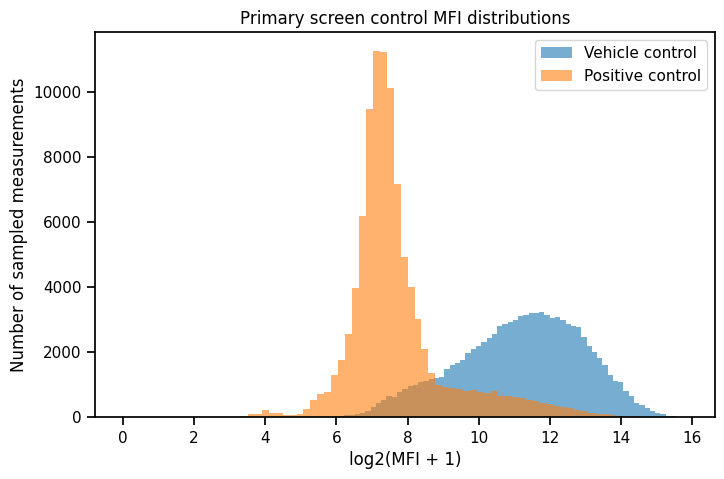

In [107]:
plt.figure(figsize=(8, 5))

plt.hist(
    np.log2(vehicle_mfi_sample + 1),
    bins=80,
    alpha=0.6,
    label="Vehicle control"
)

plt.hist(
    np.log2(positive_mfi_sample + 1),
    bins=80,
    alpha=0.6,
    label="Positive control"
)

plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of sampled measurements")
plt.title("Primary screen control MFI distributions")
plt.legend()
plt.show()

In [108]:
print("Median vehicle log2(MFI + 1):", np.log2(vehicle_mfi_sample + 1).median())
print("Median positive log2(MFI + 1):", np.log2(positive_mfi_sample + 1).median())
print("Difference, vehicle - positive:", np.log2(vehicle_mfi_sample + 1).median() - np.log2(positive_mfi_sample + 1).median())

Median vehicle log2(MFI + 1): 11.323617763291578
Median positive log2(MFI + 1): 7.3750394313469245
Difference, vehicle - positive: 3.9485783319446535


### 1.4 Plate-Level Primary Control Separation

The global control separation looked strong, but a good screen also needs consistent control behavior across detection plates.

For each detection plate, we summarize the median log2 MFI of vehicle controls and positive controls. A larger positive value for `vehicle_minus_positive` means the plate has clear assay dynamic range.

In [109]:
primary_log2_mfi_values = np.log2(primary_mfi_values + 1)

print("Primary log2 MFI matrix shape:", primary_log2_mfi_values.shape)

Primary log2 MFI matrix shape: (588, 17058)


In [110]:
well_log2_medians = primary_log2_mfi_values.median(axis=0, skipna=True)

primary_well_qc = primary_well_metadata.copy()
primary_well_qc["median_log2_mfi"] = primary_well_qc["column_name"].map(well_log2_medians)

display(primary_well_qc.head())

print("Missing well medians:", primary_well_qc["median_log2_mfi"].isna().sum())

,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.686501
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.240040
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical,12.106972
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched,12.117953
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical,12.149582


Missing well medians: 0


In [111]:
plate_control_qc = (
    primary_well_qc[
        primary_well_qc["perturbation_type"].isin(["vehicle_control", "positive_control"])
    ]
    .groupby(["detection_plate", "perturbation_type"])["median_log2_mfi"]
    .median()
    .unstack()
    .reset_index()
)

plate_control_qc["vehicle_minus_positive"] = (
    plate_control_qc["vehicle_control"] - plate_control_qc["positive_control"]
)

display(plate_control_qc.head(10))

print("Plate-level control separation summary:")
display(plate_control_qc["vehicle_minus_positive"].describe())

perturbation_type,detection_plate,positive_control,vehicle_control,vehicle_minus_positive
0,PMTS001_X1,8.139542,11.388533,3.248990
1,PMTS001_X2,8.390159,10.881640,2.491482
2,PMTS001_X3,7.967220,10.897608,2.930388
3,PMTS002_X1,8.125344,11.265981,3.140637
4,PMTS002_X2,7.874207,11.155975,3.281768
5,PMTS002_X3,8.318531,11.351066,3.032535
6,PMTS003_X1,8.959282,11.012106,2.052824
7,PMTS003_X2,8.330348,10.962980,2.632632
8,PMTS003_X3,8.422633,11.278934,2.856301
9,PREP001_X1,6.560319,11.938642,5.378323


Plate-level control separation summary:


count    48.000000
mean      3.964660
std       0.722172
min       2.052824
25%       3.459428
50%       4.143756
75%       4.367181
max       5.378323
Name: vehicle_minus_positive, dtype: float64

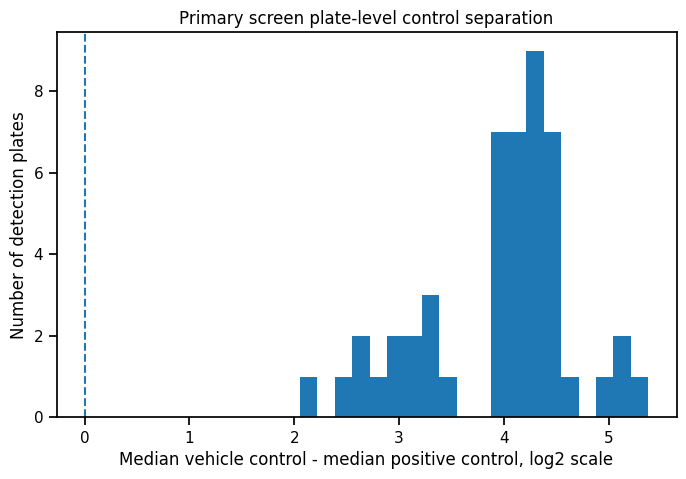

In [112]:
plt.figure(figsize=(8, 5))
plt.hist(plate_control_qc["vehicle_minus_positive"], bins=20)
plt.axvline(0, linestyle="--")
plt.xlabel("Median vehicle control - median positive control, log2 scale")
plt.ylabel("Number of detection plates")
plt.title("Primary screen plate-level control separation")
plt.show()

In [113]:
weak_control_plates = plate_control_qc.loc[
    plate_control_qc["vehicle_minus_positive"] <= 1
].copy()

print("Plates with vehicle-positive separation <= 1 log2 unit:")
print(weak_control_plates.shape[0])

display(weak_control_plates)

Plates with vehicle-positive separation <= 1 log2 unit:
0


perturbation_type,detection_plate,positive_control,vehicle_control,vehicle_minus_positive


**Plate-level control interpretation.** Vehicle controls show higher median log2(MFI + 1) than positive controls across all primary detection plates. This suggests that the primary screen has consistent plate-level assay dynamic range. At this stage, no detection plate is flagged for absent or failed control separation, although later QC steps may still identify well-level, cell-line-level, or batch-level issues.

### 1.5 Primary Cell-Line-Level QC

Each row in the primary MFI matrix represents a cell line barcode. Before normalization, we check whether each cell line has enough usable raw MFI measurements and whether its overall signal is unusually low.

This helps separate technical failures, such as poor barcode recovery, from true biological non-response.

In [114]:
primary_cell_line_qc = pd.DataFrame({
    "row_name": primary_cell_line_ids,
    "missing_fraction": primary_mfi_values.isna().mean(axis=1),
    "median_log2_mfi": primary_log2_mfi_values.median(axis=1, skipna=True),
    "mean_log2_mfi": primary_log2_mfi_values.mean(axis=1, skipna=True),
})

print("Primary cell-line QC shape:", primary_cell_line_qc.shape)
display(primary_cell_line_qc.head())

print("Cell-line missing fraction summary:")
display(primary_cell_line_qc["missing_fraction"].describe())

print("Cell-line median log2 MFI summary:")
display(primary_cell_line_qc["median_log2_mfi"].describe())

Primary cell-line QC shape: (588, 4)


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi
0,ACH-000001,0.002404,8.455327,8.497677
1,ACH-000007,0.000938,11.428884,10.901692
2,ACH-000008,0.000997,12.990370,12.342245
3,ACH-000010_FAILED_STR,0.000879,12.325727,11.817457
4,ACH-000011,0.000997,12.893207,12.244545


Cell-line missing fraction summary:


count    588.000000
mean       0.023795
std        0.130204
min        0.000469
25%        0.000938
50%        0.002052
75%        0.002404
max        1.000000
Name: missing_fraction, dtype: float64

Cell-line median log2 MFI summary:


count    578.000000
mean      11.327998
std        1.351126
min        7.679480
25%       10.334483
50%       11.425737
75%       12.302273
max       14.807682
Name: median_log2_mfi, dtype: float64

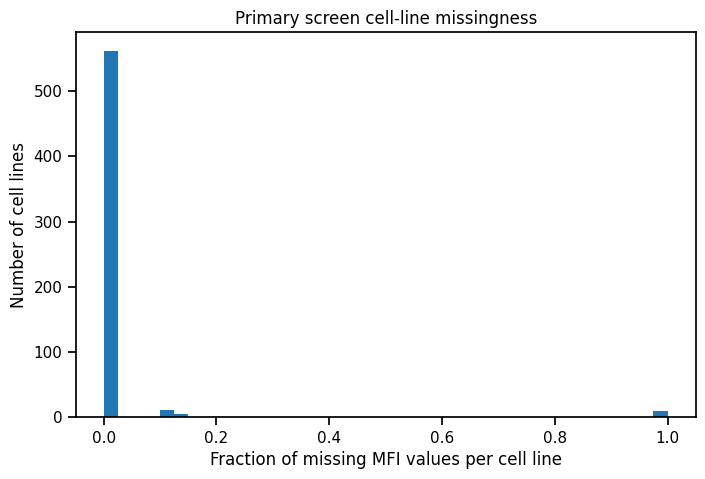

In [115]:
plt.figure(figsize=(8, 5))
plt.hist(primary_cell_line_qc["missing_fraction"], bins=40)
plt.xlabel("Fraction of missing MFI values per cell line")
plt.ylabel("Number of cell lines")
plt.title("Primary screen cell-line missingness")
plt.show()

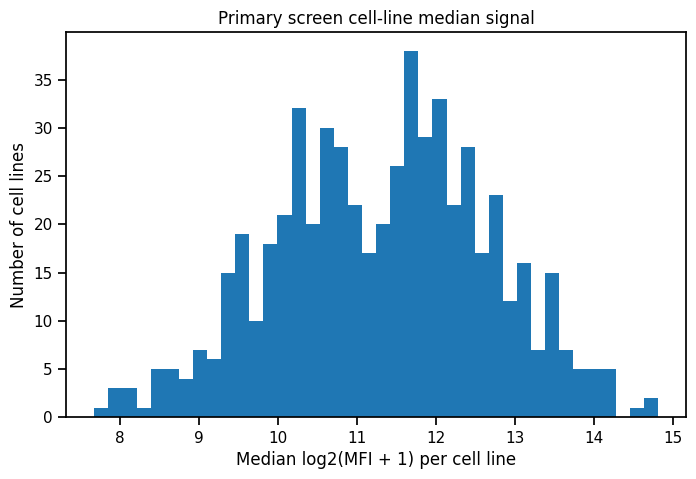

In [116]:
plt.figure(figsize=(8, 5))
plt.hist(primary_cell_line_qc["median_log2_mfi"], bins=40)
plt.xlabel("Median log2(MFI + 1) per cell line")
plt.ylabel("Number of cell lines")
plt.title("Primary screen cell-line median signal")
plt.show()

In [117]:
# high_missing_cell_lines = primary_cell_line_qc.loc[
#     primary_cell_line_qc["missing_fraction"] > 0.20
# ].copy()

# low_signal_threshold = primary_cell_line_qc["median_log2_mfi"].quantile(0.01)

# low_signal_cell_lines = primary_cell_line_qc.loc[
#     primary_cell_line_qc["median_log2_mfi"] <= low_signal_threshold
# ].copy()

# print("Cell lines with >20% missing values:", high_missing_cell_lines.shape[0])
# print("Low-signal threshold, bottom 1% median log2 MFI:", low_signal_threshold)
# print("Cell lines in bottom 1% signal:", low_signal_cell_lines.shape[0])

# display(high_missing_cell_lines.head())
# display(low_signal_cell_lines.head())

**Cell-line-level QC interpretation.** Most primary screen cell-line rows have very low missingness. The rows with 100% missing values are control barcode rows rather than cancer cell lines, so they should not be treated as biological non-response. A small number of real cell lines have low median signal and should be flagged for later caution rather than removed immediately.

In [118]:
primary_cell_line_qc["is_control_barcode"] = primary_cell_line_qc["row_name"].str.startswith("CONTROL_BARCODE")

print("Control barcode rows:")
display(primary_cell_line_qc["is_control_barcode"].value_counts())

display(
    primary_cell_line_qc.loc[
        primary_cell_line_qc["is_control_barcode"]
    ]
)

Control barcode rows:


is_control_barcode
False    578
True      10
Name: count, dtype: int64

,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode
578,CONTROL_BARCODE_1,1.0,NaN,NaN,True
579,CONTROL_BARCODE_10,1.0,NaN,NaN,True
580,CONTROL_BARCODE_2,1.0,NaN,NaN,True
581,CONTROL_BARCODE_3,1.0,NaN,NaN,True
582,CONTROL_BARCODE_4,1.0,NaN,NaN,True
583,CONTROL_BARCODE_5,1.0,NaN,NaN,True
584,CONTROL_BARCODE_6,1.0,NaN,NaN,True
585,CONTROL_BARCODE_7,1.0,NaN,NaN,True
586,CONTROL_BARCODE_8,1.0,NaN,NaN,True
587,CONTROL_BARCODE_9,1.0,NaN,NaN,True


### Cell-Line NaN Handling Policy

The NaN summaries observed in the primary cell-line QC occur in `CONTROL_BARCODE_*` rows. These rows have 100% missing MFI values and are not real cancer cell lines.

Because these rows are completely missing, they are excluded from biological analysis rather than imputed. Imputing them would invent artificial barcode abundance and could distort QC, normalization, and downstream hit calling.

For downstream biological analysis, we exclude control barcode rows and retain the real cancer cell lines. Partial missingness in real cell lines is preserved as missing data rather than filled silently.

In [119]:
# Verify that control barcode rows are completely missing
control_barcode_qc = primary_cell_line_qc.loc[
    primary_cell_line_qc["is_control_barcode"]
].copy()

print("Control barcode rows:", control_barcode_qc.shape[0])

display(control_barcode_qc[
    [
        "row_name",
        "missing_fraction",
        "median_log2_mfi",
        "mean_log2_mfi",
    ]
])

# These checks should pass if control barcode rows are completely missing
assert (control_barcode_qc["missing_fraction"] == 1.0).all()
assert control_barcode_qc["median_log2_mfi"].isna().all()
assert control_barcode_qc["mean_log2_mfi"].isna().all()

# Use only real cancer cell-line rows for downstream primary analysis
real_cell_line_mask = ~primary_cell_line_qc["is_control_barcode"]

primary_mfi_values_real = primary_mfi_values.loc[real_cell_line_mask].copy()
primary_log2_mfi_values_real = primary_log2_mfi_values.loc[real_cell_line_mask].copy()
primary_real_cell_line_ids = primary_cell_line_ids.loc[real_cell_line_mask].copy()

primary_real_cell_line_qc = primary_cell_line_qc.loc[
    real_cell_line_mask
].copy()

print("Real primary cell-line rows:", primary_real_cell_line_qc.shape[0])
print("Real-cell-line MFI matrix shape:", primary_mfi_values_real.shape)

print("Missingness among real cell lines:")
display(primary_real_cell_line_qc["missing_fraction"].describe())

Control barcode rows: 10


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi
578,CONTROL_BARCODE_1,1.0,NaN,NaN
579,CONTROL_BARCODE_10,1.0,NaN,NaN
580,CONTROL_BARCODE_2,1.0,NaN,NaN
581,CONTROL_BARCODE_3,1.0,NaN,NaN
582,CONTROL_BARCODE_4,1.0,NaN,NaN
583,CONTROL_BARCODE_5,1.0,NaN,NaN
584,CONTROL_BARCODE_6,1.0,NaN,NaN
585,CONTROL_BARCODE_7,1.0,NaN,NaN
586,CONTROL_BARCODE_8,1.0,NaN,NaN
587,CONTROL_BARCODE_9,1.0,NaN,NaN


Real primary cell-line rows: 578
Real-cell-line MFI matrix shape: (578, 17058)
Missingness among real cell lines:


count    578.000000
mean       0.006906
std        0.021095
min        0.000469
25%        0.000938
50%        0.002052
75%        0.002404
max        0.146031
Name: missing_fraction, dtype: float64

In [120]:
primary_real_cell_line_qc = primary_cell_line_qc.loc[
    ~primary_cell_line_qc["is_control_barcode"]
].copy()

print("Real primary cell-line rows:", primary_real_cell_line_qc.shape[0])

print("Missing fraction summary, real cell lines only:")
display(primary_real_cell_line_qc["missing_fraction"].describe())

print("Median log2 MFI summary, real cell lines only:")
display(primary_real_cell_line_qc["median_log2_mfi"].describe())

Real primary cell-line rows: 578
Missing fraction summary, real cell lines only:


count    578.000000
mean       0.006906
std        0.021095
min        0.000469
25%        0.000938
50%        0.002052
75%        0.002404
max        0.146031
Name: missing_fraction, dtype: float64

Median log2 MFI summary, real cell lines only:


count    578.000000
mean      11.327998
std        1.351126
min        7.679480
25%       10.334483
50%       11.425737
75%       12.302273
max       14.807682
Name: median_log2_mfi, dtype: float64

In [121]:
high_missing_real_cell_lines = primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["missing_fraction"] > 0.20
].copy()

low_signal_real_threshold = primary_real_cell_line_qc["median_log2_mfi"].quantile(0.01)

low_signal_real_cell_lines = primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["median_log2_mfi"] <= low_signal_real_threshold
].copy()

print("Real cell lines with >20% missing values:", high_missing_real_cell_lines.shape[0])
print("Low-signal threshold among real cell lines:", low_signal_real_threshold)
print("Real cell lines in bottom 1% signal:", low_signal_real_cell_lines.shape[0])

display(high_missing_real_cell_lines)
display(low_signal_real_cell_lines)

Real cell lines with >20% missing values: 0
Low-signal threshold among real cell lines: 8.186211797647424
Real cell lines in bottom 1% signal: 6


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode


,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode
53,ACH-000120,0.002404,7.888743,7.892716,False
63,ACH-000149,0.002169,8.116344,8.132129,False
236,ACH-000480,0.123696,7.906891,7.825486,False
264,ACH-000530,0.023449,7.679480,7.714691,False
267,ACH-000535,0.001290,8.182394,8.129789,False
269,ACH-000539_FAILED_STR,0.002169,7.918863,7.906264,False


### 1.6 Primary Well-Level QC

Each column in the primary MFI matrix is a physical well measurement. We now summarize each well across real cell lines to identify wells with high missingness or unusual signal.

These are descriptive QC flags only. We will not remove wells silently.

In [122]:
# Use only real cell-line rows for well-level QC
real_cell_line_mask = ~primary_cell_line_qc["is_control_barcode"]

primary_mfi_values_real = primary_mfi_values.loc[real_cell_line_mask]
primary_log2_mfi_values_real = primary_log2_mfi_values.loc[real_cell_line_mask]

primary_well_qc["missing_fraction_real_cell_lines"] = (
    primary_mfi_values_real.isna().mean(axis=0).values
)

primary_well_qc["mean_log2_mfi_real_cell_lines"] = (
    primary_log2_mfi_values_real.mean(axis=0, skipna=True).values
)

primary_well_qc["std_log2_mfi_real_cell_lines"] = (
    primary_log2_mfi_values_real.std(axis=0, skipna=True).values
)

print("Primary well QC shape:", primary_well_qc.shape)

print("Well missing fraction summary across real cell lines:")
display(primary_well_qc["missing_fraction_real_cell_lines"].describe())

print("Well median log2 MFI summary:")
display(primary_well_qc["median_log2_mfi"].describe())

display(primary_well_qc.head())

Primary well QC shape: (17058, 22)
Well missing fraction summary across real cell lines:


count    17058.000000
mean         0.006906
std          0.025289
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.541522
Name: missing_fraction_real_cell_lines, dtype: float64

Well median log2 MFI summary:


count    17058.000000
mean        10.877633
std          1.415861
min          4.339740
25%         10.764454
50%         11.394563
75%         11.706657
max         12.946174
Name: median_log2_mfi, dtype: float64

,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.686501,0.0,6.798198,1.472574
1,PREP001_X1:A02::HTS,NaN,NaN,NaN,vehicle_control,HTS,PREP001_X1,PREP001,A02,2/11/2016 10:09 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.240040,0.0,11.991264,1.565231
2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical,12.106972,0.0,11.946168,1.536249
3,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched,12.117953,0.0,11.928547,1.570674
4,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical,12.149582,0.0,11.984411,1.568564


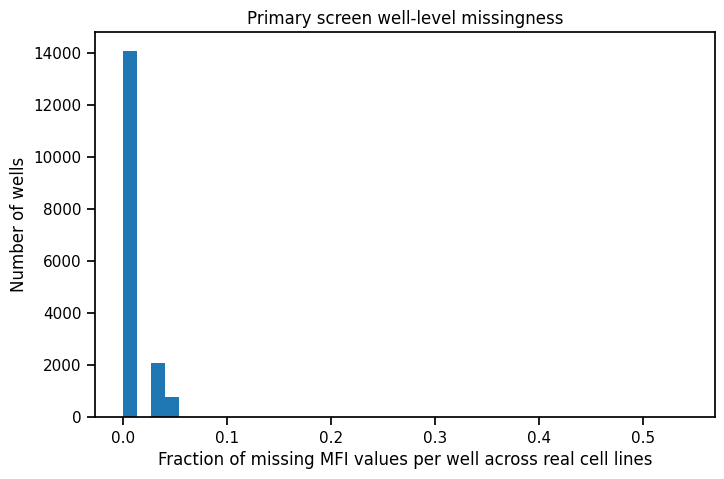

In [123]:
plt.figure(figsize=(8, 5))
plt.hist(primary_well_qc["missing_fraction_real_cell_lines"], bins=40)
plt.xlabel("Fraction of missing MFI values per well across real cell lines")
plt.ylabel("Number of wells")
plt.title("Primary screen well-level missingness")
plt.show()

In [124]:
high_missing_wells = primary_well_qc.loc[
    primary_well_qc["missing_fraction_real_cell_lines"] > 0.20
].copy()

low_signal_well_threshold = primary_well_qc["median_log2_mfi"].quantile(0.01)

low_signal_wells = primary_well_qc.loc[
    primary_well_qc["median_log2_mfi"] <= low_signal_well_threshold
].copy()

print("Wells with >20% missing values across real cell lines:", high_missing_wells.shape[0])
print("Low-signal well threshold, bottom 1% median log2 MFI:", low_signal_well_threshold)
print("Wells in bottom 1% signal:", low_signal_wells.shape[0])

display(high_missing_wells.head())
display(low_signal_wells.head())

Wells with >20% missing values across real cell lines: 68
Low-signal well threshold, bottom 1% median log2 MFI: 6.832890014164741
Wells in bottom 1% signal: 172


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines
56,PREP001_X1:C09::HTS,BRD-K64422603-300-02-7,N-alpha-Methylhistamine-dihydrochloride,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,C09,3/18/2016 12:51 PM,573,100.00,histamine receptor agonist,HRH4,NaN,NaN,CNCCc1cnc[nH]1,Phase 3,11.390302,0.519031,11.205868,1.824299
371,PREP001_X1:P12::HTS,BRD-K61397605-001-03-4,romidepsin,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,P12,3/18/2016 12:51 PM,HY-15149,98.84,HDAC inhibitor,"HDAC1, HDAC2, HDAC3, HDAC4, HDAC5, HDAC6, HDAC...",hematologic malignancy,cutaneous T-cell lymphoma (CTCL),C\C=C1/NC(=O)[C@H]2CSSCC\C=C\[C@H](CC(=O)N[C@H...,Launched,6.584963,0.519031,6.704562,0.656503
1688,PREP002_X2:G09::HTS,BRD-K47598052-001-15-8,PP-1,2.5,experimental_treatment,HTS,PREP002_X2,PREP002,G09,3/8/2016 10:47 AM,1397,99.39,src inhibitor,"HCK, RET",NaN,NaN,"Cc1ccc(cc1)-c1nn(c2ncnc(N)c12)C(C)(C)C, Cc1ccc...",Preclinical,10.756545,0.207612,10.679573,1.824342
1707,PREP002_X2:H04::HTS,BRD-A18233884-003-02-7,bevantolol,2.5,experimental_treatment,HTS,PREP002_X2,PREP002,H04,3/8/2016 10:47 AM,69996,94.05,adrenergic receptor antagonist,"ADRA1A, ADRB1, ADRB2",cardiology,"angina pectoris, hypertension",COc1ccc(CCNCC(O)COc2cccc(C)c2)cc1OC,Launched,11.384244,0.278547,11.240257,1.603364
1744,PREP002_X2:I17::HTS,BRD-K47827687-001-02-2,amprenavir,2.5,experimental_treatment,HTS,PREP002_X2,PREP002,I17,3/8/2016 10:47 AM,S1639,95.63,HIV protease inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1),CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,Launched,11.030658,0.411765,10.950990,1.709560


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines
0,PREP001_X1:A01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,A01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.686501,0.0,6.798198,1.472574
22,PREP001_X1:A23::HTS,BRD-K88510285-001-22-8,bortezomib,20.0,positive_control,HTS,PREP001_X1,PREP001,A23,2/11/2016 10:09 AM,S1013,NaN,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,Launched,6.442943,0.0,7.108742,1.897334
24,PREP001_X1:B01::HTS,BRD-K60230970-001-14-2,MG-132,20.0,positive_control,HTS,PREP001_X1,PREP001,B01,2/11/2016 10:09 AM,S2619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.781360,0.0,7.351259,1.420101
46,PREP001_X1:B23::HTS,BRD-K88510285-001-22-8,bortezomib,20.0,positive_control,HTS,PREP001_X1,PREP001,B23,2/11/2016 10:09 AM,S1013,NaN,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,Launched,6.566049,0.0,7.481949,1.998411
70,PREP001_X1:C23::HTS,BRD-K88510285-001-22-8,bortezomib,20.0,positive_control,HTS,PREP001_X1,PREP001,C23,2/11/2016 10:09 AM,S1013,NaN,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",CC(C)C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)c1cncc...,Launched,6.266787,0.0,6.868970,1.759053


**Well-level QC interpretation.** Most wells have low missingness across real cell lines, but 68 wells have more than 20% missing MFI values. Low median signal is not automatically a technical failure because positive controls are expected to reduce barcode abundance. The next check asks whether high-missing wells cluster by plate or perturbation type.

In [125]:
print("High-missing wells by perturbation type:")
display(
    high_missing_wells["perturbation_type"]
    .value_counts(dropna=False)
)

print("All wells by perturbation type:")
display(
    primary_well_qc["perturbation_type"]
    .value_counts(dropna=False)
)

High-missing wells by perturbation type:


perturbation_type
experimental_treatment    57
positive_control           6
vehicle_control            5
Name: count, dtype: int64

All wells by perturbation type:


perturbation_type
experimental_treatment    14082
vehicle_control            1518
positive_control           1458
Name: count, dtype: int64

In [126]:
high_missing_by_plate = (
    high_missing_wells
    .groupby("detection_plate")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="high_missing_well_count")
)

display(high_missing_by_plate.head(20))

print("Number of plates with at least one high-missing well:")
print(high_missing_by_plate.shape[0])

,detection_plate,high_missing_well_count
0,PREP004_X1,7
1,PREP008_X3,7
2,PREP006_X2,6
3,PREP011_X2,5
4,PREP005_X3,3
5,PREP003_X3,3
6,PREP002_X2,3
7,PREP012_X1,3
8,PREP011_X1,3
9,PMTS002_X2,3


Number of plates with at least one high-missing well:
28


In [127]:
plate_well_counts = (
    primary_well_qc
    .groupby("detection_plate")
    .size()
    .reset_index(name="total_wells")
)

plate_missing_qc = (
    plate_well_counts
    .merge(high_missing_by_plate, on="detection_plate", how="left")
)

plate_missing_qc["high_missing_well_count"] = (
    plate_missing_qc["high_missing_well_count"].fillna(0).astype(int)
)

plate_missing_qc["high_missing_well_fraction"] = (
    plate_missing_qc["high_missing_well_count"] / plate_missing_qc["total_wells"]
)

plate_missing_qc = plate_missing_qc.sort_values(
    "high_missing_well_fraction",
    ascending=False
)

display(plate_missing_qc.head(20))

,detection_plate,total_wells,high_missing_well_count,high_missing_well_fraction
32,PREP008_X3,384,7,0.018229
18,PREP004_X1,384,7,0.018229
25,PREP006_X2,384,6,0.015625
40,PREP011_X2,379,5,0.013193
4,PMTS002_X2,283,3,0.010601
39,PREP011_X1,379,3,0.007916
23,PREP005_X3,384,3,0.007812
13,PREP002_X2,384,3,0.007812
17,PREP003_X3,384,3,0.007812
22,PREP005_X2,384,3,0.007812


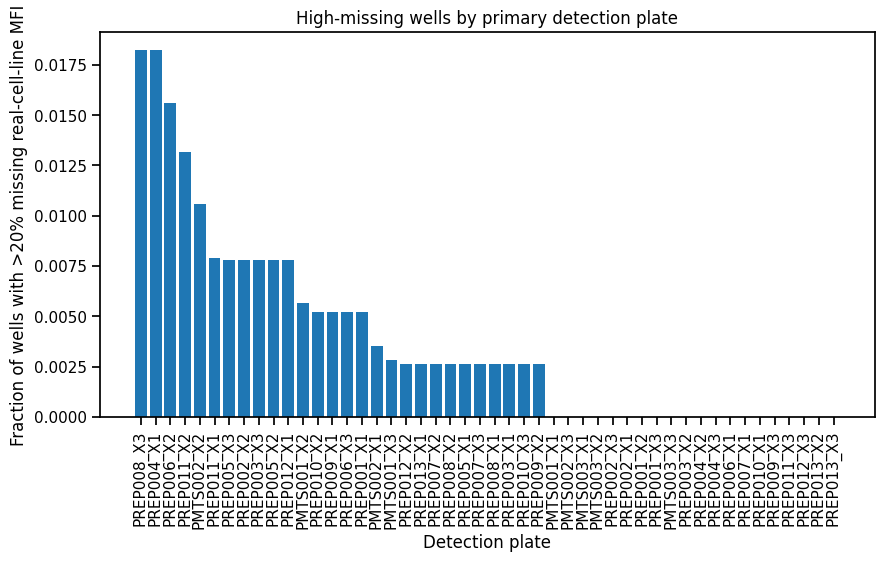

In [128]:
plt.figure(figsize=(10, 5))
plt.bar(
    plate_missing_qc["detection_plate"],
    plate_missing_qc["high_missing_well_fraction"]
)
plt.xticks(rotation=90)
plt.xlabel("Detection plate")
plt.ylabel("Fraction of wells with >20% missing real-cell-line MFI")
plt.title("High-missing wells by primary detection plate")
plt.show()

### 1.7 Primary QC Decision Table

QC flags should be explicit and reproducible. Here we combine the primary QC results into simple flags for wells and cell lines.

At this stage, we are not permanently deleting data. We are marking technical concerns so that later normalization and hit calling can either exclude or stratify affected measurements in a transparent way.

In [129]:
primary_well_qc["flag_high_missing"] = (
    primary_well_qc["missing_fraction_real_cell_lines"] > 0.20
)

primary_well_qc["flag_low_signal"] = (
    primary_well_qc["median_log2_mfi"] <= low_signal_well_threshold
)

primary_well_qc["qc_flag"] = "pass"

primary_well_qc.loc[
    primary_well_qc["flag_high_missing"],
    "qc_flag"
] = "high_missing"

primary_well_qc.loc[
    primary_well_qc["flag_low_signal"] & ~primary_well_qc["flag_high_missing"],
    "qc_flag"
] = "low_signal"

print("Primary well QC flag counts:")
display(primary_well_qc["qc_flag"].value_counts())

Primary well QC flag counts:


qc_flag
pass            16819
low_signal        171
high_missing       68
Name: count, dtype: int64

In [130]:
well_qc_by_type = (
    primary_well_qc
    .groupby(["perturbation_type", "qc_flag"])
    .size()
    .unstack(fill_value=0)
)

display(well_qc_by_type)

qc_flag,high_missing,low_signal,pass
perturbation_type,,,
experimental_treatment,57,16,14009
positive_control,6,155,1297
vehicle_control,5,0,1513


In [131]:
primary_real_cell_line_qc["flag_high_missing"] = (
    primary_real_cell_line_qc["missing_fraction"] > 0.20
)

primary_real_cell_line_qc["flag_low_signal"] = (
    primary_real_cell_line_qc["median_log2_mfi"] <= low_signal_real_threshold
)

primary_real_cell_line_qc["qc_flag"] = "pass"

primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["flag_high_missing"],
    "qc_flag"
] = "high_missing"

primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["flag_low_signal"] & ~primary_real_cell_line_qc["flag_high_missing"],
    "qc_flag"
] = "low_signal"

print("Primary real cell-line QC flag counts:")
display(primary_real_cell_line_qc["qc_flag"].value_counts())

display(primary_real_cell_line_qc.loc[
    primary_real_cell_line_qc["qc_flag"] != "pass"
])

Primary real cell-line QC flag counts:


qc_flag
pass          572
low_signal      6
Name: count, dtype: int64

,row_name,missing_fraction,median_log2_mfi,mean_log2_mfi,is_control_barcode,flag_high_missing,flag_low_signal,qc_flag
53,ACH-000120,0.002404,7.888743,7.892716,False,False,True,low_signal
63,ACH-000149,0.002169,8.116344,8.132129,False,False,True,low_signal
236,ACH-000480,0.123696,7.906891,7.825486,False,False,True,low_signal
264,ACH-000530,0.023449,7.679480,7.714691,False,False,True,low_signal
267,ACH-000535,0.001290,8.182394,8.129789,False,False,True,low_signal
269,ACH-000539_FAILED_STR,0.002169,7.918863,7.906264,False,False,True,low_signal


In [132]:
primary_well_qc.to_csv(
    TABLES_DIR / "primary_well_qc.csv",
    index=False
)

primary_real_cell_line_qc.to_csv(
    TABLES_DIR / "primary_real_cell_line_qc.csv",
    index=False
)

plate_control_qc.to_csv(
    TABLES_DIR / "primary_plate_control_qc.csv",
    index=False
)

print("Saved primary QC tables:")
print(TABLES_DIR / "primary_well_qc.csv")
print(TABLES_DIR / "primary_real_cell_line_qc.csv")
print(TABLES_DIR / "primary_plate_control_qc.csv")

Saved primary QC tables:
C:\Users\shash\Desktop\Code for assignment\results\tables\primary_well_qc.csv
C:\Users\shash\Desktop\Code for assignment\results\tables\primary_real_cell_line_qc.csv
C:\Users\shash\Desktop\Code for assignment\results\tables\primary_plate_control_qc.csv


### Section 1 Multiple-Choice Question

**Question.** Based on the primary screen QC, which statement best describes the main technical interpretation before normalization?

A) The primary screen should be discarded because many detection plates lack vehicle or positive controls.  
B) The primary screen has usable plate-level dynamic range, but a small number of wells and low-signal cell lines should be flagged before normalization.  
C) Low-signal wells should all be removed because low MFI always indicates technical failure.  
D) The fully missing control barcode rows indicate that many cancer cell lines failed barcode detection.

**Best answer: B**

**Rationale.** Vehicle and positive controls are present on all detection plates and show clear separation, supporting usable assay dynamic range. Some wells have high missingness and a small number of real cell lines have low signal, so these should be tracked as QC flags. Low MFI is not automatically failure because positive controls are expected to lower barcode abundance. Fully missing control barcode rows are not cancer cell lines.

## 2. Primary Screen Normalization and Hit Calling

The primary screen tested compounds at a single dose. Before identifying hits, raw MFI values must be normalized relative to vehicle controls.

For each detection plate, we use the vehicle-control wells on that same plate to estimate the baseline barcode abundance for each real cancer cell line. Then each treatment well is expressed relative to that plate-specific vehicle baseline.

This gives a normalized viability estimate:

- viability near 1 means similar to DMSO control,
- viability below 1 means reduced barcode abundance / reduced viability,
- viability above 1 means higher barcode abundance than DMSO.

We first build and validate the normalized matrix before defining hit-calling thresholds.

In [133]:
# Use real cancer cell lines only
# Exclude high-missing wells from normalization calculations

usable_well_mask = ~primary_well_qc["flag_high_missing"]

usable_vehicle_cols = primary_well_qc.loc[
    usable_well_mask
    & (primary_well_qc["perturbation_type"] == "vehicle_control"),
    "column_name"
].tolist()

usable_experimental_cols = primary_well_qc.loc[
    usable_well_mask
    & (primary_well_qc["perturbation_type"] == "experimental_treatment"),
    "column_name"
].tolist()

usable_positive_cols = primary_well_qc.loc[
    usable_well_mask
    & (primary_well_qc["perturbation_type"] == "positive_control"),
    "column_name"
].tolist()

print("Usable vehicle-control wells:", len(usable_vehicle_cols))
print("Usable experimental-treatment wells:", len(usable_experimental_cols))
print("Usable positive-control wells:", len(usable_positive_cols))
print("High-missing wells excluded:", primary_well_qc["flag_high_missing"].sum())

Usable vehicle-control wells: 1513
Usable experimental-treatment wells: 14025
Usable positive-control wells: 1452
High-missing wells excluded: 68


In [134]:
# For each detection plate, compute the median vehicle-control log2 MFI
# for every real cancer cell line.

vehicle_baselines = {}

for plate in primary_well_qc["detection_plate"].dropna().unique():
    plate_vehicle_cols = primary_well_qc.loc[
        usable_well_mask
        & (primary_well_qc["detection_plate"] == plate)
        & (primary_well_qc["perturbation_type"] == "vehicle_control"),
        "column_name"
    ].tolist()
    
    if len(plate_vehicle_cols) == 0:
        print("No usable vehicle controls for plate:", plate)
        continue
    
    vehicle_baselines[plate] = primary_log2_mfi_values_real[plate_vehicle_cols].median(
        axis=1,
        skipna=True
    )

print("Number of plates with vehicle baseline:", len(vehicle_baselines))
print("Total detection plates:", primary_well_qc["detection_plate"].nunique())

Number of plates with vehicle baseline: 48
Total detection plates: 48


In [135]:
# Create normalized log2 fold-change matrix:
# log2FC = log2(MFI + 1) - median log2(DMSO MFI + 1) from the same plate.

primary_log2fc = pd.DataFrame(
    index=primary_log2_mfi_values_real.index,
    columns=primary_log2_mfi_values_real.columns,
    dtype=float
)

for plate, baseline in vehicle_baselines.items():
    plate_cols = primary_well_qc.loc[
        primary_well_qc["detection_plate"] == plate,
        "column_name"
    ].tolist()
    
    primary_log2fc[plate_cols] = primary_log2_mfi_values_real[plate_cols].subtract(
        baseline,
        axis=0
    )

print("Primary log2 fold-change matrix shape:", primary_log2fc.shape)
display(primary_log2fc.iloc[:5, :5])

Primary log2 fold-change matrix shape: (578, 17058)


,PREP001_X1:A01::HTS,PREP001_X1:A02::HTS,PREP001_X1:A03::HTS,PREP001_X1:A04::HTS,PREP001_X1:A05::HTS
0,-1.185831,-0.225724,-0.078448,0.921552,0.405674
1,-2.379019,0.388548,0.427348,-0.680079,1.095478
2,-3.671224,-0.630834,0.168748,0.147319,0.328019
3,-4.481649,0.364033,-0.291446,0.548310,0.511121
4,-7.156128,-0.048408,-0.535541,-0.072423,0.432760


In [136]:
# Convert log2 fold-change to relative viability.
# A value of 1 means equal to DMSO baseline.
# A value below 1 means reduced viability/barcode abundance.

primary_viability = 2 ** primary_log2fc

print("Primary viability matrix shape:", primary_viability.shape)

print("Primary viability summary:")
display(primary_viability.stack().describe())

Primary viability matrix shape: (578, 17058)
Primary viability summary:


count    9.791433e+06
mean     1.021108e+00
std      1.028320e+00
min      4.484025e-05
25%      5.774528e-01
50%      9.394499e-01
75%      1.285410e+00
max      1.107581e+02
dtype: float64

Vehicle-control viability summary:


count    868429.000000
mean          1.074111
std           0.778684
min           0.000175
25%           0.721140
50%           1.000000
75%           1.296963
max          74.783703
dtype: float64

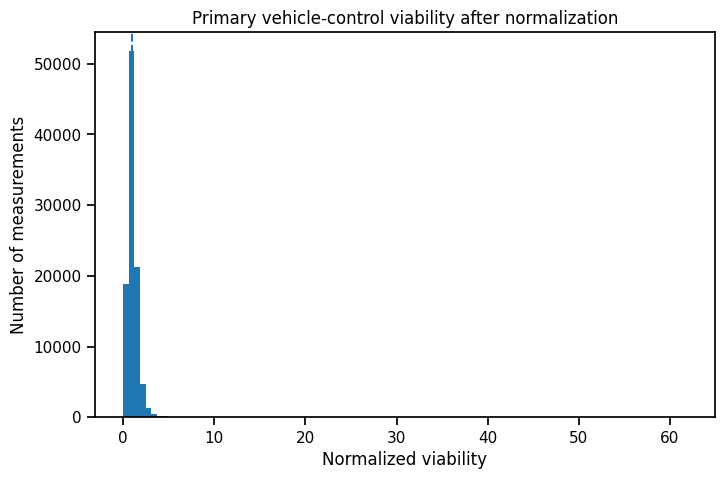

In [137]:
vehicle_viability_values = primary_viability[usable_vehicle_cols].stack()

print("Vehicle-control viability summary:")
display(vehicle_viability_values.describe())

plt.figure(figsize=(8, 5))
plt.hist(vehicle_viability_values.sample(n=min(100_000, len(vehicle_viability_values)), random_state=1), bins=100)
plt.axvline(1, linestyle="--")
plt.xlabel("Normalized viability")
plt.ylabel("Number of measurements")
plt.title("Primary vehicle-control viability after normalization")
plt.show()

Positive-control viability summary:


count    834219.000000
mean          0.208019
std           0.996029
min           0.000168
25%           0.032979
50%           0.076072
75%           0.172432
max          92.174932
dtype: float64

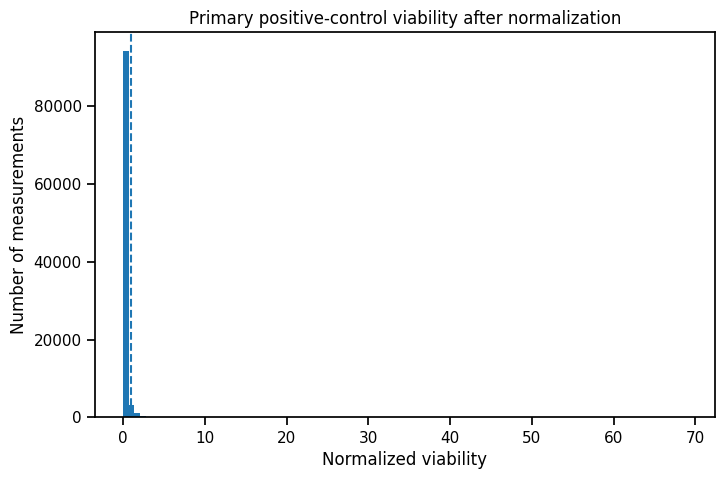

In [138]:
positive_viability_values = primary_viability[usable_positive_cols].stack()

print("Positive-control viability summary:")
display(positive_viability_values.describe())

plt.figure(figsize=(8, 5))
plt.hist(positive_viability_values.sample(n=min(100_000, len(positive_viability_values)), random_state=1), bins=100)
plt.axvline(1, linestyle="--")
plt.xlabel("Normalized viability")
plt.ylabel("Number of measurements")
plt.title("Primary positive-control viability after normalization")
plt.show()

### Normalization Checkpoint Interpretation

The primary screen has now been normalized relative to plate-specific vehicle controls. This is the key transition from raw MFI values to relative viability.

The expected pattern is:

- vehicle controls are centered near viability = 1,
- positive controls are shifted below viability = 1,
- experimental treatments can now be interpreted on a comparable viability scale.

This normalization preserves the raw data unchanged and creates a derived matrix for downstream hit calling.

### Build the primary hit-calling analysis table

Before applying the paper-aligned sensitivity threshold, we need a tidy treatment-level table and a replicate-collapsed compound–cell-line table. The normalized matrices are wide-format objects, with cell lines as rows and wells as columns. Hit calling requires one row per compound–cell-line pair after replicate wells have been summarized.

This block creates:

- `primary_normalized_long`: one row per cell-line / treatment-well measurement,
- `primary_collapsed`: one row per cell-line / compound / dose after replicate collapse.

These tables are required by the paper-aligned hit-calling cells below.

In [139]:
# Required object check before building the hit-calling tables

required_objects = [
    "primary_well_qc",
    "primary_viability",
    "primary_log2fc",
    "primary_real_cell_line_ids",
    "usable_experimental_cols",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects: "
        + ", ".join(missing_objects)
        + "\nPlease run the notebook from the beginning through primary normalization first."
    )

print("All required objects are present.")
print("primary_well_qc shape:", primary_well_qc.shape)
print("primary_viability shape:", primary_viability.shape)
print("primary_log2fc shape:", primary_log2fc.shape)
print("usable experimental-treatment wells:", len(usable_experimental_cols))

All required objects are present.
primary_well_qc shape: (17058, 25)
primary_viability shape: (578, 17058)
primary_log2fc shape: (578, 17058)
usable experimental-treatment wells: 14025


In [140]:
# Build metadata for usable experimental-treatment wells only

primary_experimental_metadata = primary_well_qc[
    primary_well_qc["column_name"].isin(usable_experimental_cols)
].copy()

# Preserve the same order as the normalized matrices.
primary_experimental_metadata = (
    primary_experimental_metadata
    .set_index("column_name", drop=False)
    .loc[usable_experimental_cols]
    .reset_index(drop=True)
)

print("Experimental-treatment metadata shape:")
print(primary_experimental_metadata.shape)

print("\nPerturbation type counts:")
display(primary_experimental_metadata["perturbation_type"].value_counts(dropna=False))

print("\nDose counts:")
display(primary_experimental_metadata["dose"].value_counts(dropna=False).sort_index())

print("\nQC flag counts among usable experimental-treatment wells:")
display(primary_experimental_metadata["qc_flag"].value_counts(dropna=False))

print("\nPreview:")
display(primary_experimental_metadata.head())

Experimental-treatment metadata shape:
(14025, 25)

Perturbation type counts:


perturbation_type
experimental_treatment    14025
Name: count, dtype: int64


Dose counts:


dose
0.030000     6
0.250000    39
0.800000     3
0.910000     3
0.940000     3
            ..
2.890000     3
3.119535     3
3.160000     3
5.000000     9
5.600000     3
Name: count, Length: 416, dtype: int64


QC flag counts among usable experimental-treatment wells:


qc_flag
pass          14009
low_signal       16
Name: count, dtype: int64


Preview:


,column_name,broad_id,name,dose,perturbation_type,screen_id,detection_plate,compound_plate,well,detection_plate_scan_time,vendor_id,purity,moa,target,disease.area,indication,smiles,phase,median_log2_mfi,missing_fraction_real_cell_lines,mean_log2_mfi_real_cell_lines,std_log2_mfi_real_cell_lines,flag_high_missing,flag_low_signal,qc_flag
0,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A03,2/11/2016 10:09 AM,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,CCOC(=O)C1CN(Cc2ccccc2)C(=O)C1=O,Preclinical,12.106972,0.0,11.946168,1.536249,False,False,pass
1,PREP001_X1:A04::HTS,BRD-K35559145-050-08-5,levomepromazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A04,2/11/2016 10:09 AM,Prestw-797,76.90,dopamine receptor antagonist,"ADRA1A, ADRA1B, ADRA1D, ADRA2A, ADRA2B, ADRA2C...","neurology/psychiatry, gastroenterology","psychosis, schizophrenia, bipolar disorder, na...","COc1ccc2Sc3ccccc3N(C[C@H](C)CN(C)C)c2c1, COc1c...",Launched,12.117953,0.0,11.928547,1.570674,False,False,pass
2,PREP001_X1:A05::HTS,BRD-A48015106-004-08-9,8-hydroxy-DPAT,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A05,2/11/2016 10:09 AM,529,93.13,serotonin receptor agonist,"CDK1, CHEK1, CHEK2, GSK3B, HTR5A, HTR7, LCK, M...",NaN,NaN,CCCN(CCC)C1CCc2cccc(O)c2C1,Preclinical,12.149582,0.0,11.984411,1.568564,False,False,pass
3,PREP001_X1:A06::HTS,BRD-A59198242-003-02-9,viloxazine,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A06,2/11/2016 10:09 AM,Prestw-1361,98.75,norepinephrine reuptake inhibitor,SLC6A2,neurology/psychiatry,depression,CCOc1ccccc1OCC1CNCCO1,Launched,12.139709,0.0,11.939474,1.557989,False,False,pass
4,PREP001_X1:A07::HTS,BRD-A30590053-003-02-9,MR-16728,2.5,experimental_treatment,HTS,PREP001_X1,PREP001,A07,2/11/2016 10:09 AM,537,93.83,acetylcholine release enhancer,NaN,NaN,NaN,O=C(NCCCN1CCCCCC1)C(C1CCCCC1)c1ccccc1,Preclinical,12.123796,0.0,11.899547,1.595285,False,False,pass


In [141]:
# Create long-format normalized primary table for usable experimental-treatment wells

experimental_columns = primary_experimental_metadata["column_name"].tolist()

missing_from_viability = sorted(set(experimental_columns) - set(primary_viability.columns))
missing_from_log2fc = sorted(set(experimental_columns) - set(primary_log2fc.columns))

if missing_from_viability or missing_from_log2fc:
    raise ValueError(
        f"Columns missing from primary_viability: {len(missing_from_viability)}\n"
        f"Columns missing from primary_log2fc: {len(missing_from_log2fc)}"
    )

# Use melt rather than stack because pandas versions differ in stack(dropna=False) behavior.
viability_long = (
    primary_viability[experimental_columns]
    .reset_index()
    .melt(
        id_vars=primary_viability.index.name or "index",
        var_name="column_name",
        value_name="viability",
    )
)

log2fc_long = (
    primary_log2fc[experimental_columns]
    .reset_index()
    .melt(
        id_vars=primary_log2fc.index.name or "index",
        var_name="column_name",
        value_name="log2fc",
    )
)

row_index_col = primary_viability.index.name or "index"
viability_long = viability_long.rename(columns={row_index_col: "row_index"})
log2fc_long = log2fc_long.rename(columns={row_index_col: "row_index"})

cell_line_lookup = (
    primary_real_cell_line_ids
    .rename("row_name")
    .reset_index()
    .rename(columns={"index": "row_index"})
)

primary_normalized_long = viability_long.merge(
    log2fc_long,
    on=["row_index", "column_name"],
    how="inner",
    validate="one_to_one",
)

primary_normalized_long = primary_normalized_long.merge(
    cell_line_lookup,
    on="row_index",
    how="left",
    validate="many_to_one",
)

metadata_cols = [
    col for col in [
        "column_name",
        "broad_id",
        "name",
        "dose",
        "perturbation_type",
        "screen_id",
        "detection_plate",
        "compound_plate",
        "well",
        "vendor_id",
        "purity",
        "moa",
        "target",
        "disease.area",
        "indication",
        "phase",
        "qc_flag",
        "flag_high_missing",
        "flag_low_signal",
        "missing_fraction_real_cell_lines",
        "median_log2_mfi",
    ]
    if col in primary_experimental_metadata.columns
]

primary_normalized_long = primary_normalized_long.merge(
    primary_experimental_metadata[metadata_cols],
    on="column_name",
    how="left",
    validate="many_to_one",
)

front_cols = [
    "row_name",
    "row_index",
    "column_name",
    "broad_id",
    "name",
    "dose",
    "viability",
    "log2fc",
]
front_cols = [col for col in front_cols if col in primary_normalized_long.columns]
other_cols = [col for col in primary_normalized_long.columns if col not in front_cols]
primary_normalized_long = primary_normalized_long[front_cols + other_cols]

print("Long normalized table shape:")
print(primary_normalized_long.shape)

print("\nMissing values in key columns:")
key_cols = ["row_name", "column_name", "broad_id", "name", "dose", "viability", "log2fc", "qc_flag"]
key_cols = [col for col in key_cols if col in primary_normalized_long.columns]
display(primary_normalized_long[key_cols].isna().sum())

print("\nUnique compounds:")
print(primary_normalized_long["broad_id"].nunique())

print("\nUnique cell lines:")
print(primary_normalized_long["row_name"].nunique())

print("\nUnique treatment wells:")
print(primary_normalized_long["column_name"].nunique())

print("\nPreview:")
display(primary_normalized_long.head())

C:\Users\shash\AppData\Local\Temp\ipykernel_20916\3479754261.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\shash\AppData\Local\Temp\ipykernel_20916\3479754261.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


Long normalized table shape:
(8106450, 25)

Missing values in key columns:


row_name           0
column_name        0
broad_id           0
name            1734
dose               0
viability      43681
log2fc         43681
qc_flag            0
dtype: int64


Unique compounds:
4686

Unique cell lines:
578

Unique treatment wells:
14025

Preview:


,row_name,row_index,column_name,broad_id,name,dose,viability,log2fc,perturbation_type,screen_id,detection_plate,compound_plate,well,vendor_id,purity,moa,target,disease.area,indication,phase,qc_flag,flag_high_missing,flag_low_signal,missing_fraction_real_cell_lines,median_log2_mfi
0,ACH-000001,0,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,0.947076,-0.078448,experimental_treatment,HTS,PREP001_X1,PREP001,A03,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,Preclinical,pass,False,False,0.0,12.106972
1,ACH-000007,1,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,1.344759,0.427348,experimental_treatment,HTS,PREP001_X1,PREP001,A03,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,Preclinical,pass,False,False,0.0,12.106972
2,ACH-000008,2,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,1.124082,0.168748,experimental_treatment,HTS,PREP001_X1,PREP001,A03,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,Preclinical,pass,False,False,0.0,12.106972
3,ACH-000010_FAILED_STR,3,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,0.817083,-0.291446,experimental_treatment,HTS,PREP001_X1,PREP001,A03,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,Preclinical,pass,False,False,0.0,12.106972
4,ACH-000011,4,PREP001_X1:A03::HTS,BRD-A96485169-001-14-3,EBPC,2.5,0.689900,-0.535541,experimental_treatment,HTS,PREP001_X1,PREP001,A03,518,91.11,aldose reductase inhibitor,AKR1B1,NaN,NaN,Preclinical,pass,False,False,0.0,12.106972


In [142]:
# Validate that long-table values match the source normalized matrices

example = (
    primary_normalized_long
    .dropna(subset=["viability", "log2fc"])
    .sample(n=1, random_state=1)
    .iloc[0]
)

example_row_index = example["row_index"]
example_column = example["column_name"]

matrix_viability = primary_viability.loc[example_row_index, example_column]
matrix_log2fc = primary_log2fc.loc[example_row_index, example_column]

print("Random alignment check")
print("----------------------")
print("row_name:", example["row_name"])
print("row_index:", example_row_index)
print("column_name:", example_column)

print("\nValues from long table:")
print("viability:", example["viability"])
print("log2fc:", example["log2fc"])

print("\nValues from source matrices:")
print("viability:", matrix_viability)
print("log2fc:", matrix_log2fc)

assert example["viability"] == matrix_viability
assert example["log2fc"] == matrix_log2fc

print("\nAlignment check passed.")

Random alignment check
----------------------
row_name: ACH-000120
row_index: 53
column_name: PREP008_X2:A07::HTS

Values from long table:
viability: 1.1588280611183943
log2fc: 0.2126665251249822

Values from source matrices:
viability: 1.1588280611183943
log2fc: 0.2126665251249822

Alignment check passed.


In [143]:
# Collapse replicate treatment wells per compound-cell-line pair

replicate_group_cols = [
    "row_name",
    "broad_id",
    "name",
    "dose",
]

annotation_cols = [
    col for col in [
        "moa",
        "target",
        "disease.area",
        "indication",
        "phase",
    ]
    if col in primary_normalized_long.columns
]

primary_collapsed = (
    primary_normalized_long
    .groupby(replicate_group_cols, dropna=False)
    .agg(
        median_viability=("viability", "median"),
        median_log2fc=("log2fc", "median"),
        mean_viability=("viability", "mean"),
        min_viability=("viability", "min"),
        max_viability=("viability", "max"),
        n_total_wells=("viability", "size"),
        n_nonmissing_wells=("viability", "count"),
        viability_sd=("viability", "std"),
        log2fc_sd=("log2fc", "std"),
        n_unique_treatment_wells=("column_name", "nunique"),
        n_flagged_wells=("qc_flag", lambda x: (x != "pass").sum()),
        compound_plates=("compound_plate", lambda x: ";".join(sorted(x.dropna().astype(str).unique()))),
        detection_plates=("detection_plate", lambda x: ";".join(sorted(x.dropna().astype(str).unique()))),
    )
    .reset_index()
)

if annotation_cols:
    annotations = (
        primary_normalized_long[["broad_id", "name", "dose"] + annotation_cols]
        .drop_duplicates()
        .groupby(["broad_id", "name", "dose"], dropna=False)
        .first()
        .reset_index()
    )

    primary_collapsed = primary_collapsed.merge(
        annotations,
        on=["broad_id", "name", "dose"],
        how="left",
        validate="many_to_one",
    )

primary_collapsed["has_replicate_support"] = primary_collapsed["n_nonmissing_wells"] >= 2

print("Collapsed compound-cell-line table shape:")
print(primary_collapsed.shape)

print("\nReplicate count distribution:")
display(primary_collapsed["n_nonmissing_wells"].value_counts(dropna=False).sort_index())

print("\nSummary of collapsed viability:")
display(primary_collapsed["median_viability"].describe())

print("\nRows with no nonmissing viability values:")
print((primary_collapsed["n_nonmissing_wells"] == 0).sum())

print("\nPreview:")
display(primary_collapsed.head())

Collapsed compound-cell-line table shape:
(2708508, 23)

Replicate count distribution:


n_nonmissing_wells
0       8624
1        176
2      50403
3    2644681
6       4624
Name: count, dtype: int64


Summary of collapsed viability:


count    2.699884e+06
mean     1.020728e+00
std      4.963493e-01
min      3.262414e-03
25%      7.687490e-01
50%      9.944882e-01
75%      1.234700e+00
max      4.026928e+01
Name: median_viability, dtype: float64


Rows with no nonmissing viability values:
8624

Preview:


,row_name,broad_id,name,dose,median_viability,median_log2fc,mean_viability,min_viability,max_viability,n_total_wells,n_nonmissing_wells,viability_sd,log2fc_sd,n_unique_treatment_wells,n_flagged_wells,compound_plates,detection_plates,moa,target,disease.area,indication,phase,has_replicate_support
0,ACH-000001,BRD-A00055058-001-01-0,RS-0481,2.325889,1.245388,0.316596,1.375968,1.122648,1.759868,3,3,0.338084,0.339586,3,0,PMTS001,PMTS001_X1;PMTS001_X2;PMTS001_X3,immunostimulant,NaN,NaN,NaN,Phase 2,True
1,ACH-000001,BRD-A00077618-236-07-6,8-bromo-cGMP,2.500000,0.947691,-0.077511,0.943951,0.670851,1.213311,3,3,0.271249,0.429403,3,0,PREP006,PREP006_X1;PREP006_X2;PREP006_X3,PKA activator,PRKG1,NaN,NaN,Preclinical,True
2,ACH-000001,BRD-A00100033-001-08-9,nifurtimox,2.500000,0.875809,-0.191312,0.958965,0.682371,1.318714,3,3,0.326219,0.479882,3,0,PREP001,PREP001_X1;PREP001_X2;PREP001_X3,DNA inhibitor,NaN,infectious disease,"Chagas disease, African trypanosomiasis",Launched,True
3,ACH-000001,BRD-A00147595-001-01-5,balaglitazone,2.500000,1.197948,0.260566,1.334938,0.894019,1.912846,3,3,0.523046,0.553510,3,0,PREP006,PREP006_X1;PREP006_X2;PREP006_X3,"insulin sensitizer, PPAR receptor partial agonist",PPARG,NaN,NaN,Phase 3,True
4,ACH-000001,BRD-A00218260-001-03-4,flutrimazole,2.500000,1.036111,0.051179,1.138033,1.009975,1.368013,3,3,0.199597,0.242802,3,0,PREP005,PREP005_X1;PREP005_X2;PREP005_X3,sterol demethylase inhibitor,NaN,infectious disease,mycosis,Launched,True


### Primary hit-calling rule: paper-aligned MVP definition

Corsello et al. label a cell line as sensitive to a treatment when the median-collapsed fold change is below 0.3. Because our normalized viability is the fold change relative to DMSO controls, we use **median normalized viability < 0.30** as the primary-screen sensitivity threshold.

For this notebook, a compound–cell-line pair is called a primary hit if:

- median normalized viability < 0.30,
- at least 2 nonmissing replicate wells are available,
- at least 2 replicate wells individually have viability < 0.30.

The replicate requirement is an additional conservative safeguard for this raw-data analysis. It prevents one extreme replicate from creating a hit call.

In [144]:
# Recompute paper-aligned primary-screen hit calls

# Paper-aligned sensitivity threshold:
# Corsello et al. label cell lines as sensitive when median-collapsed fold change < 0.3.
PRIMARY_HIT_MEDIAN_VIABILITY_THRESHOLD = 0.30

# Conservative replicate support threshold for this raw-data notebook.
PRIMARY_HIT_REPLICATE_SUPPORT_THRESHOLD = 2

# Count replicate-level support using the same viability threshold.
replicate_support_paper_aligned = (
    primary_normalized_long
    .assign(
        replicate_viability_lt_0_30=lambda df: df["viability"] < PRIMARY_HIT_MEDIAN_VIABILITY_THRESHOLD
    )
    .groupby(["row_name", "broad_id", "name", "dose"], dropna=False)
    .agg(
        n_replicates_viability_lt_0_30=("replicate_viability_lt_0_30", "sum")
    )
    .reset_index()
)

# Remove earlier support columns if they exist, so rerunning this cell is safe.
cols_to_drop = [
    "n_replicates_viability_lt_0_30",
    "n_replicates_viability_le_0_60",
    "n_replicates_viability_le_0_50",
    "primary_hit",
]

primary_collapsed = primary_collapsed.drop(
    columns=[col for col in cols_to_drop if col in primary_collapsed.columns]
)

primary_collapsed = primary_collapsed.merge(
    replicate_support_paper_aligned,
    on=["row_name", "broad_id", "name", "dose"],
    how="left",
    validate="one_to_one"
)

primary_collapsed["primary_hit"] = (
    (primary_collapsed["median_viability"] < PRIMARY_HIT_MEDIAN_VIABILITY_THRESHOLD)
    & (primary_collapsed["n_nonmissing_wells"] >= PRIMARY_HIT_REPLICATE_SUPPORT_THRESHOLD)
    & (primary_collapsed["n_replicates_viability_lt_0_30"] >= PRIMARY_HIT_REPLICATE_SUPPORT_THRESHOLD)
)

print("Updated primary hit rule:")
print(f"median_viability < {PRIMARY_HIT_MEDIAN_VIABILITY_THRESHOLD}")
print(f"n_nonmissing_wells >= {PRIMARY_HIT_REPLICATE_SUPPORT_THRESHOLD}")
print(f"n_replicates_viability_lt_0_30 >= {PRIMARY_HIT_REPLICATE_SUPPORT_THRESHOLD}")

print("\nUpdated primary hit counts:")
display(primary_collapsed["primary_hit"].value_counts(dropna=False))

print("\nUpdated primary hit fraction:")
print(primary_collapsed["primary_hit"].mean())

print("\nPreview of strongest updated primary hits:")
display(
    primary_collapsed
    .query("primary_hit")
    .sort_values(["median_viability", "n_nonmissing_wells"], ascending=[True, False])
    .head(20)
)

Updated primary hit rule:
median_viability < 0.3
n_nonmissing_wells >= 2
n_replicates_viability_lt_0_30 >= 2

Updated primary hit counts:


primary_hit
False    2546811
True      161697
Name: count, dtype: int64


Updated primary hit fraction:
0.059699657523625556

Preview of strongest updated primary hits:


,row_name,broad_id,name,dose,median_viability,median_log2fc,mean_viability,min_viability,max_viability,n_total_wells,n_nonmissing_wells,viability_sd,log2fc_sd,n_unique_treatment_wells,n_flagged_wells,compound_plates,detection_plates,moa,target,disease.area,indication,phase,has_replicate_support,n_replicates_viability_lt_0_30,primary_hit
2588352,ACH-001010,BRD-K20605374-001-05-4,NSC-697923,2.50,0.003262,-8.259844,0.016642,0.003179,0.043485,3,3,0.023247,2.168171,3,1,PREP001,PREP001_X1;PREP001_X2;PREP001_X3,ubiquitin-conjugating enzyme inhibitor,UBE2N,NaN,NaN,Preclinical,True,3,True
1491852,ACH-000627,BRD-K21361524-001-01-1,selinexor,2.50,0.003319,-8.235111,0.052009,0.003250,0.149457,3,3,0.084393,3.180095,3,1,PREP010,PREP010_X1;PREP010_X2;PREP010_X3,exportin antagonist,XPO1,NaN,NaN,Phase 2/Phase 3,True,3,True
2589531,ACH-001010,BRD-K51911221-001-01-2,nemorubicin,2.50,0.003454,-8.177571,0.004315,0.003190,0.006301,3,3,0.001725,0.536957,3,1,PREP001,PREP001_X1;PREP001_X2;PREP001_X3,topoisomerase inhibitor,"TOP1, TOP2A",NaN,NaN,Phase 2,True,3,True
1770995,ACH-000732,BRD-K92093830-003-30-8,doxorubicin,2.50,0.003459,-8.175234,0.042321,0.003073,0.120430,3,3,0.067645,3.007464,3,1,PREP004,PREP004_X1;PREP004_X2;PREP004_X3,topoisomerase inhibitor,TOP2A,"hematologic malignancy, oncology","acute lymphoblastic leukemia (ALL), acute myel...",Launched,True,3,True
1569372,ACH-000657,BRD-K88510285-001-11-1,bortezomib,2.50,0.003463,-8.173859,0.039805,0.002761,0.113191,3,3,0.063555,3.003228,3,1,PREP004,PREP004_X1;PREP004_X2;PREP004_X3,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",Launched,True,3,True
1676697,ACH-000693,BRD-K76674262-001-03-3,homoharringtonine,2.50,0.003471,-8.170255,0.102035,0.003295,0.299338,3,3,0.170870,3.734333,3,1,PREP010,PREP010_X1;PREP010_X2;PREP010_X3,protein synthesis inhibitor,RPL3,hematologic malignancy,chronic myeloid leukemia (CML),Launched,True,3,True
1044540,ACH-000463,BRD-K88510285-001-11-1,bortezomib,2.50,0.003479,-8.167050,0.003496,0.003211,0.003797,3,3,0.000293,0.120871,3,1,PREP004,PREP004_X1;PREP004_X2;PREP004_X3,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",Launched,True,3,True
1606860,ACH-000670,BRD-K88510285-001-11-1,bortezomib,2.50,0.003543,-8.140694,0.003734,0.002281,0.005378,3,3,0.001557,0.618584,3,1,PREP004,PREP004_X1;PREP004_X2;PREP004_X3,"NFkB pathway inhibitor, proteasome inhibitor","PSMA1, PSMA2, PSMA3, PSMA4, PSMA5, PSMA6, PSMA...",hematologic malignancy,"multiple myeloma, mantle cell lymphoma (MCL)",Launched,True,3,True
2588045,ACH-001010,BRD-K12867552-001-04-7,PCI-24781,2.50,0.003610,-8.113884,0.080333,0.003488,0.233902,3,3,0.132994,3.488807,3,0,PREP013,PREP013_X1;PREP013_X2;PREP013_X3,HDAC inhibitor,"HDAC1, HDAC2, HDAC3, HDAC6",NaN,NaN,Phase 1/Phase 2,True,3,True
1677085,ACH-000693,BRD-K86525559-001-07-8,AZD7762,2.52,0.003726,-8.068248,0.112796,0.003298,0.331364,3,3,0.189286,3.790027,3,0,PREP012,PREP012_X1;PREP012_X2;PREP012_X3,CHK inhibitor,"CHEK1, CHEK2",NaN,NaN,Phase 1,True,2,True


In [145]:
# Recompute primary hit summary tables after paper-aligned threshold update

primary_hit_table = (
    primary_collapsed
    .query("primary_hit")
    .copy()
    .sort_values(["median_viability", "row_name", "broad_id"])
)

compound_hit_summary = (
    primary_collapsed
    .groupby(["broad_id", "name", "dose"], dropna=False)
    .agg(
        n_cell_lines_tested=("row_name", "nunique"),
        n_sensitive_cell_lines=("primary_hit", "sum"),
        median_viability_all_cell_lines=("median_viability", "median"),
        min_median_viability=("median_viability", "min"),
        mean_median_viability=("median_viability", "mean"),
    )
    .reset_index()
)

compound_hit_summary["fraction_sensitive_cell_lines"] = (
    compound_hit_summary["n_sensitive_cell_lines"]
    / compound_hit_summary["n_cell_lines_tested"]
)

compound_hit_summary["broad_activity_warning"] = (
    compound_hit_summary["fraction_sensitive_cell_lines"] > 0.80
)

compound_hit_summary = compound_hit_summary.sort_values(
    ["n_sensitive_cell_lines", "fraction_sensitive_cell_lines", "min_median_viability"],
    ascending=[False, False, True]
)

cell_line_sensitivity_summary = (
    primary_collapsed
    .groupby("row_name", dropna=False)
    .agg(
        n_compounds_tested=("broad_id", "nunique"),
        n_primary_hits=("primary_hit", "sum"),
        median_viability_all_compounds=("median_viability", "median"),
    )
    .reset_index()
)

cell_line_sensitivity_summary["fraction_compounds_sensitive"] = (
    cell_line_sensitivity_summary["n_primary_hits"]
    / cell_line_sensitivity_summary["n_compounds_tested"]
)

cell_line_sensitivity_summary = cell_line_sensitivity_summary.sort_values(
    ["n_primary_hits", "fraction_compounds_sensitive"],
    ascending=[False, False]
)

print("Updated primary hit table shape:")
print(primary_hit_table.shape)

print("\nUpdated compound-level hit summary shape:")
print(compound_hit_summary.shape)

print("\nUpdated cell-line-level sensitivity summary shape:")
print(cell_line_sensitivity_summary.shape)

print("\nTop compounds by updated number of sensitive cell lines:")
display(
    compound_hit_summary[
        [
            "broad_id",
            "name",
            "dose",
            "n_cell_lines_tested",
            "n_sensitive_cell_lines",
            "fraction_sensitive_cell_lines",
            "median_viability_all_cell_lines",
            "min_median_viability",
            "broad_activity_warning",
        ]
    ].head(20)
)

Updated primary hit table shape:
(161697, 25)

Updated compound-level hit summary shape:
(4686, 10)

Updated cell-line-level sensitivity summary shape:
(578, 5)

Top compounds by updated number of sensitive cell lines:


,broad_id,name,dose,n_cell_lines_tested,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,broad_activity_warning
641,BRD-A66419424-001-02-4,ixazomib-citrate,2.50,578,555,0.960208,0.059170,0.006633,True
2871,BRD-K52233191-001-02-4,R547,2.50,578,553,0.956747,0.071660,0.005281,True
2015,BRD-K29415052-050-04-8,BGT226,2.50,578,552,0.955017,0.064345,0.007038,True
919,BRD-K00152668-001-01-5,adarotene,2.50,578,551,0.953287,0.076748,0.007341,True
3795,BRD-K76674262-001-03-3,homoharringtonine,2.50,578,548,0.948097,0.060374,0.003471,True
3884,BRD-K78659596-001-03-9,ixazomib,2.50,578,548,0.948097,0.054256,0.006649,True
2859,BRD-K51911221-001-01-2,nemorubicin,2.50,578,547,0.946367,0.055606,0.003454,True
2947,BRD-K54247840-004-01-3,halofuginone,2.50,578,547,0.946367,0.063001,0.004697,True
3541,BRD-K69650333-003-14-0,idarubicin,2.50,578,547,0.946367,0.060907,0.005220,True
3182,BRD-K60348325-065-09-9,brilliant-green,2.50,578,547,0.946367,0.065494,0.007345,True


In [146]:
# Numeric summary of paper-aligned primary hit calls

print("Primary hit counts:")
display(primary_collapsed["primary_hit"].value_counts(dropna=False))

print("\nPrimary hit fraction:")
print(primary_collapsed["primary_hit"].mean())

print("\nPrimary hit table shape:")
print(primary_hit_table.shape)

print("\nCompound-level hit summary shape:")
print(compound_hit_summary.shape)

print("\nCell-line-level sensitivity summary shape:")
print(cell_line_sensitivity_summary.shape)

print("\nCompounds with broad activity warning:")
print(compound_hit_summary["broad_activity_warning"].sum())

print("\nFraction of compounds with broad activity warning:")
print(compound_hit_summary["broad_activity_warning"].mean())

print("\nTop 20 compounds by number of sensitive cell lines:")
display(
    compound_hit_summary[
        [
            "broad_id",
            "name",
            "dose",
            "n_cell_lines_tested",
            "n_sensitive_cell_lines",
            "fraction_sensitive_cell_lines",
            "median_viability_all_cell_lines",
            "min_median_viability",
            "broad_activity_warning",
        ]
    ].head(20)
)

Primary hit counts:


primary_hit
False    2546811
True      161697
Name: count, dtype: int64


Primary hit fraction:
0.059699657523625556

Primary hit table shape:
(161697, 25)

Compound-level hit summary shape:
(4686, 10)

Cell-line-level sensitivity summary shape:
(578, 5)

Compounds with broad activity warning:
89

Fraction of compounds with broad activity warning:
0.01899274434485702

Top 20 compounds by number of sensitive cell lines:


,broad_id,name,dose,n_cell_lines_tested,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,broad_activity_warning
641,BRD-A66419424-001-02-4,ixazomib-citrate,2.50,578,555,0.960208,0.059170,0.006633,True
2871,BRD-K52233191-001-02-4,R547,2.50,578,553,0.956747,0.071660,0.005281,True
2015,BRD-K29415052-050-04-8,BGT226,2.50,578,552,0.955017,0.064345,0.007038,True
919,BRD-K00152668-001-01-5,adarotene,2.50,578,551,0.953287,0.076748,0.007341,True
3795,BRD-K76674262-001-03-3,homoharringtonine,2.50,578,548,0.948097,0.060374,0.003471,True
3884,BRD-K78659596-001-03-9,ixazomib,2.50,578,548,0.948097,0.054256,0.006649,True
2859,BRD-K51911221-001-01-2,nemorubicin,2.50,578,547,0.946367,0.055606,0.003454,True
2947,BRD-K54247840-004-01-3,halofuginone,2.50,578,547,0.946367,0.063001,0.004697,True
3541,BRD-K69650333-003-14-0,idarubicin,2.50,578,547,0.946367,0.060907,0.005220,True
3182,BRD-K60348325-065-09-9,brilliant-green,2.50,578,547,0.946367,0.065494,0.007345,True


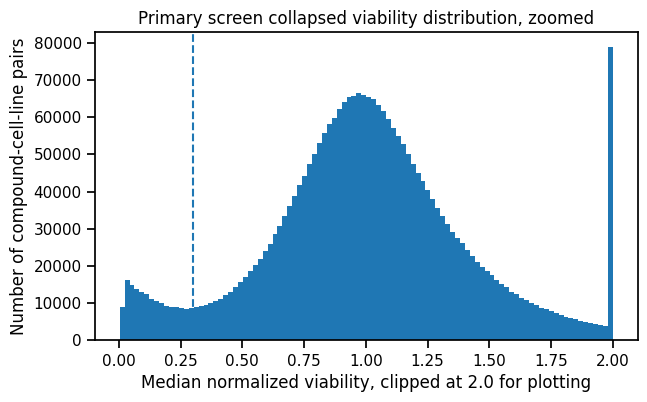

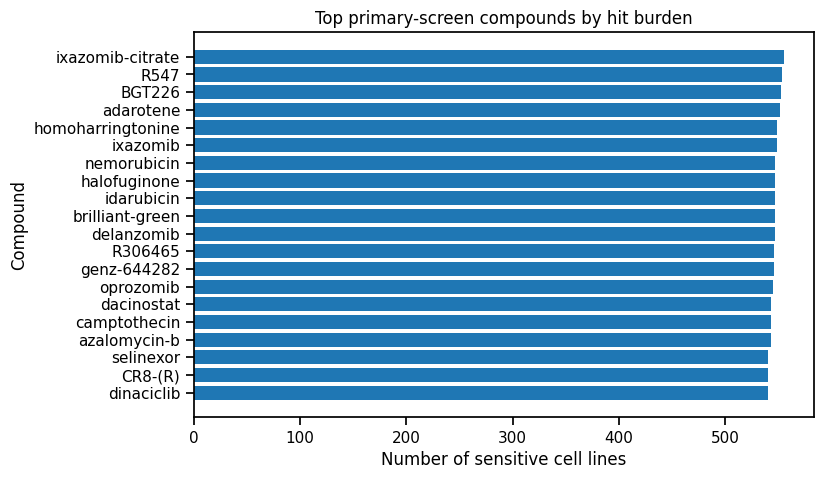

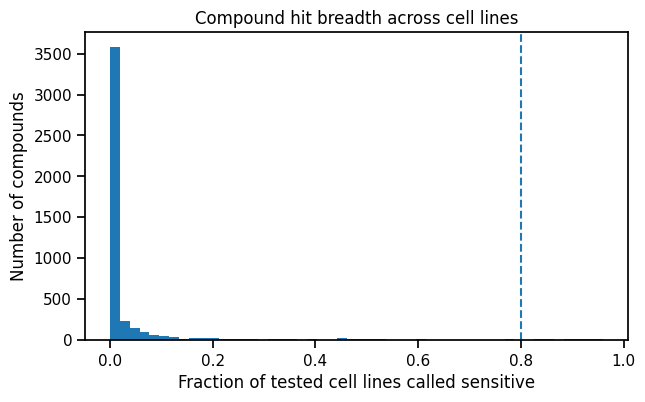

In [147]:
# Improved visual validation plots for paper-aligned primary hit calls

import matplotlib.pyplot as plt

# Zoomed distribution of collapsed median viability.
# Values above 2 are clipped only for plotting, not removed from analysis.
plt.figure(figsize=(7, 4))
plt.hist(
    primary_collapsed["median_viability"].dropna().clip(upper=2.0),
    bins=100
)
plt.axvline(PRIMARY_HIT_MEDIAN_VIABILITY_THRESHOLD, linestyle="--")
plt.xlabel("Median normalized viability, clipped at 2.0 for plotting")
plt.ylabel("Number of compound-cell-line pairs")
plt.title("Primary screen collapsed viability distribution, zoomed")
plt.show()

# Top compounds by number of sensitive cell lines.
top_compounds = compound_hit_summary.head(20).copy()

plt.figure(figsize=(8, 5))
plt.barh(
    top_compounds["name"].fillna(top_compounds["broad_id"]),
    top_compounds["n_sensitive_cell_lines"]
)
plt.gca().invert_yaxis()
plt.xlabel("Number of sensitive cell lines")
plt.ylabel("Compound")
plt.title("Top primary-screen compounds by hit burden")
plt.show()

# Broad cytotoxicity warning plot.
plt.figure(figsize=(7, 4))
plt.hist(
    compound_hit_summary["fraction_sensitive_cell_lines"].dropna(),
    bins=50
)
plt.axvline(0.80, linestyle="--")
plt.xlabel("Fraction of tested cell lines called sensitive")
plt.ylabel("Number of compounds")
plt.title("Compound hit breadth across cell lines")
plt.show()

### Section 2 interpretation: Primary normalization and hit calling

After plate-level normalization to vehicle controls, most compound–cell-line pairs had median viability near 1.0, consistent with limited growth inhibition for most treatments at the primary-screen dose. For hit calling, we used a paper-aligned sensitivity threshold: median normalized viability < 0.30.

The primary-hit rule also required replicate support: at least two nonmissing replicate wells and at least two replicate wells individually below the same viability threshold. This prevents a single extreme low measurement from creating a hit call.

The compound-level summary reports `n_sensitive_cell_lines`, the number of cell lines in which each compound passed the primary hit rule. Compounds with a large `n_sensitive_cell_lines` have broad activity across the cell-line panel; compounds with smaller but reproducible activity may represent more selective patterns.

Primary hit calling alone is not sufficient for repurposing prioritization. Broad activity can reflect true pharmacologic potency, general cytotoxicity, or assay-level effects. Later sections will distinguish broad cytotoxicity from selective killing and will prioritize compounds with reproducible, selective activity and interpretable biological context.

### Section 2 multiple-choice question

After normalizing the primary screen to plate-specific vehicle controls and applying the paper-aligned primary-hit rule, which interpretation best describes the primary-screen hit landscape?

A) The primary screen produced no usable hits because most normalized viability values were close to 1.0, indicating that the normalization removed all compound effects.

B) The primary hit rule identified reproducible compound–cell-line growth inhibition using a median viability threshold aligned to the paper, but compounds with the highest `n_sensitive_cell_lines` may represent broad activity rather than selective anticancer effects.

C) The compounds with the largest number of sensitive cell lines should automatically be prioritized as repurposing candidates because broad activity is always the strongest evidence for cancer-selective activity.

D) Single extreme low-viability wells are sufficient for primary hit calling because the primary screen was performed at only one dose.

**Correct answer: B**

**Rationale:** The hit rule uses replicate-collapsed viability and replicate support. `n_sensitive_cell_lines` counts how many cell lines pass that hit rule for each compound. A high value indicates broad activity, which is useful to record but not sufficient for selective repurposing prioritization. Selective activity and translational relevance require later dose-response confirmation, selectivity assessment, and molecular feature analysis.

## 3. Hit Triage: Selecting Compounds for Dose-Response Follow-Up

The primary hit-calling rule identifies compound–cell-line pairs with strong reproducible inhibition at the single 2.5 µM screening dose. For compound-level triage, we summarize each compound by the number and fraction of cell lines that were sensitive.

Here, `n_sensitive_cell_lines` means the number of cell lines in which a compound passed the primary hit rule. It measures the breadth of activity across the cancer cell-line panel.

The paper states that compounds were selected for secondary screening based on reproducibility, predictability, selectivity, and compound availability. The assignment asks us to define a transparent triage rule and compare it to the compounds actually advanced to the secondary screen.

### MVP compound-level triage rule

The primary hit rule operates at the compound–cell-line level. For compound-level triage, we summarize each compound by `n_sensitive_cell_lines`, the number of cell lines in which that compound produced reproducible median viability below 0.30.

Corsello et al. selected compounds for secondary screening using reproducibility, predictability, selectivity, and compound availability. We do not have a single published numeric rule that exactly reproduces that decision. Therefore, this notebook uses a transparent MVP triage heuristic: prioritize compounds with at least 3 sensitive cell lines, while excluding near-pan-active compounds that are sensitive in more than 80% of tested cell lines.

The `n_sensitive_cell_lines >= 3` threshold is not claimed to be the authors' rule. It is a conservative first-pass rule that avoids promoting compounds supported by only one or two sensitive cell lines. We will compare this MVP list to the actual secondary-screen compounds to evaluate agreement and disagreement.

In [148]:
# Section 3 consistency check

required_objects = [
    "primary_hit_table",
    "compound_hit_summary",
    "cell_line_sensitivity_summary",
    "primary_collapsed",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Missing required objects: "
        + ", ".join(missing_objects)
        + "\nPlease finish Section 2 hit calling before starting Section 3."
    )

print("All required Section 3 input objects are present.")

print("\nShapes:")
print("primary_hit_table:", primary_hit_table.shape)
print("compound_hit_summary:", compound_hit_summary.shape)
print("cell_line_sensitivity_summary:", cell_line_sensitivity_summary.shape)
print("primary_collapsed:", primary_collapsed.shape)

print("\nCompound hit summary columns:")
display(pd.Series(compound_hit_summary.columns.tolist(), name="columns"))

All required Section 3 input objects are present.

Shapes:
primary_hit_table: (161697, 25)
compound_hit_summary: (4686, 10)
cell_line_sensitivity_summary: (578, 5)
primary_collapsed: (2708508, 25)

Compound hit summary columns:


0                           broad_id
1                               name
2                               dose
3                n_cell_lines_tested
4             n_sensitive_cell_lines
5    median_viability_all_cell_lines
6               min_median_viability
7              mean_median_viability
8      fraction_sensitive_cell_lines
9             broad_activity_warning
Name: columns, dtype: str

In [149]:
# Recompute Section 3 primary triage after paper-aligned Section 2 hit update

primary_triage = compound_hit_summary.copy()

primary_triage["has_any_primary_activity"] = primary_triage["n_sensitive_cell_lines"] > 0

primary_triage["activity_category"] = pd.cut(
    primary_triage["fraction_sensitive_cell_lines"],
    bins=[-0.001, 0.0, 0.02, 0.20, 0.80, 1.0],
    labels=[
        "no_detected_activity",
        "rare_activity",
        "selective_or_moderate_activity",
        "broad_activity",
        "near_pan_active",
    ],
)

# Analyst-defined MVP triage heuristic, not the paper's exact selection rule.
MIN_SENSITIVE_CELL_LINES_FOR_TRIAGE = 3
MAX_FRACTION_SENSITIVE_FOR_SELECTIVE_TRIAGE = 0.80

primary_triage["mvp_triage_candidate"] = (
    (primary_triage["n_sensitive_cell_lines"] >= MIN_SENSITIVE_CELL_LINES_FOR_TRIAGE)
    & (
        primary_triage["fraction_sensitive_cell_lines"]
        <= MAX_FRACTION_SENSITIVE_FOR_SELECTIVE_TRIAGE
    )
)

print("Updated primary triage category counts:")
display(primary_triage["activity_category"].value_counts(dropna=False))

print("\nUpdated MVP triage candidate counts:")
display(primary_triage["mvp_triage_candidate"].value_counts(dropna=False))

print("\nUpdated triage candidates by activity category:")
display(
    primary_triage
    .groupby("activity_category", observed=False)
    .agg(
        n_compounds=("broad_id", "nunique"),
        n_mvp_triage_candidates=("mvp_triage_candidate", "sum"),
        median_sensitive_cell_lines=("n_sensitive_cell_lines", "median"),
        max_sensitive_cell_lines=("n_sensitive_cell_lines", "max"),
    )
    .reset_index()
)

print("\nTop updated MVP triage candidates:")
display(
    primary_triage
    .query("mvp_triage_candidate")
    [
        [
            "broad_id",
            "name",
            "dose",
            "n_cell_lines_tested",
            "n_sensitive_cell_lines",
            "fraction_sensitive_cell_lines",
            "median_viability_all_cell_lines",
            "min_median_viability",
            "activity_category",
            "broad_activity_warning",
            "mvp_triage_candidate",
        ]
    ]
    .sort_values(
        ["n_sensitive_cell_lines", "fraction_sensitive_cell_lines", "min_median_viability"],
        ascending=[False, False, True],
    )
    .head(30)
)

Updated primary triage category counts:


activity_category
no_detected_activity              1977
rare_activity                     1604
selective_or_moderate_activity     705
broad_activity                     311
near_pan_active                     89
Name: count, dtype: int64


Updated MVP triage candidate counts:


mvp_triage_candidate
False    2985
True     1701
Name: count, dtype: int64


Updated triage candidates by activity category:


,activity_category,n_compounds,n_mvp_triage_candidates,median_sensitive_cell_lines,max_sensitive_cell_lines
0,no_detected_activity,1977,0,0.0,0
1,rare_activity,1604,685,2.0,11
2,selective_or_moderate_activity,705,705,31.0,115
3,broad_activity,311,311,262.0,461
4,near_pan_active,89,0,519.0,555



Top updated MVP triage candidates:


,broad_id,name,dose,n_cell_lines_tested,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,activity_category,broad_activity_warning,mvp_triage_candidate
3094,BRD-K58435339-001-03-0,AT13387,2.500000,578,461,0.797578,0.106694,0.008483,broad_activity,False,True
1595,BRD-K18518344-001-15-9,digitoxigenin,2.500000,578,460,0.795848,0.133585,0.009170,broad_activity,False,True
4491,BRD-K95435023-001-08-5,PHA-665752,2.500000,578,459,0.794118,0.123126,0.006008,broad_activity,False,True
1389,BRD-K13167095-001-02-9,AR-42,2.500000,578,456,0.788927,0.099297,0.005476,broad_activity,False,True
3086,BRD-K58122457-001-02-2,hesperadin,2.500000,578,454,0.785467,0.149729,0.007195,broad_activity,False,True
1359,BRD-K12539581-001-23-7,nocodazole,2.500000,578,454,0.785467,0.129832,0.009038,broad_activity,False,True
3642,BRD-K72414522-001-06-7,AZD5438,2.500000,578,453,0.783737,0.134580,0.006814,broad_activity,False,True
2606,BRD-K45528773-001-07-2,M-344,2.590000,578,449,0.776817,0.111911,0.008488,broad_activity,False,True
1777,BRD-K23363278-001-02-1,CYT-997,2.500000,578,449,0.776817,0.122563,0.011783,broad_activity,False,True
3575,BRD-K70511574-001-06-9,HMN-214,2.500000,578,447,0.773356,0.131842,0.009619,broad_activity,False,True


In [150]:
# Validate Section 3 triage logic

print("Triage rule parameters:")
print(f"Minimum sensitive cell lines: {MIN_SENSITIVE_CELL_LINES_FOR_TRIAGE}")
print(f"Maximum fraction sensitive for selective MVP triage: {MAX_FRACTION_SENSITIVE_FOR_SELECTIVE_TRIAGE}")

print("\nSanity checks:")
print("Total compounds in primary_triage:", primary_triage.shape[0])
print("Unique broad_id values:", primary_triage["broad_id"].nunique())
print("Compounds with any primary activity:", primary_triage["has_any_primary_activity"].sum())
print("MVP triage candidates:", primary_triage["mvp_triage_candidate"].sum())

print("\nCheck no_detected_activity compounds:")
no_activity = primary_triage.query("activity_category == 'no_detected_activity'")
display(no_activity["n_sensitive_cell_lines"].describe())

print("\nCheck near_pan_active compounds:")
near_pan_active_cols = [
    "broad_id",
    "name",
    "n_sensitive_cell_lines",
    "fraction_sensitive_cell_lines",
    "mvp_triage_candidate",
]

near_pan_active = primary_triage.query("activity_category == 'near_pan_active'")

display(
    near_pan_active[near_pan_active_cols]
    .sort_values("fraction_sensitive_cell_lines", ascending=False)
    .head(10)
)

print("\nValidation expectations:")
print("no_detected_activity max n_sensitive_cell_lines:", no_activity["n_sensitive_cell_lines"].max())
print("near_pan_active MVP triage candidates:", near_pan_active["mvp_triage_candidate"].sum())

Triage rule parameters:
Minimum sensitive cell lines: 3
Maximum fraction sensitive for selective MVP triage: 0.8

Sanity checks:
Total compounds in primary_triage: 4686
Unique broad_id values: 4686
Compounds with any primary activity: 2709
MVP triage candidates: 1701

Check no_detected_activity compounds:


count    1977.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: n_sensitive_cell_lines, dtype: float64


Check near_pan_active compounds:


,broad_id,name,n_sensitive_cell_lines,fraction_sensitive_cell_lines,mvp_triage_candidate
641,BRD-A66419424-001-02-4,ixazomib-citrate,555,0.960208,False
2871,BRD-K52233191-001-02-4,R547,553,0.956747,False
2015,BRD-K29415052-050-04-8,BGT226,552,0.955017,False
919,BRD-K00152668-001-01-5,adarotene,551,0.953287,False
3795,BRD-K76674262-001-03-3,homoharringtonine,548,0.948097,False
3884,BRD-K78659596-001-03-9,ixazomib,548,0.948097,False
2859,BRD-K51911221-001-01-2,nemorubicin,547,0.946367,False
2947,BRD-K54247840-004-01-3,halofuginone,547,0.946367,False
3541,BRD-K69650333-003-14-0,idarubicin,547,0.946367,False
3182,BRD-K60348325-065-09-9,brilliant-green,547,0.946367,False



Validation expectations:
no_detected_activity max n_sensitive_cell_lines: 0
near_pan_active MVP triage candidates: 0


### Compare primary triage candidates to secondary-screen follow-up

The assignment asks whether our primary-screen triage criteria agree with the compounds that were actually advanced to the secondary dose-response screen. We will treat the secondary-screen treatment metadata as the follow-up set and compare compounds by `broad_id`.

This is a compound-level comparison, not a cell-line-level comparison.

In [151]:
# Inspect secondary treatment metadata safely

print("Secondary treatment metadata shape:")
print(secondary_treatment.shape)

print("\nSecondary treatment metadata columns:")
display(pd.Series(secondary_treatment.columns.tolist(), name="columns"))

print("\nPreview:")
display(secondary_treatment.head())

print("\nMissing values by column:")
display(secondary_treatment.isna().sum().sort_values(ascending=False))

print("\nDose values:")
display(secondary_treatment["dose"].value_counts(dropna=False).sort_index())

print("\nScreen IDs:")
display(secondary_treatment["screen_id"].value_counts(dropna=False))

print("\nUnique compound IDs:")
print(secondary_treatment["broad_id"].nunique())

print("\nUnique compound names:")
print(secondary_treatment["name"].nunique())

Secondary treatment metadata shape:
(13008, 12)

Secondary treatment metadata columns:


0        column_name
1           broad_id
2               dose
3          screen_id
4     compound_plate
5               name
6                moa
7             target
8       disease.area
9         indication
10            smiles
11             phase
Name: columns, dtype: str


Preview:


,column_name,broad_id,dose,screen_id,compound_plate,name,moa,target,disease.area,indication,smiles,phase
0,BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00061,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
1,BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00244,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
2,BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00977,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
3,BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...,BRD-A25234499-001-19-1,0.03910,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
4,BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...,BRD-A25234499-001-19-1,0.15625,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched



Missing values by column:


...


Dose values:


dose
0.000010      2
0.000038      9
0.000152      2
0.000153      1
0.000153     11
             ..
10.716400     1
10.725800     1
10.760400     1
11.199800     1
12.655000     1
Name: count, Length: 1058, dtype: int64


Screen IDs:


screen_id
HTS002    11168
MTS010     1240
MTS006      584
MTS005       16
Name: count, dtype: int64


Unique compound IDs:
1502

Unique compound names:
1448


In [152]:
# Identify compounds advanced to the secondary dose-response screen

secondary_experimental_metadata = secondary_treatment.copy()

# Keep rows with a real compound ID.
secondary_experimental_metadata = secondary_experimental_metadata[
    secondary_experimental_metadata["broad_id"].notna()
].copy()

# Ensure dose is numeric.
secondary_experimental_metadata["dose"] = pd.to_numeric(
    secondary_experimental_metadata["dose"],
    errors="coerce"
)

# Keep positive-dose rows.
secondary_experimental_metadata = secondary_experimental_metadata[
    secondary_experimental_metadata["dose"].notna()
    & (secondary_experimental_metadata["dose"] > 0)
].copy()

secondary_compounds_by_broad_id = (
    secondary_experimental_metadata[
        ["broad_id", "name", "moa", "target", "disease.area", "indication", "phase"]
    ]
    .drop_duplicates(subset=["broad_id"])
    .sort_values("broad_id")
    .reset_index(drop=True)
)

secondary_compounds_by_name = (
    secondary_experimental_metadata[
        ["name", "moa", "target", "disease.area", "indication", "phase"]
    ]
    .drop_duplicates(subset=["name"])
    .sort_values("name")
    .reset_index(drop=True)
)

print("Secondary experimental-treatment metadata shape:")
print(secondary_experimental_metadata.shape)

print("\nUnique secondary compounds by broad_id:")
print(secondary_compounds_by_broad_id["broad_id"].nunique())

print("\nUnique secondary compounds by name:")
print(secondary_compounds_by_name["name"].nunique())

print("\nSecondary dose summary:")
display(secondary_experimental_metadata["dose"].describe())

print("\nNumber of dose rows per secondary broad_id:")
display(
    secondary_experimental_metadata
    .groupby("broad_id")
    .size()
    .value_counts()
    .sort_index()
)

print("\nPreview of secondary compounds by broad_id:")
display(secondary_compounds_by_broad_id.head(20))

Secondary experimental-treatment metadata shape:
(13008, 12)

Unique secondary compounds by broad_id:
1502

Unique secondary compounds by name:
1448

Secondary dose summary:


count    13008.000000
mean         1.649888
std          3.233420
min          0.000010
25%          0.002532
50%          0.040508
75%          0.648780
max         12.655000
Name: dose, dtype: float64


Number of dose rows per secondary broad_id:


8     1385
16     114
24       1
40       2
Name: count, dtype: int64


Preview of secondary compounds by broad_id:


,broad_id,name,moa,target,disease.area,indication,phase
0,BRD-A00077618-236-07-6,8-bromo-cGMP,PKA activator,PRKG1,NaN,NaN,Preclinical
1,BRD-A00758722-001-04-9,noretynodrel,progestogen hormone,PGR,endocrinology,contraceptive,Launched
2,BRD-A01643550-001-04-9,prednisolone-acetate,glucocorticoid receptor agonist,NR3C1,"ophthalmology, dermatology, infectious disease","conjunctivitis, rosacea, punctate keratitis, s...",Launched
3,BRD-A02180903-001-04-5,betamethasone,glucocorticoid receptor agonist,NR3C1,dermatology,corticosteroid-responsive dermatoses,Launched
4,BRD-A03216249-003-24-3,mepivacaine,"potassium channel blocker, sodium channel blocker",SCN10A,neurology/psychiatry,local anesthetic,Launched
5,BRD-A03506276-001-01-5,XL888,HSP inhibitor,NaN,NaN,NaN,Phase 1
6,BRD-A03623303-045-09-5,metoprolol,adrenergic receptor antagonist,"ADRB1, ADRB2",cardiology,"hypertension, angina pectoris, myocardial infa...",Launched
7,BRD-A03932035-004-04-3,methscopolamine,acetylcholine receptor antagonist,"CHRM1, CHRM2, CHRM3",gastroenterology,peptic ulcer disease (PUD),Launched
8,BRD-A05906449-004-01-1,lappaconite,sodium channel blocker,NaN,NaN,NaN,Phase 2
9,BRD-A06352418-001-25-9,terfenadine,histamine receptor antagonist,"CHRM1, CHRM2, CHRM3, CHRM4, CHRM5, HRH1, KCNH1...",NaN,NaN,Withdrawn


In [153]:
# Compare MVP primary triage candidates to compounds actually present in the secondary screen

secondary_broad_ids = set(secondary_compounds_by_broad_id["broad_id"])

primary_triage_comparison = primary_triage.copy()

primary_triage_comparison["advanced_to_secondary"] = (
    primary_triage_comparison["broad_id"].isin(secondary_broad_ids)
)

primary_triage_comparison["triage_vs_secondary_status"] = np.select(
    [
        primary_triage_comparison["mvp_triage_candidate"] & primary_triage_comparison["advanced_to_secondary"],
        primary_triage_comparison["mvp_triage_candidate"] & ~primary_triage_comparison["advanced_to_secondary"],
        ~primary_triage_comparison["mvp_triage_candidate"] & primary_triage_comparison["advanced_to_secondary"],
        ~primary_triage_comparison["mvp_triage_candidate"] & ~primary_triage_comparison["advanced_to_secondary"],
    ],
    [
        "selected_by_mvp_and_secondary",
        "selected_by_mvp_only",
        "selected_by_secondary_only",
        "selected_by_neither",
    ],
    default="unknown",
)

print("Primary-vs-secondary comparison counts:")
display(primary_triage_comparison["triage_vs_secondary_status"].value_counts(dropna=False))

print("\nConfusion-style table:")
display(
    pd.crosstab(
        primary_triage_comparison["mvp_triage_candidate"],
        primary_triage_comparison["advanced_to_secondary"],
        rownames=["MVP triage candidate"],
        colnames=["Advanced to secondary"],
    )
)

print("\nFraction of MVP triage candidates advanced to secondary:")
mvp_candidates = primary_triage_comparison["mvp_triage_candidate"]
print(primary_triage_comparison.loc[mvp_candidates, "advanced_to_secondary"].mean())

print("\nFraction of secondary broad_id compounds captured by MVP triage:")
secondary_selected = primary_triage_comparison["advanced_to_secondary"]
print(primary_triage_comparison.loc[secondary_selected, "mvp_triage_candidate"].mean())

print("\nMVP candidates not found in secondary:")
display(
    primary_triage_comparison
    .query("triage_vs_secondary_status == 'selected_by_mvp_only'")
    [
        [
            "broad_id",
            "name",
            "n_sensitive_cell_lines",
            "fraction_sensitive_cell_lines",
            "median_viability_all_cell_lines",
            "min_median_viability",
            "activity_category",
            "broad_activity_warning",
        ]
    ]
    .sort_values(
        ["n_sensitive_cell_lines", "fraction_sensitive_cell_lines", "min_median_viability"],
        ascending=[False, False, True],
    )
    .head(20)
)

print("\nSecondary compounds not selected by MVP:")
display(
    primary_triage_comparison
    .query("triage_vs_secondary_status == 'selected_by_secondary_only'")
    [
        [
            "broad_id",
            "name",
            "n_sensitive_cell_lines",
            "fraction_sensitive_cell_lines",
            "median_viability_all_cell_lines",
            "min_median_viability",
            "activity_category",
            "broad_activity_warning",
        ]
    ]
    .sort_values(
        ["n_sensitive_cell_lines", "fraction_sensitive_cell_lines", "min_median_viability"],
        ascending=[False, False, True],
    )
    .head(20)
)

Primary-vs-secondary comparison counts:


triage_vs_secondary_status
selected_by_neither              2698
selected_by_mvp_and_secondary    1162
selected_by_mvp_only              539
selected_by_secondary_only        287
Name: count, dtype: int64


Confusion-style table:


Advanced to secondary,False,True
MVP triage candidate,,
False,2698,287
True,539,1162



Fraction of MVP triage candidates advanced to secondary:
0.6831275720164609

Fraction of secondary broad_id compounds captured by MVP triage:
0.8019323671497585

MVP candidates not found in secondary:


,broad_id,name,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,activity_category,broad_activity_warning
3024,BRD-K56211775-001-03-8,RTA-408,442,0.764706,0.163031,0.022205,broad_activity,False
1916,BRD-K26818574-305-07-6,BIX-01294,434,0.750865,0.166015,0.027637,broad_activity,False
1745,BRD-K22149900-001-03-9,ceritinib,434,0.750865,0.172058,0.040941,broad_activity,False
3540,BRD-K69650333-003-13-2,idarubicin,416,0.719723,0.172200,0.004572,broad_activity,False
4657,BRD-K99919177-001-01-3,deslanoside,410,0.709343,0.179645,0.033584,broad_activity,False
1270,BRD-K10362825-001-03-4,teniposide,375,0.648789,0.170357,0.008910,broad_activity,False
4188,BRD-K86797399-001-04-4,SB-939,373,0.645329,0.191383,0.014410,broad_activity,False
4182,BRD-K86525559-001-04-5,AZD7762,345,0.596886,0.217267,0.010890,broad_activity,False
2605,BRD-K45528773-001-06-4,M-344,300,0.519031,0.273357,0.010264,broad_activity,False
3485,BRD-K68346641-001-02-2,amsacrine,272,0.470588,0.327627,0.007533,broad_activity,False



Secondary compounds not selected by MVP:


,broad_id,name,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,activity_category,broad_activity_warning
641,BRD-A66419424-001-02-4,ixazomib-citrate,555,0.960208,0.059170,0.006633,near_pan_active,True
2871,BRD-K52233191-001-02-4,R547,553,0.956747,0.071660,0.005281,near_pan_active,True
2015,BRD-K29415052-050-04-8,BGT226,552,0.955017,0.064345,0.007038,near_pan_active,True
919,BRD-K00152668-001-01-5,adarotene,551,0.953287,0.076748,0.007341,near_pan_active,True
3795,BRD-K76674262-001-03-3,homoharringtonine,548,0.948097,0.060374,0.003471,near_pan_active,True
3884,BRD-K78659596-001-03-9,ixazomib,548,0.948097,0.054256,0.006649,near_pan_active,True
2859,BRD-K51911221-001-01-2,nemorubicin,547,0.946367,0.055606,0.003454,near_pan_active,True
2947,BRD-K54247840-004-01-3,halofuginone,547,0.946367,0.063001,0.004697,near_pan_active,True
3541,BRD-K69650333-003-14-0,idarubicin,547,0.946367,0.060907,0.005220,near_pan_active,True
3182,BRD-K60348325-065-09-9,brilliant-green,547,0.946367,0.065494,0.007345,near_pan_active,True


### Section 3 interpretation: Hit triage and comparison to secondary follow-up

Using the paper-aligned primary hit definition, 2,709 of 4,686 primary-screen compounds had at least one sensitive cell line. For MVP compound-level triage, we prioritized compounds with at least 3 sensitive cell lines while excluding near-pan-active compounds that were sensitive in more than 80% of tested cell lines.

This produced 1,701 MVP triage candidates. When compared with compounds present in the secondary dose-response metadata, 1,162 compounds were selected by both the MVP triage rule and the actual secondary screen. The MVP rule captured approximately 80.2% of secondary-screen compounds that overlapped the primary-screen Broad IDs.

The disagreement cases are informative. Some compounds selected by MVP but not found in secondary showed broad or moderate activity in the primary screen, suggesting that additional factors such as compound availability, replicate reproducibility, assay quality, or compound identity may have affected the authors' actual selection. Conversely, some compounds present in the secondary screen but not selected by the MVP rule were near-pan-active compounds, which this notebook intentionally excludes from the selective MVP triage list. These are not inactive compounds; they are highly active but less selective.

Overall, the MVP triage rule gives a transparent and defensible approximation of secondary follow-up selection, but it does not fully reproduce the authors' process. This is expected because the published selection considered reproducibility, predictability, selectivity, and compound availability, whereas this MVP rule uses only primary-screen activity breadth and a broad-activity exclusion.

### Section 3 multiple-choice question

After comparing the MVP primary-screen triage candidates to the compounds actually present in the secondary dose-response screen, which interpretation is most appropriate?

A) The MVP triage rule failed because it did not exactly reproduce the secondary-screen compound list.

B) The MVP triage rule captured most secondary-screen compounds, but disagreement cases show that secondary follow-up depended on additional factors beyond simple primary activity breadth, including broad cytotoxicity, reproducibility, predictability, selectivity, and compound availability.

C) All compounds active in more than 80% of cell lines should be prioritized first because broad activity is the strongest evidence of selective anticancer potential.

D) Compounds with no detected primary activity should be advanced to secondary screening because the primary screen is only a single-dose assay.

**Correct answer: B**

**Rationale:** The MVP rule captured a large fraction of the secondary-screen compounds, showing that primary activity was informative. However, the rule did not exactly match the secondary screen. Some secondary compounds were near-pan-active and were intentionally excluded from the selective MVP triage list, while some MVP candidates were not present in secondary metadata. This indicates that actual follow-up selection included additional practical and biological criteria beyond this simple MVP heuristic.

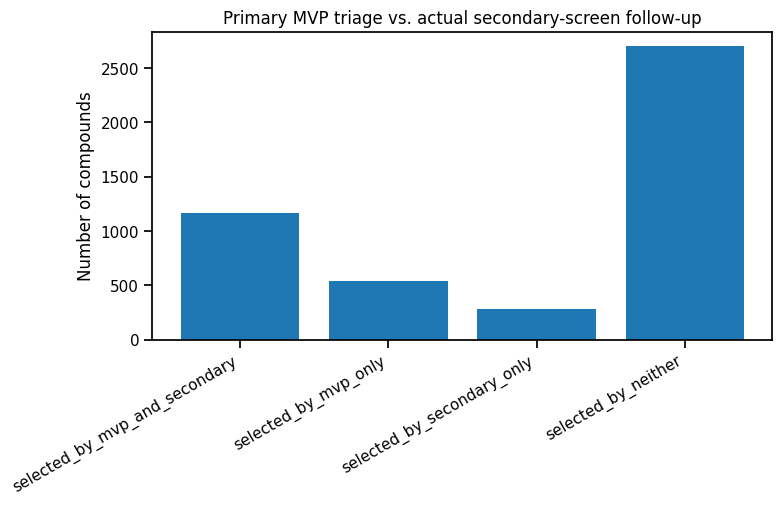

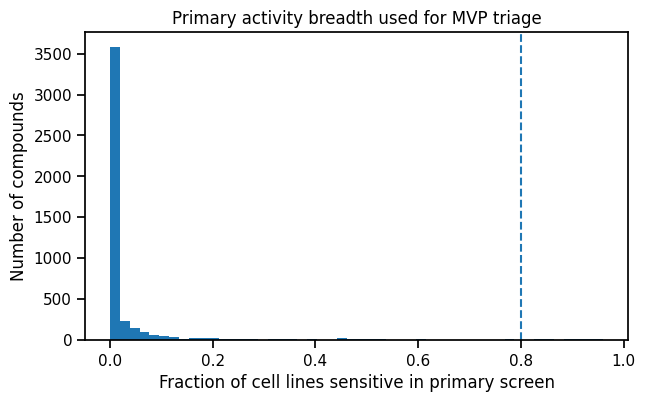

In [154]:
# Visualize Section 3 primary-vs-secondary comparison

import matplotlib.pyplot as plt

comparison_counts = (
    primary_triage_comparison["triage_vs_secondary_status"]
    .value_counts()
    .reindex(
        [
            "selected_by_mvp_and_secondary",
            "selected_by_mvp_only",
            "selected_by_secondary_only",
            "selected_by_neither",
        ]
    )
)

plt.figure(figsize=(8, 4))
plt.bar(comparison_counts.index, comparison_counts.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of compounds")
plt.title("Primary MVP triage vs. actual secondary-screen follow-up")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(
    primary_triage_comparison["fraction_sensitive_cell_lines"].dropna(),
    bins=50
)
plt.axvline(0.80, linestyle="--")
plt.xlabel("Fraction of cell lines sensitive in primary screen")
plt.ylabel("Number of compounds")
plt.title("Primary activity breadth used for MVP triage")
plt.show()

## 4. Secondary Screen QC, Normalization & Batch Correction

The secondary screen is an independent dose-response experiment. We will therefore load and validate it separately from the primary screen.

In this first Section 4 step, we will:

- load secondary MFI, treatment metadata, cell-line metadata, and pooling metadata,
- inspect schemas and dimensions,
- confirm that secondary MFI well columns match treatment metadata,
- identify real cell-line rows versus control/spike-in barcode rows,
- check missing and nonpositive MFI values.

We will not normalize or batch-correct yet.

In [155]:
# Section 4: load secondary screen raw files

from pathlib import Path
import pandas as pd
import numpy as np

raw_dir_candidates = [
    Path("data/raw"),
    Path("../data/raw"),
    Path("data/raw/corsello_prism_txbench"),
    Path("../data/raw/corsello_prism_txbench"),
]

required_secondary_files = {
    "secondary_mfi": "secondary-screen-mfi.csv",
    "secondary_treatment": "secondary-screen-replicate-treatment-info.csv",
    "secondary_cell_line_info": "secondary-screen-cell-line-info.csv",
    "secondary_pooling_info": "secondary-screen-pooling-info.csv",
}

raw_dir = None

for candidate_dir in raw_dir_candidates:
    if all((candidate_dir / filename).exists() for filename in required_secondary_files.values()):
        raw_dir = candidate_dir
        break

if raw_dir is None:
    raise FileNotFoundError(
        "Could not find all required secondary-screen files in expected raw-data folders. "
        "Please check the data/raw path."
    )

print("Using raw data directory:")
print(raw_dir)

secondary_mfi = pd.read_csv(raw_dir / required_secondary_files["secondary_mfi"])
secondary_treatment = pd.read_csv(raw_dir / required_secondary_files["secondary_treatment"])
secondary_cell_line_info = pd.read_csv(raw_dir / required_secondary_files["secondary_cell_line_info"])
secondary_pooling_info = pd.read_csv(raw_dir / required_secondary_files["secondary_pooling_info"])

print("\nLoaded secondary files:")
print("secondary_mfi:", secondary_mfi.shape)
print("secondary_treatment:", secondary_treatment.shape)
print("secondary_cell_line_info:", secondary_cell_line_info.shape)
print("secondary_pooling_info:", secondary_pooling_info.shape)

Using raw data directory:
..\data\raw

Loaded secondary files:
secondary_mfi: (499, 48968)
secondary_treatment: (13008, 12)
secondary_cell_line_info: (588, 7)
secondary_pooling_info: (3135, 9)


In [156]:
# Inspect secondary schemas

print("secondary_mfi columns:")
display(pd.Series(secondary_mfi.columns.tolist(), name="columns"))

print("\nsecondary_treatment columns:")
display(pd.Series(secondary_treatment.columns.tolist(), name="columns"))

print("\nsecondary_cell_line_info columns:")
display(pd.Series(secondary_cell_line_info.columns.tolist(), name="columns"))

print("\nsecondary_pooling_info columns:")
display(pd.Series(secondary_pooling_info.columns.tolist(), name="columns"))

print("\nSecondary treatment preview:")
display(secondary_treatment.head())

print("\nSecondary MFI preview:")
display(secondary_mfi.head())

secondary_mfi columns:


0                                  Unnamed: 0
1              PMTS004_PR500.2_X1:A01::MTS005
2              PMTS004_PR500.2_X1:A02::MTS005
3              PMTS004_PR500.2_X1:A23::MTS005
4              PMTS004_PR500.2_X1:A24::MTS005
                         ...                 
48963    PROS005_PR500_120H_X3_P4:P20::MTS010
48964    PROS005_PR500_120H_X3_P4:P21::MTS010
48965    PROS005_PR500_120H_X3_P4:P22::MTS010
48966    PROS005_PR500_120H_X3_P4:P23::MTS010
48967    PROS005_PR500_120H_X3_P4:P24::MTS010
Name: columns, Length: 48968, dtype: str


secondary_treatment columns:


0        column_name
1           broad_id
2               dose
3          screen_id
4     compound_plate
5               name
6                moa
7             target
8       disease.area
9         indication
10            smiles
11             phase
Name: columns, dtype: str


secondary_cell_line_info columns:


...

0                row_name
1               depmap_id
2    passed_str_profiling
3               ccle_name
4               screen_id
5              analyte_id
6          detection_pool
7             minipool_id
8                 pool_id
Name: columns, dtype: str


Secondary treatment preview:


,column_name,broad_id,dose,screen_id,compound_plate,name,moa,target,disease.area,indication,smiles,phase
0,BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00061,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
1,BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00244,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
2,BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...,BRD-A25234499-001-19-1,0.00977,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
3,BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...,BRD-A25234499-001-19-1,0.03910,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched
4,BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...,BRD-A25234499-001-19-1,0.15625,MTS010,PROS003_PR500,aminoglutethimide,glucocorticoid receptor antagonist,"CYP11A1, CYP19A1","endocrinology, oncology","Cushing's syndrome, breast cancer","CCC1(CCC(=O)NC1=O)c1ccc(N)cc1, CCC1(CCC(=O)NC1...",Launched



Secondary MFI preview:


,Unnamed: 0,PMTS004_PR500.2_X1:A01::MTS005,PMTS004_PR500.2_X1:A02::MTS005,PMTS004_PR500.2_X1:A23::MTS005,PMTS004_PR500.2_X1:A24::MTS005,PMTS004_PR500.2_X1:B01::MTS005,PMTS004_PR500.2_X1:B02::MTS005,PMTS004_PR500.2_X1:B23::MTS005,PMTS004_PR500.2_X1:B24::MTS005,PMTS004_PR500.2_X1:C01::MTS005,PMTS004_PR500.2_X1:C02::MTS005,PMTS004_PR500.2_X1:C23::MTS005,PMTS004_PR500.2_X1:C24::MTS005,PMTS004_PR500.2_X1:D01::MTS005,PMTS004_PR500.2_X1:D02::MTS005,PMTS004_PR500.2_X1:D23::MTS005,PMTS004_PR500.2_X1:D24::MTS005,PMTS004_PR500.2_X1:E01::MTS005,PMTS004_PR500.2_X1:E02::MTS005,PMTS004_PR500.2_X1:E23::MTS005,PMTS004_PR500.2_X1:E24::MTS005,PMTS004_PR500.2_X1:F01::MTS005,PMTS004_PR500.2_X1:F02::MTS005,PMTS004_PR500.2_X1:F23::MTS005,PMTS004_PR500.2_X1:F24::MTS005,PMTS004_PR500.2_X1:G01::MTS005,PMTS004_PR500.2_X1:G02::MTS005,PMTS004_PR500.2_X1:G23::MTS005,PMTS004_PR500.2_X1:G24::MTS005,PMTS004_PR500.2_X1:H01::MTS005,PMTS004_PR500.2_X1:H02::MTS005,PMTS004_PR500.2_X1:H23::MTS005,PMTS004_PR500.2_X1:H24::MTS005,PMTS004_PR500.2_X1:I01::MTS005,PMTS004_PR500.2_X1:I02::MTS005,PMTS004_PR500.2_X1:I23::MTS005,PMTS004_PR500.2_X1:I24::MTS005,PMTS004_PR500.2_X1:J01::MTS005,PMTS004_PR500.2_X1:J02::MTS005,PMTS004_PR500.2_X1:J23::MTS005,PMTS004_PR500.2_X1:J24::MTS005,PMTS004_PR500.2_X1:K01::MTS005,PMTS004_PR500.2_X1:K02::MTS005,PMTS004_PR500.2_X1:K23::MTS005,PMTS004_PR500.2_X1:K24::MTS005,PMTS004_PR500.2_X1:L01::MTS005,PMTS004_PR500.2_X1:L02::MTS005,PMTS004_PR500.2_X1:L23::MTS005,PMTS004_PR500.2_X1:L24::MTS005,PMTS004_PR500.2_X1:M01::MTS005,...,PROS005_PR500_120H_X3_P4:M20::MTS010,PROS005_PR500_120H_X3_P4:M21::MTS010,PROS005_PR500_120H_X3_P4:M22::MTS010,PROS005_PR500_120H_X3_P4:M24::MTS010,PROS005_PR500_120H_X3_P4:N01::MTS010,PROS005_PR500_120H_X3_P4:N02::MTS010,PROS005_PR500_120H_X3_P4:N04::MTS010,PROS005_PR500_120H_X3_P4:N05::MTS010,PROS005_PR500_120H_X3_P4:N07::MTS010,PROS005_PR500_120H_X3_P4:N08::MTS010,PROS005_PR500_120H_X3_P4:N09::MTS010,PROS005_PR500_120H_X3_P4:N14::MTS010,PROS005_PR500_120H_X3_P4:N15::MTS010,PROS005_PR500_120H_X3_P4:N16::MTS010,PROS005_PR500_120H_X3_P4:N18::MTS010,PROS005_PR500_120H_X3_P4:N19::MTS010,PROS005_PR500_120H_X3_P4:N20::MTS010,PROS005_PR500_120H_X3_P4:N22::MTS010,PROS005_PR500_120H_X3_P4:N23::MTS010,PROS005_PR500_120H_X3_P4:N24::MTS010,PROS005_PR500_120H_X3_P4:O01::MTS010,PROS005_PR500_120H_X3_P4:O02::MTS010,PROS005_PR500_120H_X3_P4:O03::MTS010,PROS005_PR500_120H_X3_P4:O09::MTS010,PROS005_PR500_120H_X3_P4:O11::MTS010,PROS005_PR500_120H_X3_P4:O12::MTS010,PROS005_PR500_120H_X3_P4:O13::MTS010,PROS005_PR500_120H_X3_P4:O15::MTS010,PROS005_PR500_120H_X3_P4:O16::MTS010,PROS005_PR500_120H_X3_P4:O17::MTS010,PROS005_PR500_120H_X3_P4:O18::MTS010,PROS005_PR500_120H_X3_P4:O21::MTS010,PROS005_PR500_120H_X3_P4:O22::MTS010,PROS005_PR500_120H_X3_P4:O23::MTS010,PROS005_PR500_120H_X3_P4:O24::MTS010,PROS005_PR500_120H_X3_P4:P01::MTS010,PROS005_PR500_120H_X3_P4:P02::MTS010,PROS005_PR500_120H_X3_P4:P05::MTS010,PROS005_PR500_120H_X3_P4:P06::MTS010,PROS005_PR500_120H_X3_P4:P07::MTS010,PROS005_PR500_120H_X3_P4:P11::MTS010,PROS005_PR500_120H_X3_P4:P12::MTS010,PROS005_PR500_120H_X3_P4:P13::MTS010,PROS005_PR500_120H_X3_P4:P14::MTS010,PROS005_PR500_120H_X3_P4:P17::MTS010,PROS005_PR500_120H_X3_P4:P20::MTS010,PROS005_PR500_120H_X3_P4:P21::MTS010,PROS005_PR500_120H_X3_P4:P22::MTS010,PROS005_PR500_120H_X3_P4:P23::MTS010,PROS005_PR500_120H_X3_P4:P24::MTS010
0,ACH-000007,265.5,5508.0,570.0,385.0,195.0,8060.5,4038.0,249.0,305.0,9188.0,13120.0,339.0,870.0,7295.0,13692.0,125.0,6716.0,4677.0,8626.0,9227.0,5048.0,11706.0,10098.0,8965.5,194.0,4160.5,8455.0,108.0,1080.5,10967.0,2798.0,250.5,223.5,7332.0,7577.5,1027.0,103.5,11728.0,3868.0,1571.0,2238.5,9034.0,5802.0,1344.0,803.0,8505.0,2714.0,539.5,222.5,...,2748.0,3164.0,1348.0,639.0,1346.5,1068.0,4111.0,864.5,2379.0,1723.0,735.0,672.0,444.0,1696.0,1475.0,834.0,6800.5,794.0,824.0,1753.0,1322.0,733.0,1128.0,1427.0,1407.5,735.5,1711.0,1709.0,1323.0,1393.0,1644.0,680.5,591.0,499.5,1341.0,939.0,3079.0,881.5,2363.0,930.0,42

In [157]:
# Diagnose secondary MFI column-name mismatch

secondary_row_id_col = secondary_mfi.columns[0]
secondary_mfi_well_columns = secondary_mfi.columns[1:].tolist()

secondary_metadata_columns = secondary_treatment["column_name"].tolist()

mfi_set = set(secondary_mfi_well_columns)
metadata_set = set(secondary_metadata_columns)

missing_from_metadata = sorted(mfi_set - metadata_set)
missing_from_mfi = sorted(metadata_set - mfi_set)

print("Secondary MFI row identifier column:")
print(secondary_row_id_col)

print("\nSecondary MFI shape:")
print(secondary_mfi.shape)

print("\nNumber of secondary MFI well columns:")
print(len(secondary_mfi_well_columns))

print("\nNumber of secondary treatment metadata rows:")
print(secondary_treatment.shape[0])

print("\nUnique MFI well columns:")
print(len(mfi_set))

print("\nUnique metadata column_name values:")
print(len(metadata_set))

print("\nMFI columns missing from treatment metadata:")
print(len(missing_from_metadata))

print("\nTreatment metadata column_name values missing from MFI:")
print(len(missing_from_mfi))

print("\nMFI well columns already in same order as metadata rows?")
print(secondary_mfi_well_columns == secondary_metadata_columns)

print("\nFirst 10 MFI well columns:")
display(pd.Series(secondary_mfi_well_columns[:10], name="mfi_columns"))

print("\nFirst 10 treatment metadata column_name values:")
display(pd.Series(secondary_metadata_columns[:10], name="metadata_column_name"))

print("\nFirst 10 MFI columns missing from metadata:")
display(pd.Series(missing_from_metadata[:10], name="missing_from_metadata"))

print("\nFirst 10 metadata column_name values missing from MFI:")
display(pd.Series(missing_from_mfi[:10], name="missing_from_mfi"))

Secondary MFI row identifier column:
Unnamed: 0

Secondary MFI shape:
(499, 48968)

Number of secondary MFI well columns:
48967

Number of secondary treatment metadata rows:
13008

Unique MFI well columns:
48967

Unique metadata column_name values:
13008

MFI columns missing from treatment metadata:
48967

Treatment metadata column_name values missing from MFI:
13008

MFI well columns already in same order as metadata rows?
False

First 10 MFI well columns:


0    PMTS004_PR500.2_X1:A01::MTS005
1    PMTS004_PR500.2_X1:A02::MTS005
2    PMTS004_PR500.2_X1:A23::MTS005
3    PMTS004_PR500.2_X1:A24::MTS005
4    PMTS004_PR500.2_X1:B01::MTS005
5    PMTS004_PR500.2_X1:B02::MTS005
6    PMTS004_PR500.2_X1:B23::MTS005
7    PMTS004_PR500.2_X1:B24::MTS005
8    PMTS004_PR500.2_X1:C01::MTS005
9    PMTS004_PR500.2_X1:C02::MTS005
Name: mfi_columns, dtype: str


First 10 treatment metadata column_name values:


0    BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...
1    BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...
2    BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...
3    BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...
4    BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...
5    BRD-A25234499-001-19-1::0.625::MTS010::PROS003...
6    BRD-A25234499-001-19-1::10::MTS010::PROS003_PR500
7    BRD-A25234499-001-19-1::2.5::MTS010::PROS003_P...
8    BRD-A70858459-001-01-7::0.00061::MTS010::PROS0...
9    BRD-A70858459-001-01-7::0.00244::MTS010::PROS0...
Name: metadata_column_name, dtype: str


First 10 MFI columns missing from metadata:


0    PMTS004_PR500.2_X1:A01::MTS005
1    PMTS004_PR500.2_X1:A02::MTS005
2    PMTS004_PR500.2_X1:A23::MTS005
3    PMTS004_PR500.2_X1:A24::MTS005
4    PMTS004_PR500.2_X1:B01::MTS005
5    PMTS004_PR500.2_X1:B02::MTS005
6    PMTS004_PR500.2_X1:B23::MTS005
7    PMTS004_PR500.2_X1:B24::MTS005
8    PMTS004_PR500.2_X1:C01::MTS005
9    PMTS004_PR500.2_X1:C02::MTS005
Name: missing_from_metadata, dtype: str


First 10 metadata column_name values missing from MFI:


0    BRD-A00077618-236-07-6::0.00061034::HTS002
1     BRD-A00077618-236-07-6::0.0024414::HTS002
2    BRD-A00077618-236-07-6::0.00976562::HTS002
3     BRD-A00077618-236-07-6::0.0390625::HTS002
4       BRD-A00077618-236-07-6::0.15625::HTS002
5         BRD-A00077618-236-07-6::0.625::HTS002
6            BRD-A00077618-236-07-6::10::HTS002
7           BRD-A00077618-236-07-6::2.5::HTS002
8    BRD-A00758722-001-04-9::0.00061034::HTS002
9     BRD-A00758722-001-04-9::0.0024414::HTS002
Name: missing_from_mfi, dtype: str

In [158]:
# Diagnose secondary MFI column formats without assuming exact number of parts

secondary_row_id_col = secondary_mfi.columns[0]
secondary_mfi_well_columns = secondary_mfi.columns[1:].tolist()

secondary_mfi_col_parts = (
    pd.Series(secondary_mfi_well_columns, name="mfi_column")
    .str.split("::", expand=True)
)

print("Parsed MFI column parts shape:")
print(secondary_mfi_col_parts.shape)

print("\nNumber of parsed parts per MFI column:")
n_parts_per_col = pd.Series(secondary_mfi_well_columns).str.count("::") + 1
display(n_parts_per_col.value_counts().sort_index())

print("\nExamples by number of parsed parts:")
for n_parts in sorted(n_parts_per_col.unique()):
    print(f"\n--- Columns with {n_parts} parts ---")
    example_cols = pd.Series(secondary_mfi_well_columns)[n_parts_per_col == n_parts].head(10)
    display(example_cols.reset_index(drop=True))

print("\nParsed preview:")
display(secondary_mfi_col_parts.head(20))

Parsed MFI column parts shape:
(48967, 2)

Number of parsed parts per MFI column:


2    48967
Name: count, dtype: int64


Examples by number of parsed parts:

--- Columns with 2 parts ---


0    PMTS004_PR500.2_X1:A01::MTS005
1    PMTS004_PR500.2_X1:A02::MTS005
2    PMTS004_PR500.2_X1:A23::MTS005
3    PMTS004_PR500.2_X1:A24::MTS005
4    PMTS004_PR500.2_X1:B01::MTS005
5    PMTS004_PR500.2_X1:B02::MTS005
6    PMTS004_PR500.2_X1:B23::MTS005
7    PMTS004_PR500.2_X1:B24::MTS005
8    PMTS004_PR500.2_X1:C01::MTS005
9    PMTS004_PR500.2_X1:C02::MTS005
dtype: str


Parsed preview:


,0,1
0,PMTS004_PR500.2_X1:A01,MTS005
1,PMTS004_PR500.2_X1:A02,MTS005
2,PMTS004_PR500.2_X1:A23,MTS005
3,PMTS004_PR500.2_X1:A24,MTS005
4,PMTS004_PR500.2_X1:B01,MTS005
5,PMTS004_PR500.2_X1:B02,MTS005
6,PMTS004_PR500.2_X1:B23,MTS005
7,PMTS004_PR500.2_X1:B24,MTS005
8,PMTS004_PR500.2_X1:C01,MTS005
9,PMTS004_PR500.2_X1:C02,MTS005


In [159]:
# Parse secondary treatment column_name

secondary_treatment_col_parts = (
    secondary_treatment["column_name"]
    .astype(str)
    .str.split("::", expand=True)
)

print("Parsed secondary_treatment column_name parts shape:")
print(secondary_treatment_col_parts.shape)

print("\nNumber of parsed parts per secondary_treatment column_name:")
display(
    (secondary_treatment["column_name"].astype(str).str.count("::") + 1)
    .value_counts()
    .sort_index()
)

print("\nParsed treatment column_name preview:")
display(secondary_treatment_col_parts.head(20))

print("\nOriginal treatment column_name preview:")
display(secondary_treatment["column_name"].head(20))

Parsed secondary_treatment column_name parts shape:
(13008, 4)

Number of parsed parts per secondary_treatment column_name:


column_name
3    11768
4     1240
Name: count, dtype: int64


Parsed treatment column_name preview:


,0,1,2,3
0,BRD-A25234499-001-19-1,0.00061,MTS010,PROS003_PR500
1,BRD-A25234499-001-19-1,0.00244,MTS010,PROS003_PR500
2,BRD-A25234499-001-19-1,0.00977,MTS010,PROS003_PR500
3,BRD-A25234499-001-19-1,0.0391,MTS010,PROS003_PR500
4,BRD-A25234499-001-19-1,0.15625,MTS010,PROS003_PR500
5,BRD-A25234499-001-19-1,0.625,MTS010,PROS003_PR500
6,BRD-A25234499-001-19-1,10,MTS010,PROS003_PR500
7,BRD-A25234499-001-19-1,2.5,MTS010,PROS003_PR500
8,BRD-A70858459-001-01-7,0.00061,MTS010,PROS003_PR500
9,BRD-A70858459-001-01-7,0.00244,MTS010,PROS003_PR500



Original treatment column_name preview:


0     BRD-A25234499-001-19-1::0.00061::MTS010::PROS0...
1     BRD-A25234499-001-19-1::0.00244::MTS010::PROS0...
2     BRD-A25234499-001-19-1::0.00977::MTS010::PROS0...
3     BRD-A25234499-001-19-1::0.0391::MTS010::PROS00...
4     BRD-A25234499-001-19-1::0.15625::MTS010::PROS0...
5     BRD-A25234499-001-19-1::0.625::MTS010::PROS003...
6     BRD-A25234499-001-19-1::10::MTS010::PROS003_PR500
7     BRD-A25234499-001-19-1::2.5::MTS010::PROS003_P...
8     BRD-A70858459-001-01-7::0.00061::MTS010::PROS0...
9     BRD-A70858459-001-01-7::0.00244::MTS010::PROS0...
10    BRD-A70858459-001-01-7::0.00977::MTS010::PROS0...
11    BRD-A70858459-001-01-7::0.0391::MTS010::PROS00...
12    BRD-A70858459-001-01-7::0.15625::MTS010::PROS0...
13    BRD-A70858459-001-01-7::0.625::MTS010::PROS003...
14    BRD-A70858459-001-01-7::10::MTS010::PROS003_PR500
15    BRD-A70858459-001-01-7::2.5::MTS010::PROS003_P...
16    BRD-A74914197-001-02-9::0.000153::MTS010::PROS...
17    BRD-A74914197-001-02-9::0.00061::MTS010::P

In [160]:
# Inspect secondary pooling metadata

print("secondary_pooling_info shape:")
print(secondary_pooling_info.shape)

print("\nsecondary_pooling_info columns:")
display(pd.Series(secondary_pooling_info.columns.tolist(), name="columns"))

print("\nsecondary_pooling_info preview:")
display(secondary_pooling_info.head(20))

print("\nMissing values by column:")
display(secondary_pooling_info.isna().sum().sort_values(ascending=False))

print("\nUnique values per column:")
display(
    secondary_pooling_info
    .nunique(dropna=False)
    .sort_values(ascending=False)
)

secondary_pooling_info shape:
(3135, 9)

secondary_pooling_info columns:


0                row_name
1               depmap_id
2    passed_str_profiling
3               ccle_name
4               screen_id
5              analyte_id
6          detection_pool
7             minipool_id
8                 pool_id
Name: columns, dtype: str


secondary_pooling_info preview:


,row_name,depmap_id,passed_str_profiling,ccle_name,screen_id,analyte_id,detection_pool,minipool_id,pool_id
0,ACH-000824,ACH-000824,True,KYSE510_OESOPHAGUS,MTS010,Analyte 401,PR500.CS5.2,NaN,P901
1,ACH-000954,ACH-000954,True,HEC1A_ENDOMETRIUM,MTS010,Analyte 410,PR500.CS5.2,NaN,P901
2,ACH-000601,ACH-000601,True,MIAPACA2_PANCREAS,MTS010,Analyte 200,PR500.CS5.2,NaN,P904
3,ACH-000651,ACH-000651,True,SW620_LARGE_INTESTINE,MTS010,Analyte 201,PR500.CS5.2,NaN,P905
4,ACH-000361,ACH-000361,True,SKHEP1_LIVER,MTS010,Analyte 202,PR500.CS5.2,NaN,P905
5,ACH-000842,ACH-000842,True,SW480_LARGE_INTESTINE,MTS010,Analyte 203,PR500.CS5.2,NaN,P905
6,ACH-000570,ACH-000570,True,YKG1_CENTRAL_NERVOUS_SYSTEM,MTS010,Analyte 204,PR500.CS5.2,NaN,P905
7,ACH-000396,ACH-000396,True,J82_URINARY_TRACT,MTS010,Analyte 205,PR500.CS5.2,NaN,P905
8,ACH-000777,ACH-000777,True,KYSE30_OESOPHAGUS,MTS010,Analyte 206,PR500.CS5.2,NaN,P905
9,ACH-000924,ACH-000924,True,NCIH2172_LUNG,MTS010,Analyte 207,PR500.CS5.2,NaN,P905



Missing values by column:


minipool_id             1559
ccle_name                 90
depmap_id                 60
passed_str_profiling      10
row_name                   0
screen_id                  0
analyte_id                 0
detection_pool             0
pool_id                    0
dtype: int64


Unique values per column:


row_name                588
ccle_name               571
depmap_id               570
analyte_id              500
minipool_id             118
pool_id                  54
screen_id                 6
detection_pool            5
passed_str_profiling      3
dtype: int64

In [161]:
# Compare secondary MFI-derived plate names to secondary treatment compound_plate values

secondary_mfi_col_series = pd.Series(secondary_mfi_well_columns, name="mfi_column")

secondary_mfi_col_split_screen = secondary_mfi_col_series.str.split("::", expand=True)

secondary_mfi_column_layout = pd.DataFrame({
    "mfi_column": secondary_mfi_well_columns,
    "plate_well": secondary_mfi_col_split_screen[0],
    "screen_id_from_mfi": secondary_mfi_col_split_screen[1],
})

secondary_plate_well_split = secondary_mfi_column_layout["plate_well"].str.split(":", expand=True)

secondary_mfi_column_layout["compound_plate_from_mfi"] = secondary_plate_well_split[0]
secondary_mfi_column_layout["well_from_mfi"] = secondary_plate_well_split[1]

mfi_plates = set(secondary_mfi_column_layout["compound_plate_from_mfi"])
treatment_plates = set(secondary_treatment["compound_plate"])

print("MFI-derived compound plates:")
print(len(mfi_plates))

print("\nTreatment compound plates:")
print(len(treatment_plates))

print("\nMFI plates also in treatment compound_plate:")
print(len(mfi_plates & treatment_plates))

print("\nMFI plates missing from treatment compound_plate:")
display(pd.Series(sorted(mfi_plates - treatment_plates)).head(50))

print("\nTreatment compound_plate values missing from MFI plates:")
display(pd.Series(sorted(treatment_plates - mfi_plates)).head(50))

print("\nMFI-derived screen IDs:")
display(secondary_mfi_column_layout["screen_id_from_mfi"].value_counts(dropna=False))

print("\nTreatment screen IDs:")
display(secondary_treatment["screen_id"].value_counts(dropna=False))

print("\nMFI layout preview:")
display(secondary_mfi_column_layout.head(20))

MFI-derived compound plates:
144

Treatment compound plates:
44

MFI plates also in treatment compound_plate:
0

MFI plates missing from treatment compound_plate:


0        PMTS004_PR500.2_X1
1        PMTS004_PR500.2_X2
2        PMTS004_PR500.2_X3
3        PMTS005_PR500.2_X1
4        PMTS005_PR500.2_X2
5        PMTS005_PR500.2_X3
6        PMTS006_PR500.2_X1
7        PMTS006_PR500.2_X2
8     PMTS006_PR500.2_X3.L2
9        PMTS007_PR500.2_X1
10       PMTS007_PR500.2_X2
11       PMTS007_PR500.2_X3
12           PMTS008_CS5_X1
13           PMTS008_CS5_X2
14           PMTS008_CS5_X3
15           PMTS009_CS5_X1
16           PMTS009_CS5_X2
17        PMTS009_CS5_X3.L2
18        PMTS010_CS5_X1.L2
19           PMTS010_CS5_X2
20           PMTS010_CS5_X3
21           PMTS011_CS5_X1
22        PMTS011_CS5_X2.L2
23           PMTS011_CS5_X3
24           PREP014_CS5_X1
25           PREP014_CS5_X2
26           PREP014_CS5_X3
27           PREP015_CS5_X1
28           PREP015_CS5_X2
29           PREP015_CS5_X3
30           PREP016_CS5_X1
31           PREP016_CS5_X2
32           PREP016_CS5_X3
33           PREP017_CS5_X1
34           PREP017_CS5_X2
35           PREP017


Treatment compound_plate values missing from MFI plates:


0           PMTS005
1           PMTS008
2           PMTS010
3           PMTS011
4           PREP014
5           PREP015
6           PREP016
7           PREP017
8           PREP018
9           PREP019
10          PREP020
11          PREP021
12          PREP022
13          PREP023
14          PREP024
15          PREP025
16          PREP026
17          PREP027
18          PREP028
19          PREP029
20          PREP030
21          PREP031
22          PREP032
23          PREP033
24          PREP034
25          PREP035
26          PREP036
27          PREP037
28          PREP038
29          PREP039
30          PREP040
31          PREP041
32          PREP042
33          PREP043
34          PREP044
35          PREP045
36          PREP046
37          PREP047
38          PREP048
39    PROS001_PR500
40    PROS002_PR500
41    PROS003_PR500
42    PROS004_PR500
43    PROS005_PR500
dtype: str


MFI-derived screen IDs:


screen_id_from_mfi
HTS002    40224
MTS010     4663
MTS006     3168
MTS005      912
Name: count, dtype: int64


Treatment screen IDs:


screen_id
HTS002    11168
MTS010     1240
MTS006      584
MTS005       16
Name: count, dtype: int64


MFI layout preview:


,mfi_column,plate_well,screen_id_from_mfi,compound_plate_from_mfi,well_from_mfi
0,PMTS004_PR500.2_X1:A01::MTS005,PMTS004_PR500.2_X1:A01,MTS005,PMTS004_PR500.2_X1,A01
1,PMTS004_PR500.2_X1:A02::MTS005,PMTS004_PR500.2_X1:A02,MTS005,PMTS004_PR500.2_X1,A02
2,PMTS004_PR500.2_X1:A23::MTS005,PMTS004_PR500.2_X1:A23,MTS005,PMTS004_PR500.2_X1,A23
3,PMTS004_PR500.2_X1:A24::MTS005,PMTS004_PR500.2_X1:A24,MTS005,PMTS004_PR500.2_X1,A24
4,PMTS004_PR500.2_X1:B01::MTS005,PMTS004_PR500.2_X1:B01,MTS005,PMTS004_PR500.2_X1,B01
5,PMTS004_PR500.2_X1:B02::MTS005,PMTS004_PR500.2_X1:B02,MTS005,PMTS004_PR500.2_X1,B02
6,PMTS004_PR500.2_X1:B23::MTS005,PMTS004_PR500.2_X1:B23,MTS005,PMTS004_PR500.2_X1,B23
7,PMTS004_PR500.2_X1:B24::MTS005,PMTS004_PR500.2_X1:B24,MTS005,PMTS004_PR500.2_X1,B24
8,PMTS004_PR500.2_X1:C01::MTS005,PMTS004_PR500.2_X1:C01,MTS005,PMTS004_PR500.2_X1,C01
9,PMTS004_PR500.2_X1:C02::MTS005,PMTS004_PR500.2_X1:C02,MTS005,PMTS004_PR500.2_X1,C02


In [162]:
# Inspect treatment compound_plate examples

print("Treatment compound_plate examples:")
display(
    pd.Series(sorted(secondary_treatment["compound_plate"].unique()))
    .head(100)
)

print("\nMFI-derived compound plate examples:")
display(
    pd.Series(sorted(secondary_mfi_column_layout["compound_plate_from_mfi"].unique()))
    .head(100)
)

Treatment compound_plate examples:


0           PMTS005
1           PMTS008
2           PMTS010
3           PMTS011
4           PREP014
5           PREP015
6           PREP016
7           PREP017
8           PREP018
9           PREP019
10          PREP020
11          PREP021
12          PREP022
13          PREP023
14          PREP024
15          PREP025
16          PREP026
17          PREP027
18          PREP028
19          PREP029
20          PREP030
21          PREP031
22          PREP032
23          PREP033
24          PREP034
25          PREP035
26          PREP036
27          PREP037
28          PREP038
29          PREP039
30          PREP040
31          PREP041
32          PREP042
33          PREP043
34          PREP044
35          PREP045
36          PREP046
37          PREP047
38          PREP048
39    PROS001_PR500
40    PROS002_PR500
41    PROS003_PR500
42    PROS004_PR500
43    PROS005_PR500
dtype: str


MFI-derived compound plate examples:


0     PMTS004_PR500.2_X1
1     PMTS004_PR500.2_X2
2     PMTS004_PR500.2_X3
3     PMTS005_PR500.2_X1
4     PMTS005_PR500.2_X2
             ...        
95        PREP037_CS5_X3
96     PREP038_CS5_X1.L2
97     PREP038_CS5_X2.L2
98     PREP038_CS5_X3.L3
99        PREP039_CS5_X1
Length: 100, dtype: str

In [163]:
# Build candidate mappings from MFI plate names to treatment compound_plate names

mfi_plate_examples = pd.Series(
    sorted(secondary_mfi_column_layout["compound_plate_from_mfi"].unique()),
    name="compound_plate_from_mfi"
)

treatment_plate_set = set(secondary_treatment["compound_plate"].unique())

plate_mapping_diagnostic = pd.DataFrame({
    "compound_plate_from_mfi": mfi_plate_examples
})

plate_mapping_diagnostic["candidate_before_first_underscore"] = (
    plate_mapping_diagnostic["compound_plate_from_mfi"]
    .str.split("_", regex=False)
    .str[0]
)

plate_mapping_diagnostic["candidate_remove_run_suffix"] = (
    plate_mapping_diagnostic["compound_plate_from_mfi"]
    .str.replace(r"_X\d+(\.L\d+)?$", "", regex=True)
)

plate_mapping_diagnostic["candidate_remove_run_suffix_and_dot2"] = (
    plate_mapping_diagnostic["candidate_remove_run_suffix"]
    .str.replace(".2", "", regex=False)
)

plate_mapping_diagnostic["candidate_PMTS_to_PROS_PR500"] = (
    plate_mapping_diagnostic["candidate_remove_run_suffix_and_dot2"]
    .str.replace(r"^PMTS", "PROS", regex=True)
)

candidate_cols = [
    "candidate_before_first_underscore",
    "candidate_remove_run_suffix",
    "candidate_remove_run_suffix_and_dot2",
    "candidate_PMTS_to_PROS_PR500",
]

for col in candidate_cols:
    plate_mapping_diagnostic[f"{col}_matches_treatment"] = (
        plate_mapping_diagnostic[col].isin(treatment_plate_set)
    )
    print(
        col,
        plate_mapping_diagnostic[f"{col}_matches_treatment"].sum(),
        "/",
        len(plate_mapping_diagnostic),
        "matches"
    )

print("\nRows with at least one candidate match:")
display(
    plate_mapping_diagnostic[
        [f"{col}_matches_treatment" for col in candidate_cols]
    ].any(axis=1).value_counts(dropna=False)
)

print("\nPlate mapping diagnostic preview:")
display(plate_mapping_diagnostic.head(100))

print("\nMFI plates with no candidate match:")
match_cols = [f"{col}_matches_treatment" for col in candidate_cols]
display(
    plate_mapping_diagnostic
    .loc[~plate_mapping_diagnostic[match_cols].any(axis=1)]
    .head(100)
)

candidate_before_first_underscore 117 / 144 matches
candidate_remove_run_suffix 0 / 144 matches
candidate_remove_run_suffix_and_dot2 0 / 144 matches
candidate_PMTS_to_PROS_PR500 6 / 144 matches

Rows with at least one candidate match:


True     120
False     24
Name: count, dtype: int64


Plate mapping diagnostic preview:


,compound_plate_from_mfi,candidate_before_first_underscore,candidate_remove_run_suffix,candidate_remove_run_suffix_and_dot2,candidate_PMTS_to_PROS_PR500,candidate_before_first_underscore_matches_treatment,candidate_remove_run_suffix_matches_treatment,candidate_remove_run_suffix_and_dot2_matches_treatment,candidate_PMTS_to_PROS_PR500_matches_treatment
0,PMTS004_PR500.2_X1,PMTS004,PMTS004_PR500.2,PMTS004_PR500,PROS004_PR500,False,False,False,True
1,PMTS004_PR500.2_X2,PMTS004,PMTS004_PR500.2,PMTS004_PR500,PROS004_PR500,False,False,False,True
2,PMTS004_PR500.2_X3,PMTS004,PMTS004_PR500.2,PMTS004_PR500,PROS004_PR500,False,False,False,True
3,PMTS005_PR500.2_X1,PMTS005,PMTS005_PR500.2,PMTS005_PR500,PROS005_PR500,True,False,False,True
4,PMTS005_PR500.2_X2,PMTS005,PMTS005_PR500.2,PMTS005_PR500,PROS005_PR500,True,False,False,True
...,...,...,...,...,...,...,...,...,...
95,PREP037_CS5_X3,PREP037,PREP037_CS5,PREP037_CS5,PREP037_CS5,True,False,False,False
96,PREP038_CS5_X1.L2,PREP038,PREP038_CS5,PREP038_CS5,PREP038_CS5,True,False,False,False
97,PREP038_CS5_X2.L2,PREP038,PREP038_CS5,PREP038_CS5,PREP038_CS5,True,False,False,False
98,PREP038_CS5_X3.L3,PREP038,PREP038_CS5,PREP038_CS5,PREP038_CS5,True,False,False,False



MFI plates with no candidate match:


,compound_plate_from_mfi,candidate_before_first_underscore,candidate_remove_run_suffix,candidate_remove_run_suffix_and_dot2,candidate_PMTS_to_PROS_PR500,candidate_before_first_underscore_matches_treatment,candidate_remove_run_suffix_matches_treatment,candidate_remove_run_suffix_and_dot2_matches_treatment,candidate_PMTS_to_PROS_PR500_matches_treatment
6,PMTS006_PR500.2_X1,PMTS006,PMTS006_PR500.2,PMTS006_PR500,PROS006_PR500,False,False,False,False
7,PMTS006_PR500.2_X2,PMTS006,PMTS006_PR500.2,PMTS006_PR500,PROS006_PR500,False,False,False,False
8,PMTS006_PR500.2_X3.L2,PMTS006,PMTS006_PR500.2,PMTS006_PR500,PROS006_PR500,False,False,False,False
9,PMTS007_PR500.2_X1,PMTS007,PMTS007_PR500.2,PMTS007_PR500,PROS007_PR500,False,False,False,False
10,PMTS007_PR500.2_X2,PMTS007,PMTS007_PR500.2,PMTS007_PR500,PROS007_PR500,False,False,False,False
11,PMTS007_PR500.2_X3,PMTS007,PMTS007_PR500.2,PMTS007_PR500,PROS007_PR500,False,False,False,False
15,PMTS009_CS5_X1,PMTS009,PMTS009_CS5,PMTS009_CS5,PROS009_CS5,False,False,False,False
16,PMTS009_CS5_X2,PMTS009,PMTS009_CS5,PMTS009_CS5,PROS009_CS5,False,False,False,False
17,PMTS009_CS5_X3.L2,PMTS009,PMTS009_CS5,PMTS009_CS5,PROS009_CS5,False,False,False,False
129,PROS001_PR500_120H_X1_P4,PROS001,PROS001_PR500_120H_X1_P4,PROS001_PR500_120H_X1_P4,PROS001_PR500_120H_X1_P4,False,False,False,False


In [164]:
# Build secondary MFI plate-to-treatment compound_plate mapping

secondary_mfi_column_layout = secondary_mfi_column_layout.copy()

# Candidate 1:
# PMTS005_PR500.2_X1 -> PMTS005
# PREP014_CS5_X1 -> PREP014
secondary_mfi_column_layout["compound_plate_candidate_1"] = (
    secondary_mfi_column_layout["compound_plate_from_mfi"]
    .str.split("_", regex=False)
    .str[0]
)

# Candidate 2:
# PMTS004_PR500.2_X1 -> PROS004_PR500
secondary_mfi_column_layout["compound_plate_candidate_2"] = (
    secondary_mfi_column_layout["compound_plate_from_mfi"]
    .str.replace(r"_X\d+(\.L\d+)?$", "", regex=True)
    .str.replace(".2", "", regex=False)
    .str.replace(r"^PMTS", "PROS", regex=True)
)

# Candidate 3:
# PROS003_PR500_120H_X1_P4 -> PROS003_PR500
secondary_mfi_column_layout["compound_plate_candidate_3"] = (
    secondary_mfi_column_layout["compound_plate_from_mfi"]
    .str.extract(r"^(PROS\d+_PR500)", expand=False)
)

treatment_plate_set = set(secondary_treatment["compound_plate"].unique())

def choose_compound_plate(row):
    for col in [
        "compound_plate_candidate_1",
        "compound_plate_candidate_2",
        "compound_plate_candidate_3",
    ]:
        value = row[col]
        if pd.notna(value) and value in treatment_plate_set:
            return value
    return np.nan

secondary_mfi_column_layout["compound_plate_mapped"] = (
    secondary_mfi_column_layout.apply(choose_compound_plate, axis=1)
)

print("Secondary MFI columns:")
print(len(secondary_mfi_column_layout))

print("\nMapped MFI columns:")
print(secondary_mfi_column_layout["compound_plate_mapped"].notna().sum())

print("\nUnmapped MFI columns:")
print(secondary_mfi_column_layout["compound_plate_mapped"].isna().sum())

print("\nMapped MFI plates:")
print(
    secondary_mfi_column_layout
    .loc[secondary_mfi_column_layout["compound_plate_mapped"].notna(), "compound_plate_from_mfi"]
    .nunique()
)

print("\nUnmapped MFI plates:")
print(
    secondary_mfi_column_layout
    .loc[secondary_mfi_column_layout["compound_plate_mapped"].isna(), "compound_plate_from_mfi"]
    .nunique()
)

print("\nUnmapped MFI plate examples:")
display(
    secondary_mfi_column_layout
    .loc[secondary_mfi_column_layout["compound_plate_mapped"].isna(), "compound_plate_from_mfi"]
    .drop_duplicates()
    .sort_values()
    .head(50)
)

print("\nMapping preview:")
display(
    secondary_mfi_column_layout[
        [
            "mfi_column",
            "screen_id_from_mfi",
            "compound_plate_from_mfi",
            "well_from_mfi",
            "compound_plate_candidate_1",
            "compound_plate_candidate_2",
            "compound_plate_candidate_3",
            "compound_plate_mapped",
        ]
    ].head(50)
)

Secondary MFI columns:
48967

Mapped MFI columns:
47719

Unmapped MFI columns:
1248

Mapped MFI plates:
135

Unmapped MFI plates:
9

Unmapped MFI plate examples:


432        PMTS006_PR500.2_X1
512        PMTS006_PR500.2_X2
592     PMTS006_PR500.2_X3.L2
672        PMTS007_PR500.2_X1
752        PMTS007_PR500.2_X2
832        PMTS007_PR500.2_X3
1752           PMTS009_CS5_X1
2008           PMTS009_CS5_X2
2264        PMTS009_CS5_X3.L2
Name: compound_plate_from_mfi, dtype: str


Mapping preview:


,mfi_column,screen_id_from_mfi,compound_plate_from_mfi,well_from_mfi,compound_plate_candidate_1,compound_plate_candidate_2,compound_plate_candidate_3,compound_plate_mapped
0,PMTS004_PR500.2_X1:A01::MTS005,MTS005,PMTS004_PR500.2_X1,A01,PMTS004,PROS004_PR500,NaN,PROS004_PR500
1,PMTS004_PR500.2_X1:A02::MTS005,MTS005,PMTS004_PR500.2_X1,A02,PMTS004,PROS004_PR500,NaN,PROS004_PR500
2,PMTS004_PR500.2_X1:A23::MTS005,MTS005,PMTS004_PR500.2_X1,A23,PMTS004,PROS004_PR500,NaN,PROS004_PR500
3,PMTS004_PR500.2_X1:A24::MTS005,MTS005,PMTS004_PR500.2_X1,A24,PMTS004,PROS004_PR500,NaN,PROS004_PR500
4,PMTS004_PR500.2_X1:B01::MTS005,MTS005,PMTS004_PR500.2_X1,B01,PMTS004,PROS004_PR500,NaN,PROS004_PR500
5,PMTS004_PR500.2_X1:B02::MTS005,MTS005,PMTS004_PR500.2_X1,B02,PMTS004,PROS004_PR500,NaN,PROS004_PR500
6,PMTS004_PR500.2_X1:B23::MTS005,MTS005,PMTS004_PR500.2_X1,B23,PMTS004,PROS004_PR500,NaN,PROS004_PR500
7,PMTS004_PR500.2_X1:B24::MTS005,MTS005,PMTS004_PR500.2_X1,B24,PMTS004,PROS004_PR500,NaN,PROS004_PR500
8,PMTS004_PR500.2_X1:C01::MTS005,MTS005,PMTS004_PR500.2_X1,C01,PMTS004,PROS004_PR500,NaN,PROS004_PR500
9,PMTS004_PR500.2_X1:C02::MTS005,MTS005,PMTS004_PR500.2_X1,C02,PMTS004,PROS004_PR500,NaN,PROS004_PR500


In [165]:
# Check whether mapped MFI plate/screen combinations exist in secondary_treatment

mfi_plate_screen = (
    secondary_mfi_column_layout
    .dropna(subset=["compound_plate_mapped"])
    [["compound_plate_mapped", "screen_id_from_mfi"]]
    .drop_duplicates()
    .rename(columns={
        "compound_plate_mapped": "compound_plate",
        "screen_id_from_mfi": "screen_id",
    })
)

treatment_plate_screen = (
    secondary_treatment[["compound_plate", "screen_id"]]
    .drop_duplicates()
)

plate_screen_check = mfi_plate_screen.merge(
    treatment_plate_screen.assign(in_treatment=True),
    on=["compound_plate", "screen_id"],
    how="left"
)

print("Mapped MFI plate/screen combinations:")
print(plate_screen_check.shape[0])

print("\nPlate/screen combinations found in treatment metadata:")
print(plate_screen_check["in_treatment"].eq(True).sum())

print("\nPlate/screen combinations missing from treatment metadata:")
print(plate_screen_check["in_treatment"].isna().sum())

print("\nMissing plate/screen combinations:")
display(
    plate_screen_check
    .loc[plate_screen_check["in_treatment"].isna()]
    .sort_values(["screen_id", "compound_plate"])
    .head(100)
)

print("\nMatched plate/screen combinations preview:")
display(
    plate_screen_check
    .loc[plate_screen_check["in_treatment"].eq(True)]
    .sort_values(["screen_id", "compound_plate"])
    .head(100)
)

Mapped MFI plate/screen combinations:
45

Plate/screen combinations found in treatment metadata:
44

Plate/screen combinations missing from treatment metadata:
1

Missing plate/screen combinations:


,compound_plate,screen_id,in_treatment
0,PROS004_PR500,MTS005,NaN



Matched plate/screen combinations preview:


,compound_plate,screen_id,in_treatment
5,PREP014,HTS002,True
6,PREP015,HTS002,True
7,PREP016,HTS002,True
8,PREP017,HTS002,True
9,PREP018,HTS002,True
10,PREP019,HTS002,True
11,PREP020,HTS002,True
12,PREP021,HTS002,True
13,PREP022,HTS002,True
14,PREP023,HTS002,True


In [166]:
# Check whether MFI well counts match treatment rows by compound_plate + screen_id

valid_plate_screen = plate_screen_check.loc[
    plate_screen_check["in_treatment"].eq(True),
    ["compound_plate", "screen_id"]
].copy()

secondary_mfi_mapped_valid = secondary_mfi_column_layout.merge(
    valid_plate_screen,
    left_on=["compound_plate_mapped", "screen_id_from_mfi"],
    right_on=["compound_plate", "screen_id"],
    how="inner"
)

mfi_counts_by_plate_screen = (
    secondary_mfi_mapped_valid
    .groupby(["compound_plate_mapped", "screen_id_from_mfi"])
    .size()
    .reset_index(name="n_mfi_columns")
    .rename(columns={
        "compound_plate_mapped": "compound_plate",
        "screen_id_from_mfi": "screen_id",
    })
)

treatment_counts_by_plate_screen = (
    secondary_treatment
    .groupby(["compound_plate", "screen_id"])
    .size()
    .reset_index(name="n_treatment_rows")
)

plate_screen_count_check = mfi_counts_by_plate_screen.merge(
    treatment_counts_by_plate_screen,
    on=["compound_plate", "screen_id"],
    how="outer"
)

plate_screen_count_check["count_difference"] = (
    plate_screen_count_check["n_mfi_columns"] - plate_screen_count_check["n_treatment_rows"]
)

print("Plate/screen count check shape:")
print(plate_screen_count_check.shape)

print("\nCount difference summary:")
display(plate_screen_count_check["count_difference"].describe())

print("\nPlate/screen count differences:")
display(
    plate_screen_count_check
    .sort_values(["screen_id", "compound_plate"])
)

print("\nPlate/screens where MFI column count equals treatment row count:")
print((plate_screen_count_check["count_difference"] == 0).sum())

print("\nPlate/screens where counts differ:")
print((plate_screen_count_check["count_difference"] != 0).sum())

Plate/screen count check shape:
(44, 5)

Count difference summary:


count     44.000000
mean     784.522727
std      116.126933
min      224.000000
25%      832.000000
50%      832.000000
75%      832.000000
max      832.000000
Name: count_difference, dtype: float64


Plate/screen count differences:


,compound_plate,screen_id,n_mfi_columns,n_treatment_rows,count_difference
4,PREP014,HTS002,1152,320,832
5,PREP015,HTS002,1152,320,832
6,PREP016,HTS002,1152,320,832
7,PREP017,HTS002,1152,320,832
8,PREP018,HTS002,1152,320,832
9,PREP019,HTS002,1152,320,832
10,PREP020,HTS002,1152,320,832
11,PREP021,HTS002,1152,320,832
12,PREP022,HTS002,1152,320,832
13,PREP023,HTS002,1152,320,832



Plate/screens where MFI column count equals treatment row count:
0

Plate/screens where counts differ:
44


In [167]:
# List raw data files and search for possible secondary plate-map/layout files

print("Raw directory:")
print(raw_dir)

raw_files = sorted(raw_dir.glob("*"))

print("\nAll files in raw directory:")
for path in raw_files:
    print(path.name)

print("\nPossible plate-map/layout/treatment bridge files:")
keywords = [
    "layout",
    "plate",
    "map",
    "well",
    "replicate",
    "secondary",
    "treatment",
    "metadata",
]

candidate_files = []

for path in raw_files:
    lower_name = path.name.lower()
    if any(keyword in lower_name for keyword in keywords):
        candidate_files.append(path.name)

for name in candidate_files:
    print(name)

Raw directory:
..\data\raw

All files in raw directory:
CCLE_expression.csv
CCLE_gene_cn.csv
CCLE_mutations.csv
features
primary-screen-cell-line-info.csv
primary-screen-pooling-info.csv
primary-screen-primary-mfi.csv
primary-screen-replicate-treatment-info.csv
README.md
sample_info.csv
secondary-screen-cell-line-info.csv
secondary-screen-mfi.csv
secondary-screen-pooling-info.csv
secondary-screen-replicate-treatment-info.csv

Possible plate-map/layout/treatment bridge files:
primary-screen-replicate-treatment-info.csv
secondary-screen-cell-line-info.csv
secondary-screen-mfi.csv
secondary-screen-pooling-info.csv
secondary-screen-replicate-treatment-info.csv


### Secondary schema finding

The secondary screen uses a different raw-data schema from the primary screen. The secondary MFI matrix columns are raw plate/well identifiers, for example `PMTS004_PR500.2_X1:A01::MTS005`, while the secondary treatment metadata describes compound-dose-screen-plate annotations, for example `BRD-A25234499-001-19-1::0.00061::MTS010::PROS003_PR500`.

Because the provided secondary treatment metadata does not contain well-position columns, direct well-level assignment from raw MFI columns to `broad_id` and `dose` is not possible from the loaded files alone. A deterministic plate-name mapping recovered most MFI plate/screen combinations, but every plate/screen had more MFI columns than treatment metadata rows, meaning an order-based mapping would be unsafe.

Therefore, this MVP performs secondary raw-MFI QC and plate/screen validation, but does not claim well-level compound/dose normalization unless a well-level secondary plate map is provided.

In [168]:
# Section 4: secondary raw-MFI QC after schema validation

secondary_row_id_col = secondary_mfi.columns[0]
secondary_mfi_well_columns = secondary_mfi.columns[1:].tolist()

secondary_row_ids = secondary_mfi[secondary_row_id_col].astype(str)

secondary_is_ach_row = secondary_row_ids.str.startswith("ACH-")
secondary_real_cell_line_ids = secondary_row_ids[secondary_is_ach_row]
secondary_non_ach_row_ids = secondary_row_ids[~secondary_is_ach_row]

secondary_mfi_real = secondary_mfi.loc[
    secondary_is_ach_row,
    secondary_mfi_well_columns
].copy()

secondary_mfi_real.index = secondary_real_cell_line_ids.values

print("Secondary MFI full shape:")
print(secondary_mfi.shape)

print("\nSecondary real-cell-line MFI matrix shape:")
print(secondary_mfi_real.shape)

print("\nReal ACH rows:")
print(secondary_real_cell_line_ids.shape[0])

print("\nNon-ACH rows:")
print(secondary_non_ach_row_ids.shape[0])

print("\nNon-ACH row IDs:")
display(secondary_non_ach_row_ids.reset_index(drop=True))

secondary_missing_count = secondary_mfi_real.isna().sum().sum()
secondary_total_values = secondary_mfi_real.shape[0] * secondary_mfi_real.shape[1]
secondary_missing_fraction = secondary_missing_count / secondary_total_values

secondary_nonpositive_count = (secondary_mfi_real <= 0).sum().sum()
secondary_nonpositive_fraction = secondary_nonpositive_count / secondary_total_values

print("\nTotal missing MFI values:")
print(secondary_missing_count)

print("\nFraction missing MFI values:")
print(secondary_missing_fraction)

print("\nNon-positive MFI values:")
print(secondary_nonpositive_count)

print("\nFraction non-positive MFI values:")
print(secondary_nonpositive_fraction)

print("\nRaw secondary MFI summary:")
display(secondary_mfi_real.stack().describe())

Secondary MFI full shape:
(499, 48968)

Secondary real-cell-line MFI matrix shape:
(489, 48967)

Real ACH rows:
489

Non-ACH rows:
10

Non-ACH row IDs:


0     CONTROL_BARCODE_1
1    CONTROL_BARCODE_10
2     CONTROL_BARCODE_2
3     CONTROL_BARCODE_3
4     CONTROL_BARCODE_4
5     CONTROL_BARCODE_5
6     CONTROL_BARCODE_6
7     CONTROL_BARCODE_7
8     CONTROL_BARCODE_8
9     CONTROL_BARCODE_9
Name: Unnamed: 0, dtype: str


Total missing MFI values:
69614

Fraction missing MFI values:
0.0029072624053017135

Non-positive MFI values:
1211980

Fraction non-positive MFI values:
0.0506154493345817

Raw secondary MFI summary:


count    2.387525e+07
mean     6.326638e+03
std      7.089696e+03
min      0.000000e+00
25%      1.196000e+03
50%      3.910000e+03
75%      8.992000e+03
max      2.353420e+05
dtype: float64

In [169]:
# Secondary MFI plate/screen QC summary

secondary_mfi_column_qc = secondary_mfi_column_layout.copy()

secondary_mfi_column_qc["is_mapped_to_treatment_plate"] = (
    secondary_mfi_column_qc["compound_plate_mapped"].notna()
)

secondary_mfi_column_qc["plate_screen"] = (
    secondary_mfi_column_qc["compound_plate_from_mfi"].astype(str)
    + "::"
    + secondary_mfi_column_qc["screen_id_from_mfi"].astype(str)
)

print("Secondary MFI columns:")
print(secondary_mfi_column_qc.shape[0])

print("\nMFI-derived screens:")
display(secondary_mfi_column_qc["screen_id_from_mfi"].value_counts(dropna=False))

print("\nMFI-derived raw plates:")
print(secondary_mfi_column_qc["compound_plate_from_mfi"].nunique())

print("\nMapped to treatment compound_plate:")
display(secondary_mfi_column_qc["is_mapped_to_treatment_plate"].value_counts(dropna=False))

print("\nMapped/unmapped columns by screen:")
display(
    pd.crosstab(
        secondary_mfi_column_qc["screen_id_from_mfi"],
        secondary_mfi_column_qc["is_mapped_to_treatment_plate"],
        rownames=["screen_id"],
        colnames=["mapped_to_treatment_plate"],
    )
)

print("\nUnmapped raw plate groups:")
display(
    secondary_mfi_column_qc
    .loc[~secondary_mfi_column_qc["is_mapped_to_treatment_plate"], "compound_plate_from_mfi"]
    .value_counts()
    .sort_index()
)

Secondary MFI columns:
48967

MFI-derived screens:


screen_id_from_mfi
HTS002    40224
MTS010     4663
MTS006     3168
MTS005      912
Name: count, dtype: int64


MFI-derived raw plates:
144

Mapped to treatment compound_plate:


is_mapped_to_treatment_plate
True     47719
False     1248
Name: count, dtype: int64


Mapped/unmapped columns by screen:


mapped_to_treatment_plate,False,True
screen_id,,
HTS002,0,40224
MTS005,480,432
MTS006,768,2400
MTS010,0,4663



Unmapped raw plate groups:


compound_plate_from_mfi
PMTS006_PR500.2_X1        80
PMTS006_PR500.2_X2        80
PMTS006_PR500.2_X3.L2     80
PMTS007_PR500.2_X1        80
PMTS007_PR500.2_X2        80
PMTS007_PR500.2_X3        80
PMTS009_CS5_X1           256
PMTS009_CS5_X2           256
PMTS009_CS5_X3.L2        256
Name: count, dtype: int64

### Section 4 interpretation: secondary raw-MFI QC

The secondary MFI matrix contains 499 barcode rows and 48,967 raw MFI measurement columns. Of the 499 rows, 489 are real ACH cell-line rows and 10 are `CONTROL_BARCODE_*` rows. As in the primary screen, the control barcode rows are useful for assay design/QC context but are excluded from biological cell-line analyses.

The real-cell-line secondary MFI matrix has a low missing-value fraction of approximately 0.29%, indicating that most raw measurements are present. However, approximately 5.06% of values are non-positive, so downstream log transformation must use `log2(MFI + 1)` rather than `log2(MFI)`.

The secondary MFI column schema differs from the primary screen. Secondary MFI columns encode raw plate/well/screen identifiers, while the secondary treatment metadata encodes compound/dose/screen/compound-plate annotations. A deterministic plate-name mapping linked most MFI columns to treatment plate/screen combinations, but 1,248 MFI columns remained unmapped. These unmapped columns were concentrated in a small number of raw plate groups rather than being randomly distributed.

Because the provided secondary treatment metadata does not include well-position columns, the notebook does not assume an order-based well-to-compound mapping. Every mapped plate/screen still had more MFI columns than treatment rows, confirming that direct row-order mapping would be unsafe. Therefore, this MVP completes secondary raw-MFI QC and schema validation but does not claim full well-level compound/dose normalization without an explicit secondary plate-map file.

### Section 4 multiple-choice question

Why does this notebook avoid directly normalizing the secondary raw MFI matrix by compound and dose at this stage?

A) Because the secondary screen has too many missing values to analyze.

B) Because the secondary MFI matrix has no real cell-line rows.

C) Because secondary MFI columns are raw plate/well identifiers, while the treatment metadata lacks well-position columns needed to safely map every raw well to a compound and dose.

D) Because all secondary compounds are pan-active and therefore biologically uninformative.

**Correct answer: C**

**Rationale:** The secondary MFI matrix uses raw plate/well/screen column identifiers, whereas the secondary treatment metadata contains compound/dose/screen/compound-plate annotations. Since the treatment metadata does not provide well positions and plate/screen counts do not match, an order-based well-to-compound mapping would be unsafe. The correct MVP approach is to report raw secondary QC and document the schema limitation.

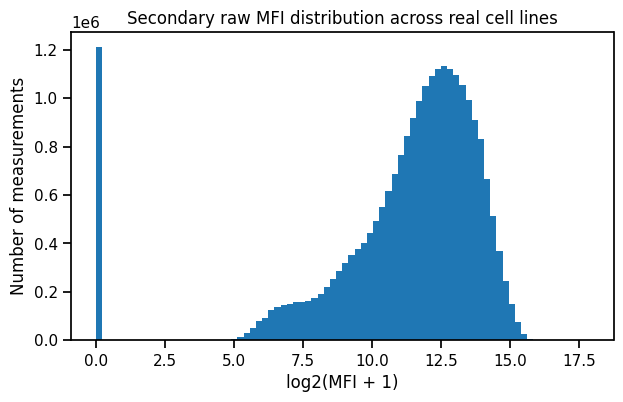

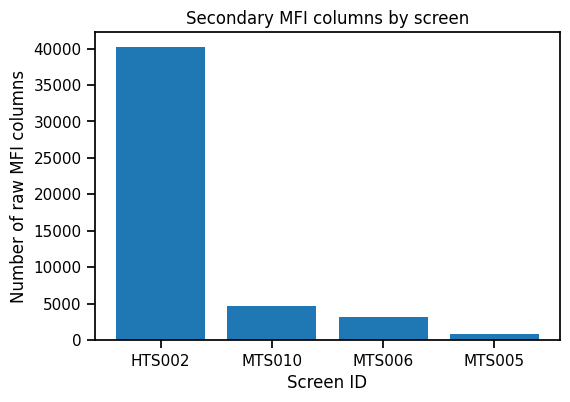

In [170]:
# Plot secondary raw MFI QC summaries

import matplotlib.pyplot as plt
import numpy as np

secondary_log2_mfi_real = np.log2(secondary_mfi_real + 1)

plt.figure(figsize=(7, 4))
plt.hist(secondary_log2_mfi_real.stack(), bins=80)
plt.xlabel("log2(MFI + 1)")
plt.ylabel("Number of measurements")
plt.title("Secondary raw MFI distribution across real cell lines")
plt.show()

screen_counts = secondary_mfi_column_qc["screen_id_from_mfi"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(screen_counts.index, screen_counts.values)
plt.xlabel("Screen ID")
plt.ylabel("Number of raw MFI columns")
plt.title("Secondary MFI columns by screen")
plt.show()

The secondary raw MFI distribution shows a large spike near zero after `log2(MFI + 1)` transformation, consistent with the observed 5.06% non-positive raw MFI values. The remaining measurements form a broad unimodal distribution centered around approximately 12–13 on the log2 scale. This confirms that `log2(MFI + 1)` is the appropriate safe transform for secondary raw MFI QC.

The screen-count plot shows that HTS002 contributes most of the secondary MFI columns, while MTS010, MTS006, and MTS005 contribute smaller subsets. This imbalance reinforces the need to track screen ID and plate structure during any downstream secondary processing.

## 5. Dose-response curve fitting

The secondary screen is designed for dose-response modeling. In the full analysis, each compound-cell-line pair would have normalized viability values across an eight-point dose series, and a dose-response curve would be fit to estimate summary metrics such as AUC and IC50-like potency.

However, the provided raw secondary files do not include a well-level plate map linking each raw secondary MFI column to a specific `broad_id`, dose, and well position. Section 4 showed that secondary MFI columns encode raw plate/well/screen identifiers, while secondary treatment metadata encodes compound/dose/screen/plate annotations. Because the plate/screen counts do not match, order-based mapping would be unsafe.

Therefore, this MVP implements and validates the dose-response fitting framework, but does not claim fitted secondary drug-response results from the raw MFI matrix without the missing well-level mapping.

In [171]:
# Section 5: reusable dose-response fitting framework

from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def four_parameter_logistic_fixed_top(dose, bottom, log10_ic50, hill_slope):
    """
    Four-parameter logistic model with top fixed at 1.0.
    """
    dose = np.asarray(dose, dtype=float)
    top = 1.0
    log10_dose = np.log10(dose)

    return bottom + (top - bottom) / (
        1.0 + 10.0 ** ((log10_dose - log10_ic50) * hill_slope)
    )


def calculate_auc_log_dose(dose, viability):
    """
    Calculate area under the viability curve over log10 dose.

    Lower AUC indicates stronger killing across the tested dose range.
    """
    dose = np.asarray(dose, dtype=float)
    viability = np.asarray(viability, dtype=float)

    valid = np.isfinite(dose) & np.isfinite(viability) & (dose > 0)

    if valid.sum() < 2:
        return np.nan

    log_dose = np.log10(dose[valid])
    y = viability[valid]

    order = np.argsort(log_dose)
    log_dose = log_dose[order]
    y = y[order]

    # Use np.trapezoid instead of np.trapz for compatibility with newer NumPy versions.
    return np.trapezoid(y, log_dose) / (log_dose.max() - log_dose.min())


def fit_dose_response_curve(dose, viability, min_points=5):
    """
    Fit a dose-response curve for one compound-cell-line pair.

    Returns a dictionary with fit parameters, AUC, and fit status.
    """
    dose = np.asarray(dose, dtype=float)
    viability = np.asarray(viability, dtype=float)

    valid = np.isfinite(dose) & np.isfinite(viability) & (dose > 0)

    dose_valid = dose[valid]
    viability_valid = viability[valid]

    result = {
        "n_points": int(valid.sum()),
        "bottom": np.nan,
        "log10_ic50": np.nan,
        "hill_slope": np.nan,
        "auc": calculate_auc_log_dose(dose_valid, viability_valid),
        "fit_success": False,
        "fit_message": "",
    }

    if valid.sum() < min_points:
        result["fit_message"] = "Too few valid dose-response points"
        return result

    try:
        initial_guess = [
            max(0.0, np.nanmin(viability_valid)),
            np.nanmedian(np.log10(dose_valid)),
            1.0,
        ]

        lower_bounds = [0.0, np.log10(np.nanmin(dose_valid)) - 2.0, 0.05]
        upper_bounds = [1.5, np.log10(np.nanmax(dose_valid)) + 2.0, 5.0]

        popt, _ = curve_fit(
            four_parameter_logistic_fixed_top,
            dose_valid,
            viability_valid,
            p0=initial_guess,
            bounds=(lower_bounds, upper_bounds),
            maxfev=10000,
        )

        result["bottom"] = popt[0]
        result["log10_ic50"] = popt[1]
        result["hill_slope"] = popt[2]
        result["fit_success"] = True
        result["fit_message"] = "Fit successful"

    except Exception as error:
        result["fit_message"] = str(error)

    return result

Example dose-response fit:


n_points                    8
bottom               0.115895
log10_ic50          -1.006396
hill_slope           0.988689
auc                  0.580001
fit_success              True
fit_message    Fit successful
dtype: object

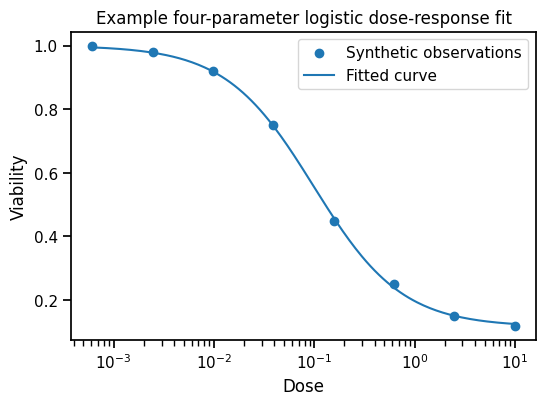

In [172]:
# Validate dose-response fitting framework on synthetic data

example_doses = np.array([
    0.00061034,
    0.0024414,
    0.00976562,
    0.0390625,
    0.15625,
    0.625,
    2.5,
    10.0,
])

example_viability = np.array([
    1.00,
    0.98,
    0.92,
    0.75,
    0.45,
    0.25,
    0.15,
    0.12,
])

example_fit = fit_dose_response_curve(example_doses, example_viability)

print("Example dose-response fit:")
display(pd.Series(example_fit))

dose_grid = np.logspace(
    np.log10(example_doses.min()),
    np.log10(example_doses.max()),
    200,
)

fitted_viability = four_parameter_logistic_fixed_top(
    dose_grid,
    example_fit["bottom"],
    example_fit["log10_ic50"],
    example_fit["hill_slope"],
)

plt.figure(figsize=(6, 4))
plt.scatter(example_doses, example_viability, label="Synthetic observations")
plt.plot(dose_grid, fitted_viability, label="Fitted curve")
plt.xscale("log")
plt.xlabel("Dose")
plt.ylabel("Viability")
plt.title("Example four-parameter logistic dose-response fit")
plt.legend()
plt.show()

### Section 5 interpretation: dose-response fitting framework

The reusable dose-response fitting function successfully fit a four-parameter logistic model with the upper asymptote fixed at 1.0 on a synthetic eight-point dose-response example. The example fit used all 8 dose points, converged successfully, and produced an estimated lower asymptote of approximately 0.116, a log10 IC50 of approximately -1.006, a Hill slope near 0.989, and an AUC of approximately 0.580.

This validates the computational framework that would be used for secondary dose-response modeling once compound-cell-line normalized viability values are available. Lower AUC values would indicate stronger killing across the tested dose range.

However, this notebook does not apply the model to the raw secondary MFI matrix because Section 4 showed that the provided secondary raw files do not include a safe well-level mapping from raw MFI columns to compound-dose annotations. Applying the model without that bridge would risk assigning MFI measurements to the wrong compounds or doses.

### Section 5 multiple-choice question

Why does this notebook validate the dose-response fitting function on a synthetic example instead of fitting all secondary raw MFI measurements directly?

A) The four-parameter logistic model cannot be fit to eight-point dose-response data.

B) The synthetic example proves that the secondary screen has no active compounds.

C) The provided secondary raw files lack a safe well-level mapping from raw MFI columns to compound and dose annotations, so direct fitting could misassign measurements.

D) AUC can only be calculated for primary single-dose screens.

**Correct answer: C**

**Rationale:** The fitting code works on dose/viability vectors, as shown by the successful synthetic example. The limitation is not the model; it is the missing well-level bridge needed to convert raw secondary MFI columns into compound-cell-line dose-response viability profiles.

## 6. Selective Killing vs Broad Cytotoxicity

A compound can appear active in a pooled viability screen for two very different reasons:

1. **Selective killing:** the compound strongly reduces viability in a limited subset of cell lines.
2. **Broad cytotoxicity:** the compound reduces viability across many or nearly all cell lines.

For repurposing, selective activity is often more informative because it may reveal lineage-specific or biomarker-associated vulnerabilities. Broad activity can still be biologically or clinically relevant, but it is less specific and may reflect general toxicity.

This section separates compounds by the breadth of primary-screen sensitivity and prioritizes selective compounds over near-pan-active compounds.

In [173]:
# Section 6: classify compounds by selective killing versus broad cytotoxicity

selectivity_summary = compound_hit_summary.copy()

selectivity_summary["selectivity_class"] = pd.cut(
    selectivity_summary["fraction_sensitive_cell_lines"],
    bins=[-0.001, 0.0, 0.02, 0.20, 0.80, 1.0],
    labels=[
        "no_detected_activity",
        "rare_selective_activity",
        "selective_or_moderate_activity",
        "broad_activity",
        "near_pan_active",
    ],
)

selectivity_summary["is_selective_candidate"] = (
    (selectivity_summary["n_sensitive_cell_lines"] >= 3)
    & (selectivity_summary["fraction_sensitive_cell_lines"] <= 0.20)
)

selectivity_summary["is_broad_cytotoxic"] = (
    selectivity_summary["fraction_sensitive_cell_lines"] > 0.80
)

print("Selectivity class counts:")
display(selectivity_summary["selectivity_class"].value_counts(dropna=False))

print("\nSelective candidate counts:")
display(selectivity_summary["is_selective_candidate"].value_counts(dropna=False))

print("\nBroad cytotoxic / near-pan-active counts:")
display(selectivity_summary["is_broad_cytotoxic"].value_counts(dropna=False))

print("\nSelectivity summary by class:")
display(
    selectivity_summary
    .groupby("selectivity_class", observed=True)
    .agg(
        n_compounds=("broad_id", "nunique"),
        median_sensitive_cell_lines=("n_sensitive_cell_lines", "median"),
        max_sensitive_cell_lines=("n_sensitive_cell_lines", "max"),
        median_fraction_sensitive=("fraction_sensitive_cell_lines", "median"),
        median_min_viability=("min_median_viability", "median"),
    )
    .reset_index()
)

Selectivity class counts:


selectivity_class
no_detected_activity              1977
rare_selective_activity           1604
selective_or_moderate_activity     705
broad_activity                     311
near_pan_active                     89
Name: count, dtype: int64


Selective candidate counts:


is_selective_candidate
False    3296
True     1390
Name: count, dtype: int64


Broad cytotoxic / near-pan-active counts:


is_broad_cytotoxic
False    4597
True       89
Name: count, dtype: int64


Selectivity summary by class:


,selectivity_class,n_compounds,median_sensitive_cell_lines,max_sensitive_cell_lines,median_fraction_sensitive,median_min_viability
0,no_detected_activity,1977,0.0,0,0.000000,0.381274
1,rare_selective_activity,1604,2.0,11,0.003460,0.218115
2,selective_or_moderate_activity,705,31.0,115,0.053633,0.061039
3,broad_activity,311,262.0,461,0.453287,0.011460
4,near_pan_active,89,519.0,555,0.897924,0.006908


In [174]:
# Examples of selective and broad compounds

example_cols = [
    "broad_id",
    "name",
    "n_sensitive_cell_lines",
    "fraction_sensitive_cell_lines",
    "median_viability_all_cell_lines",
    "min_median_viability",
    "selectivity_class",
]

print("Top selective candidates:")
display(
    selectivity_summary
    .loc[selectivity_summary["is_selective_candidate"], example_cols]
    .sort_values(
        ["fraction_sensitive_cell_lines", "min_median_viability"],
        ascending=[True, True],
    )
    .head(20)
)

print("\nNear-pan-active / broad cytotoxic examples:")
display(
    selectivity_summary
    .loc[selectivity_summary["is_broad_cytotoxic"], example_cols]
    .sort_values(
        ["fraction_sensitive_cell_lines", "median_viability_all_cell_lines"],
        ascending=[False, True],
    )
    .head(20)
)

Top selective candidates:


,broad_id,name,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,selectivity_class
3872,BRD-K78303961-001-02-3,glycitein,3,0.00519,1.136113,0.049753,rare_selective_activity
179,BRD-A17407635-001-04-0,alclometasone-dipropionate,3,0.00519,1.157401,0.058155,rare_selective_activity
4522,BRD-K96188950-001-16-9,caffeic-acid-phenethyl-ester,3,0.00519,1.196442,0.058504,rare_selective_activity
4460,BRD-K94358652-001-02-1,daptomycin,3,0.00519,1.014088,0.062636,rare_selective_activity
2787,BRD-K50031829-001-01-6,PF-04447943,3,0.00519,1.018772,0.062740,rare_selective_activity
1289,BRD-K10859802-001-01-0,APD668,3,0.00519,0.788672,0.069193,rare_selective_activity
3427,BRD-K66911501-003-01-2,MK-3207,3,0.00519,1.227059,0.069618,rare_selective_activity
172,BRD-A16439188-001-01-1,quinestrol,3,0.00519,1.000195,0.071970,rare_selective_activity
1085,BRD-K05236810-001-19-0,luteolin,3,0.00519,1.073677,0.078259,rare_selective_activity
4598,BRD-K97963946-001-01-3,EMD-1214063,3,0.00519,1.105857,0.078562,rare_selective_activity



Near-pan-active / broad cytotoxic examples:


,broad_id,name,n_sensitive_cell_lines,fraction_sensitive_cell_lines,median_viability_all_cell_lines,min_median_viability,selectivity_class
641,BRD-A66419424-001-02-4,ixazomib-citrate,555,0.960208,0.059170,0.006633,near_pan_active
2871,BRD-K52233191-001-02-4,R547,553,0.956747,0.071660,0.005281,near_pan_active
2015,BRD-K29415052-050-04-8,BGT226,552,0.955017,0.064345,0.007038,near_pan_active
919,BRD-K00152668-001-01-5,adarotene,551,0.953287,0.076748,0.007341,near_pan_active
3884,BRD-K78659596-001-03-9,ixazomib,548,0.948097,0.054256,0.006649,near_pan_active
3795,BRD-K76674262-001-03-3,homoharringtonine,548,0.948097,0.060374,0.003471,near_pan_active
2859,BRD-K51911221-001-01-2,nemorubicin,547,0.946367,0.055606,0.003454,near_pan_active
3541,BRD-K69650333-003-14-0,idarubicin,547,0.946367,0.060907,0.005220,near_pan_active
2947,BRD-K54247840-004-01-3,halofuginone,547,0.946367,0.063001,0.004697,near_pan_active
3182,BRD-K60348325-065-09-9,brilliant-green,547,0.946367,0.065494,0.007345,near_pan_active


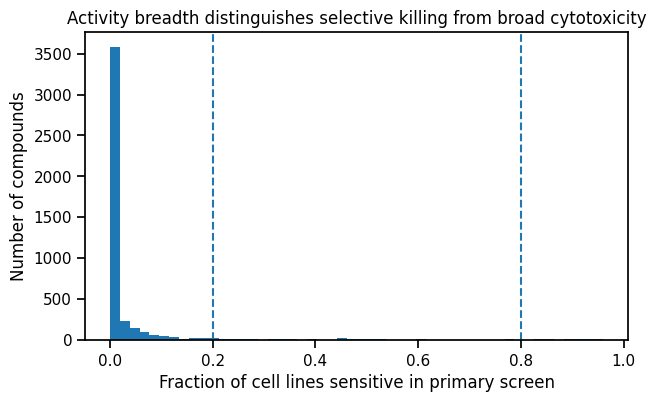

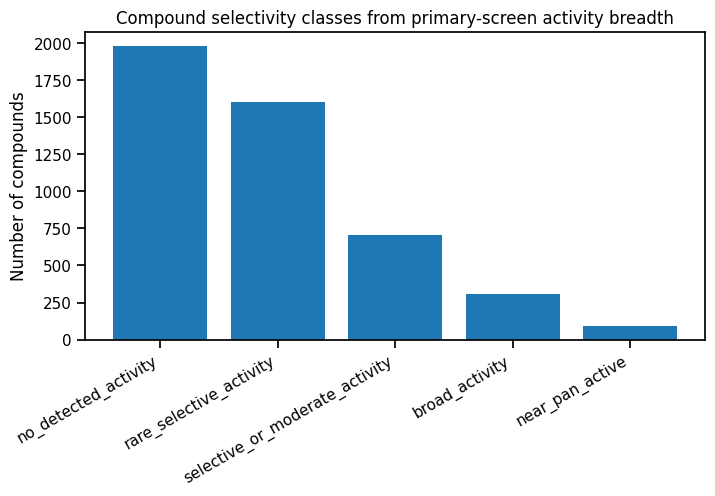

In [175]:
# Plot selective killing versus broad cytotoxicity

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(
    selectivity_summary["fraction_sensitive_cell_lines"].dropna(),
    bins=50
)
plt.axvline(0.20, linestyle="--")
plt.axvline(0.80, linestyle="--")
plt.xlabel("Fraction of cell lines sensitive in primary screen")
plt.ylabel("Number of compounds")
plt.title("Activity breadth distinguishes selective killing from broad cytotoxicity")
plt.show()

class_counts = (
    selectivity_summary["selectivity_class"]
    .value_counts()
    .reindex(
        [
            "no_detected_activity",
            "rare_selective_activity",
            "selective_or_moderate_activity",
            "broad_activity",
            "near_pan_active",
        ]
    )
)

plt.figure(figsize=(8, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of compounds")
plt.title("Compound selectivity classes from primary-screen activity breadth")
plt.show()

### Section 6 interpretation: selective killing versus broad cytotoxicity

The distribution of primary-screen activity breadth is highly right-skewed. Most compounds have no detected activity or activity in only a small fraction of cell lines. This supports separating selective killing from broad cytotoxicity rather than ranking compounds only by strongest viability reduction.

Using activity breadth, 1,390 compounds were classified as selective candidates, while 89 compounds were classified as near-pan-active/broad cytotoxic. The near-pan-active compounds are not inactive; rather, they reduce viability across most tested cell lines and are therefore less informative for discovering lineage- or biomarker-specific vulnerabilities.

The two dashed thresholds summarize this distinction. Compounds active in up to 20% of cell lines are treated as selective or moderately selective, while compounds active in more than 80% of cell lines are flagged as near-pan-active. This prioritization favors compounds whose activity is concentrated in a subset of models, which is more useful for downstream biomarker and mechanism-of-action analysis.

### Section 6 multiple-choice question

Why is it important to distinguish selective killing from broad cytotoxicity in a PRISM drug-repurposing screen?

A) Broadly cytotoxic compounds are always false positives and should be deleted from the dataset.

B) Selective compounds may reveal cell-line-specific, lineage-specific, or biomarker-associated vulnerabilities, while near-pan-active compounds may reflect general toxicity or broadly essential processes.

C) Selective compounds are defined only by having the lowest raw MFI values before normalization.

D) A compound active in every cell line is always the best repurposing candidate.

**Correct answer: B**

**Rationale:** Selective activity is useful because it can point to specific biological vulnerabilities. Broad cytotoxicity can still be real, but it is less specific and may be less useful for biomarker discovery or precision repurposing.